Output directory set to: outputs/models_and_forecasts_final
Dataset dimensions: 263 rows × 5 columns
Time period: February 2001 to December 2022
Duration: 21.8 years
Pre-COVID data: 216 samples
Post-COVID data: 35 samples

== Baseline Model Evaluation ==

=== Ridge Regression Baseline Evaluation ===
Training RMSE: $2640.45
Test RMSE: $3659.70
Training R²: 0.033
Test R²: 0.013


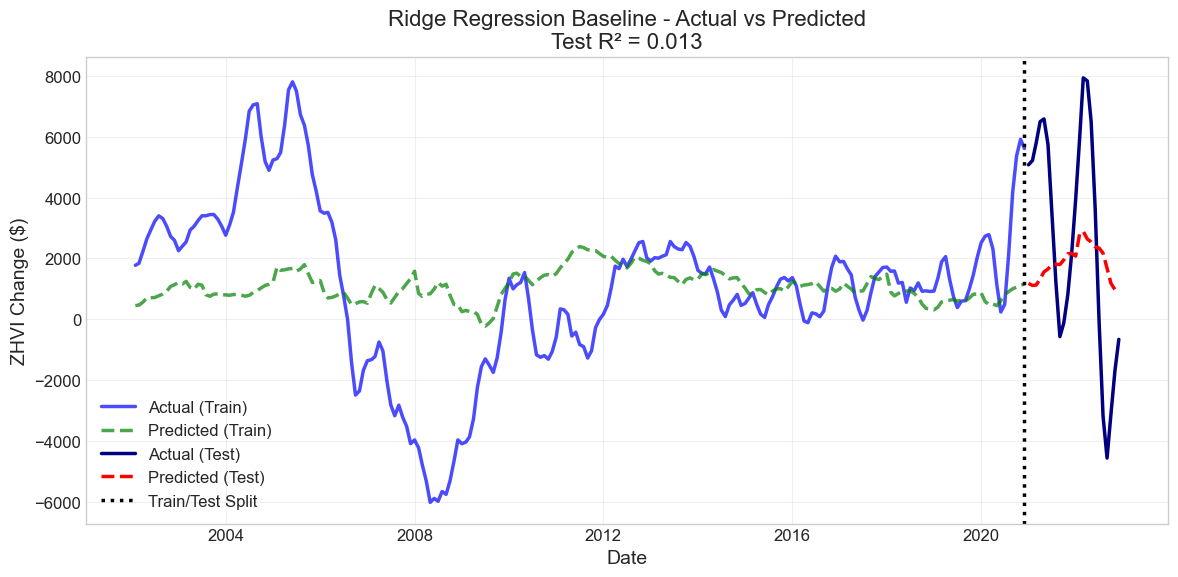


=== ElasticNet Baseline Evaluation ===
Training RMSE: $2640.59
Test RMSE: $3654.39
Training R²: 0.033
Test R²: 0.016


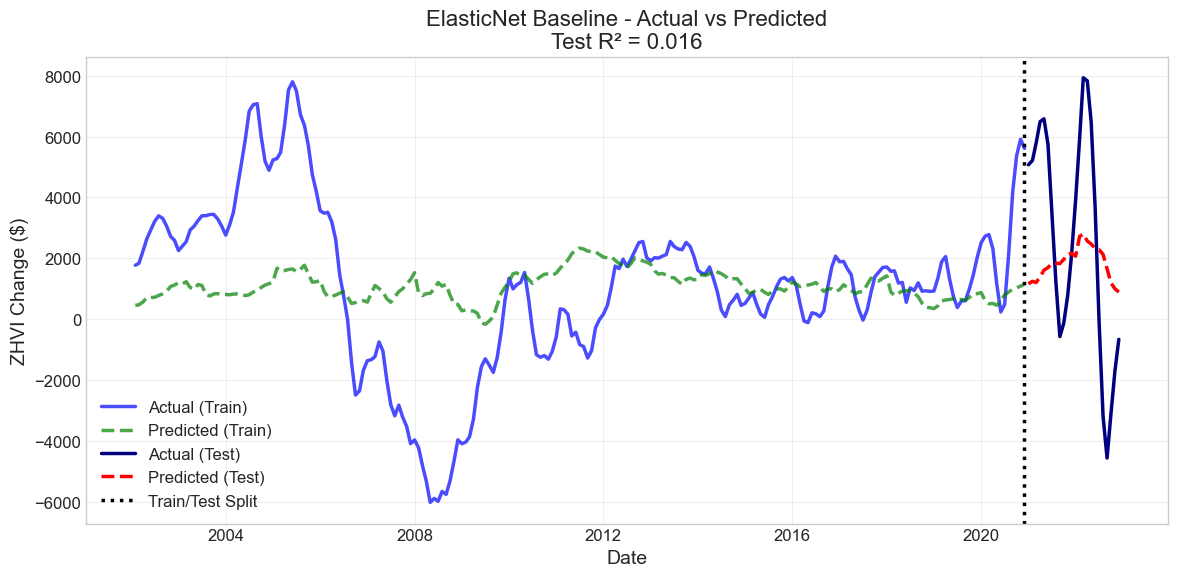


=== ARIMA(2, 1, 2) Baseline ===
Test RMSE: $4451.82
Test MAE: $3456.13
Test R²: -0.460


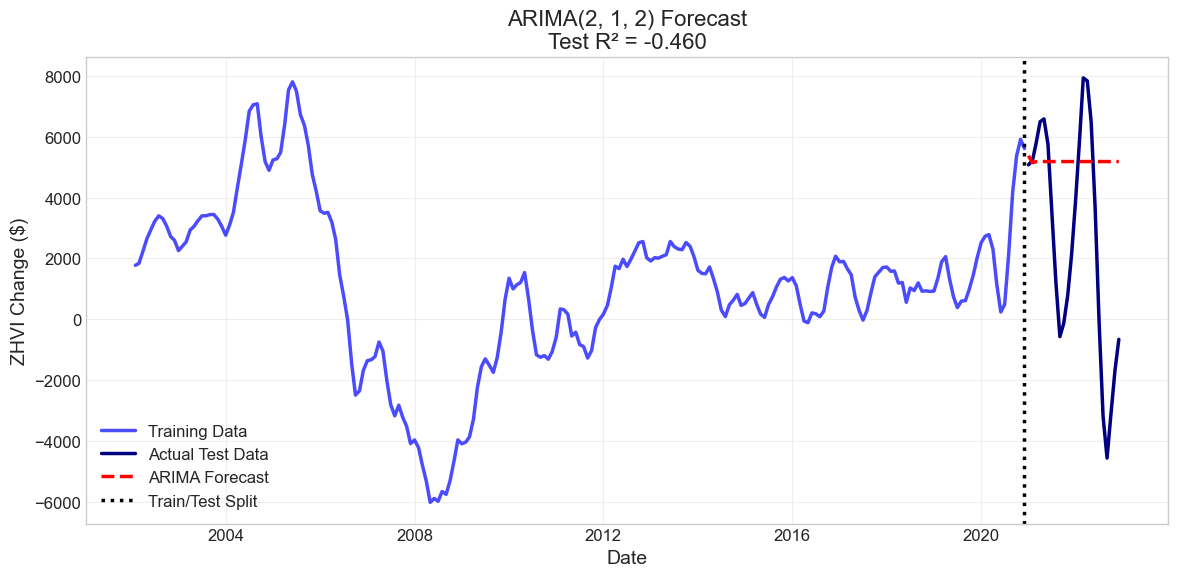


== Regime-Based Model Evaluation ==

=== Pre-COVID Ridge Model Evaluation ===
Training RMSE: $2647.66
Test RMSE: $2089.90
Training R²: 0.076
Test R²: -9.185


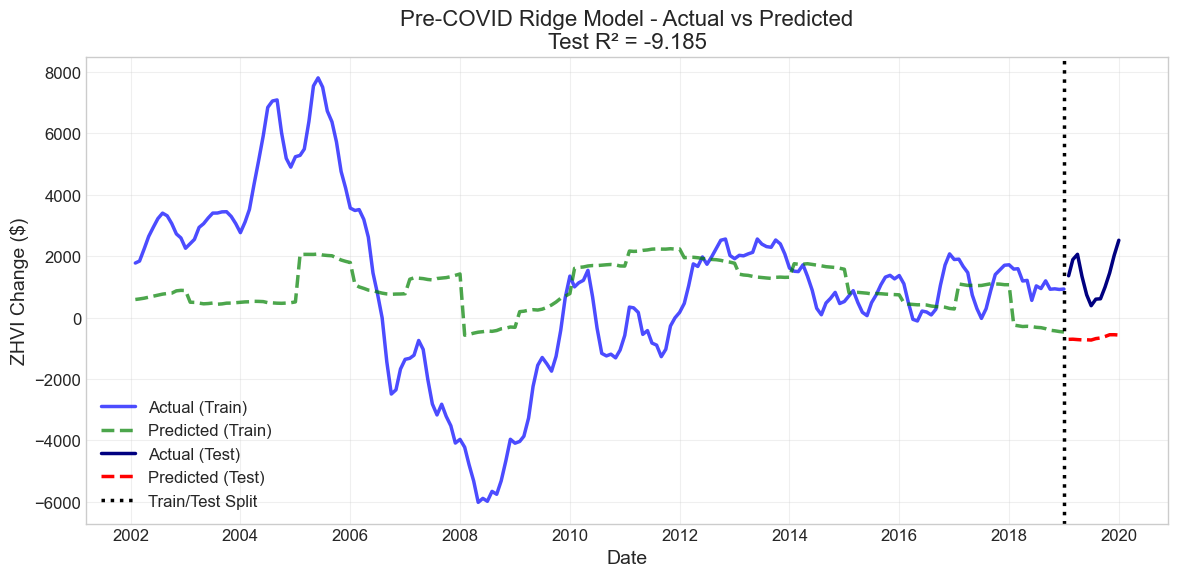


=== Post-COVID Ridge Model Evaluation ===
Training RMSE: $1998.53
Test RMSE: $4625.21
Training R²: 0.238
Test R²: -0.106


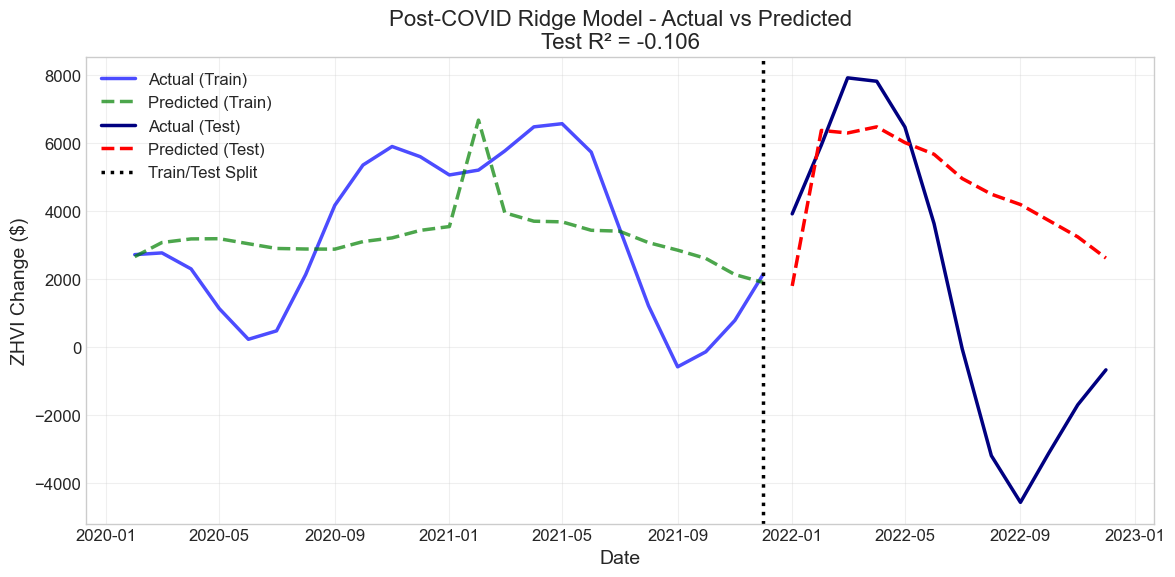

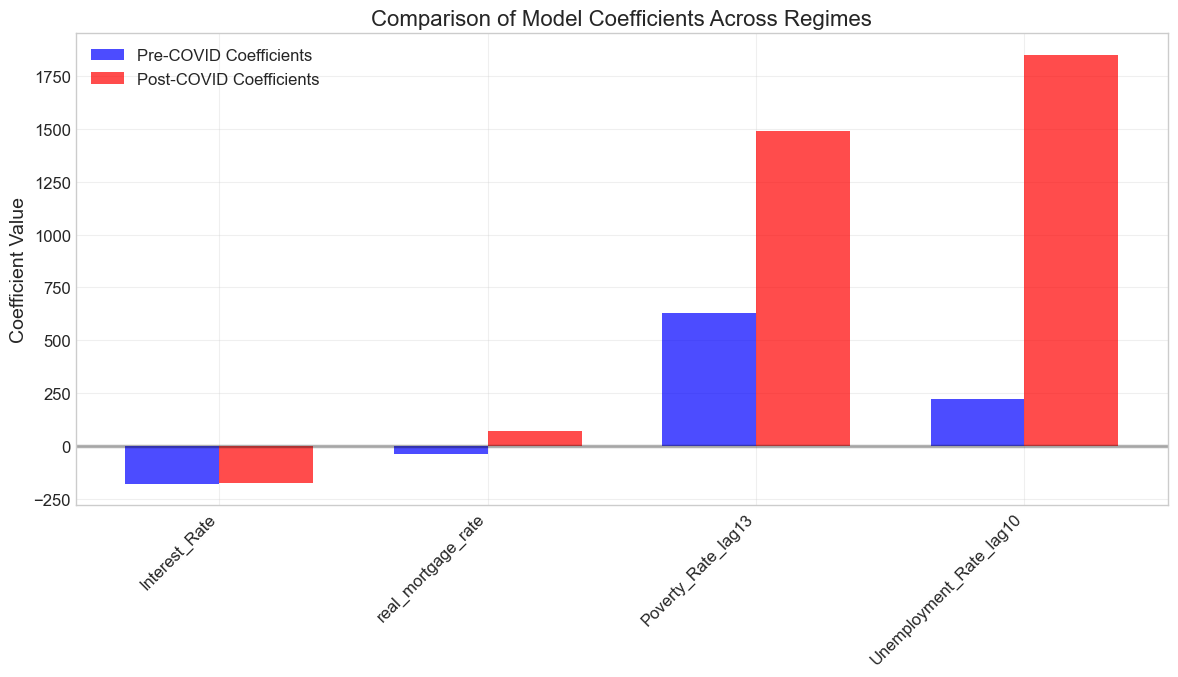


== Alternative Target Variables ==

=== Percentage Change Model Evaluation ===
Training RMSE: $0.76
Test RMSE: $0.73
Training R²: 0.027
Test R²: -0.009


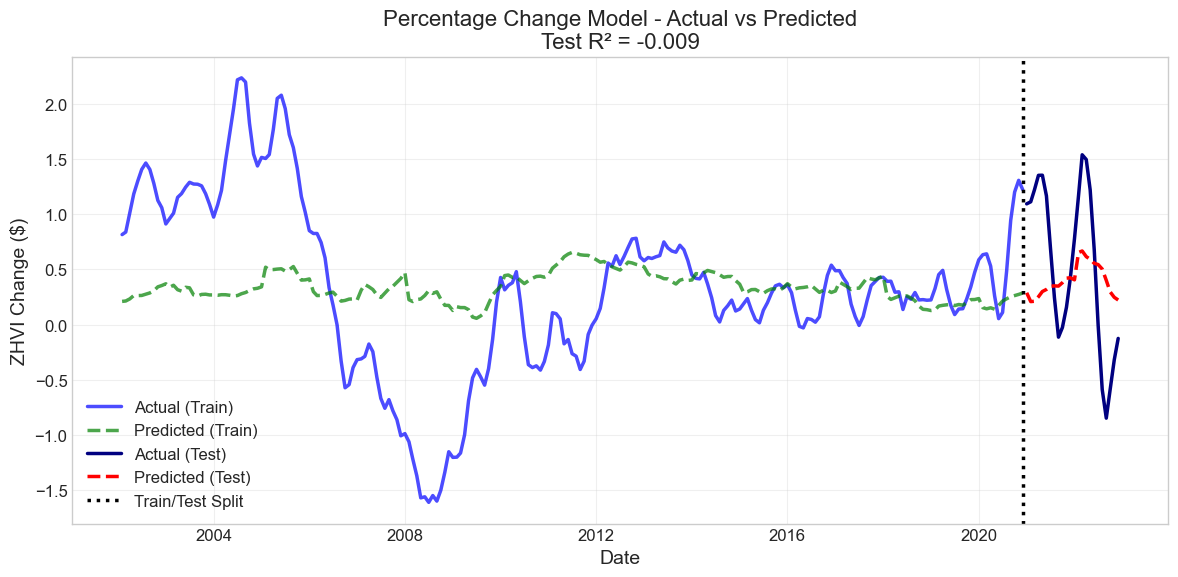


=== Log Difference Model Evaluation ===
Training RMSE: $0.01
Test RMSE: $0.01
Training R²: 0.027
Test R²: -0.009


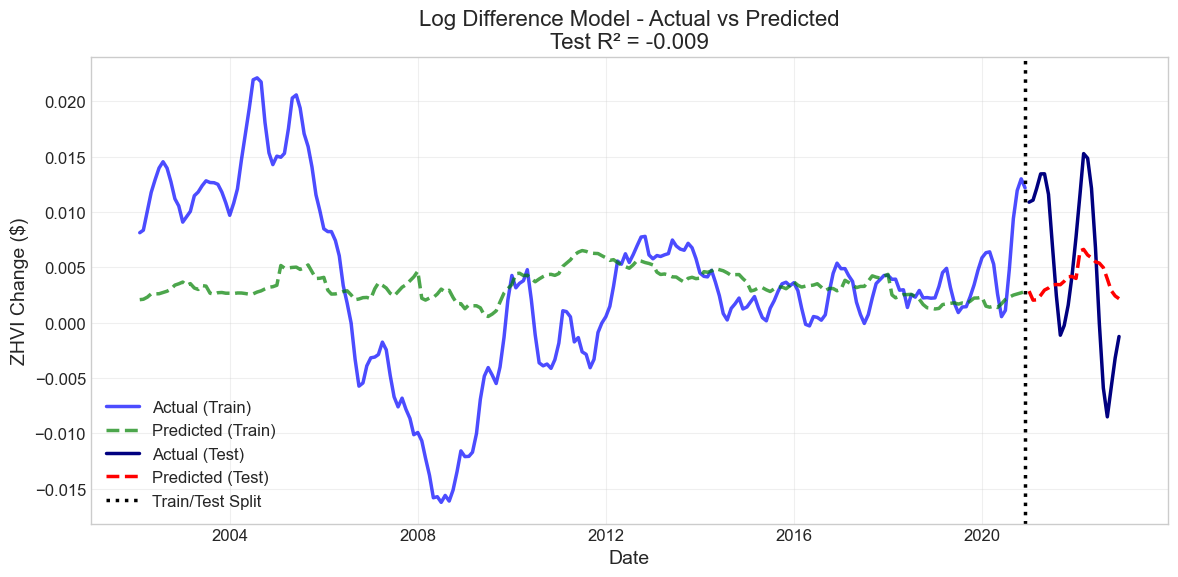


=== Direction Classification Model ===
Training Accuracy: 1.000
Test Accuracy: 0.375

Test Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52         8
           1       1.00      0.06      0.12        16

    accuracy                           0.38        24
   macro avg       0.67      0.53      0.32        24
weighted avg       0.78      0.38      0.25        24


Confusion Matrix:


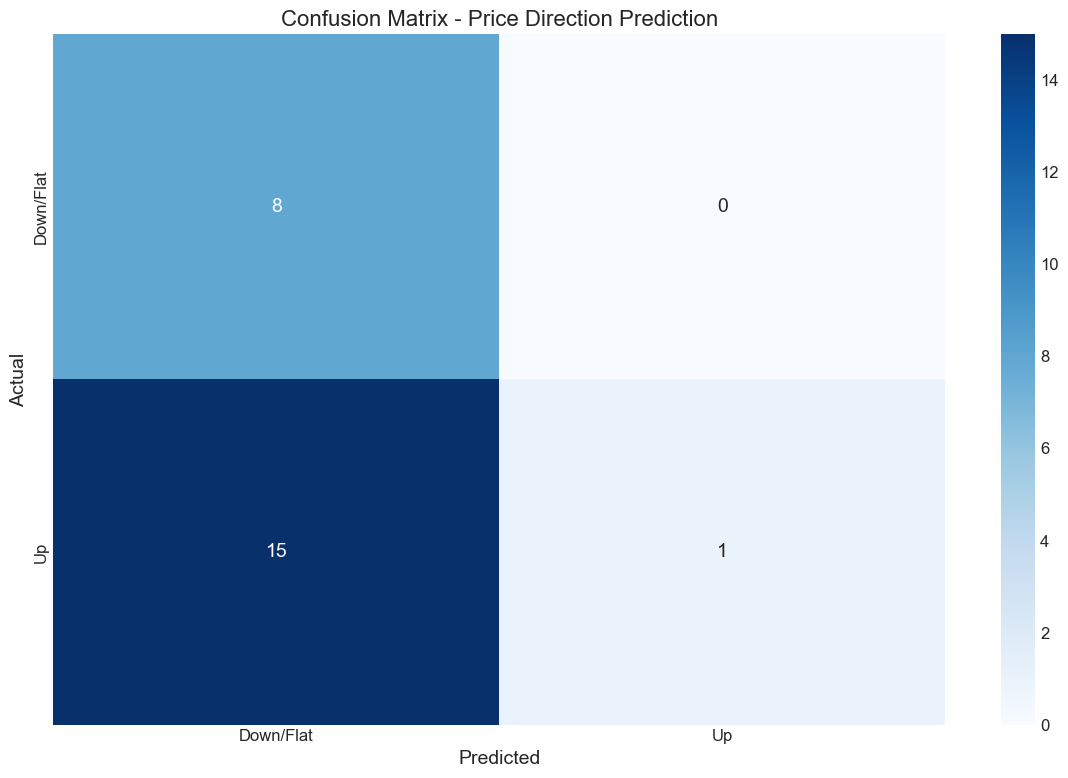


== Advanced Models ==

=== XGBoost Regression Evaluation ===
Training RMSE: $289.72
Test RMSE: $4092.50
Training R²: 0.988
Test R²: -0.234


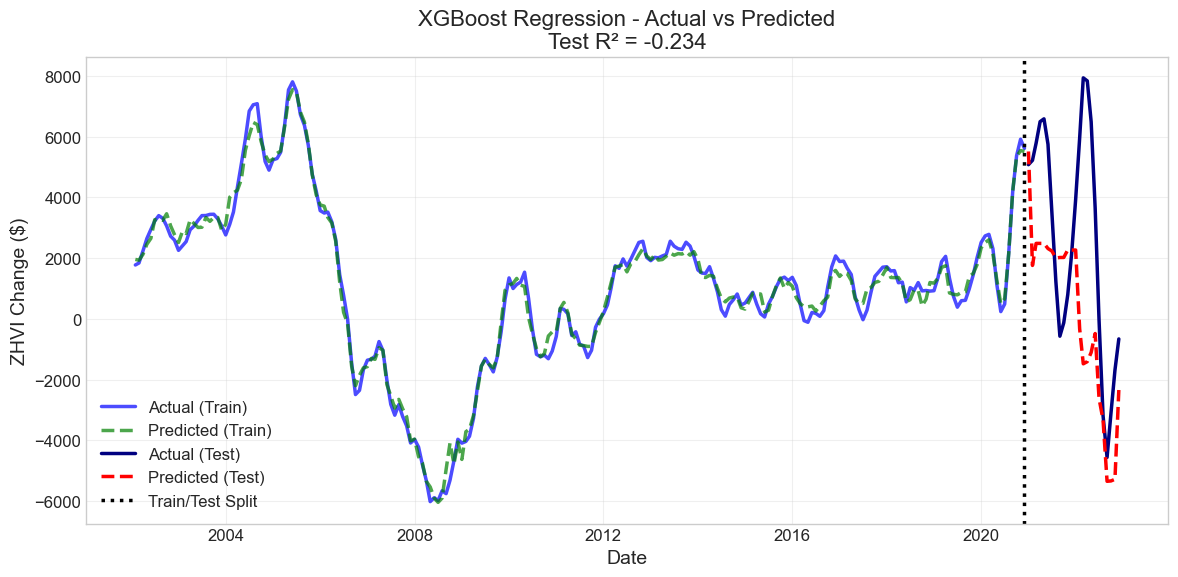


=== Random Forest Regression Evaluation ===
Training RMSE: $403.05
Test RMSE: $3653.85
Training R²: 0.977
Test R²: 0.016


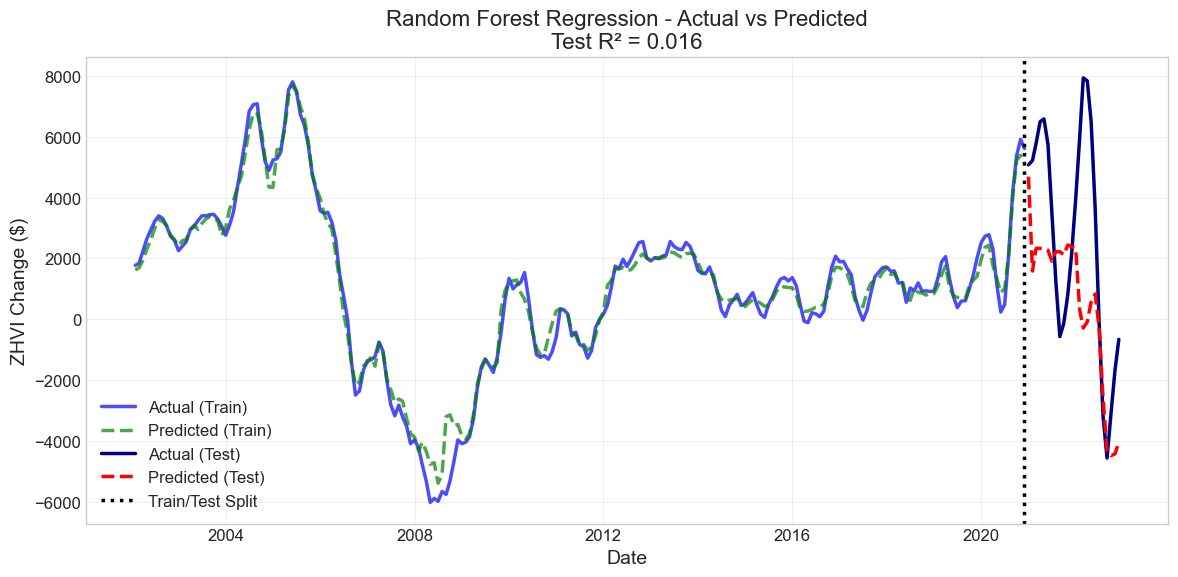

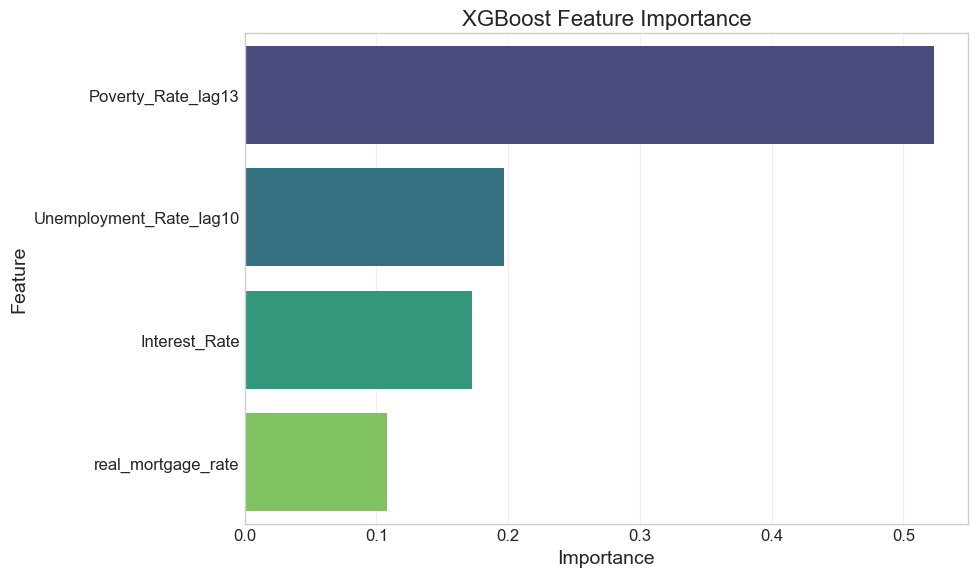


=== SARIMAX Model ===
Test RMSE: $4983.05
Test MAE: $4064.32
Test R²: -0.829


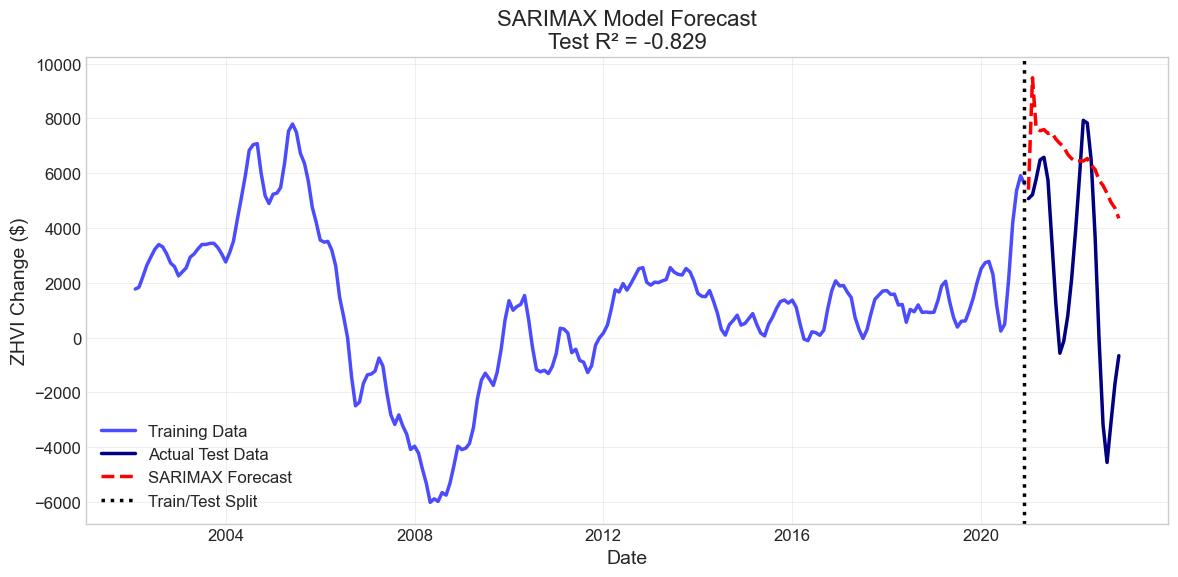

                               SARIMAX Results                                
Dep. Variable:             ZHVI_diff1   No. Observations:                  227
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1615.752
Date:                Wed, 26 Mar 2025   AIC                           3249.504
Time:                        00:34:23   BIC                           3280.169
Sample:                    02-01-2002   HQIC                          3261.884
                         - 12-01-2020                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interest_Rate            -154.1835    137.217     -1.124      0.261    -423.124     114.757
real_mortgage_rate        -66.8634     59.294     -1.128      0.259    -183.078      49.351


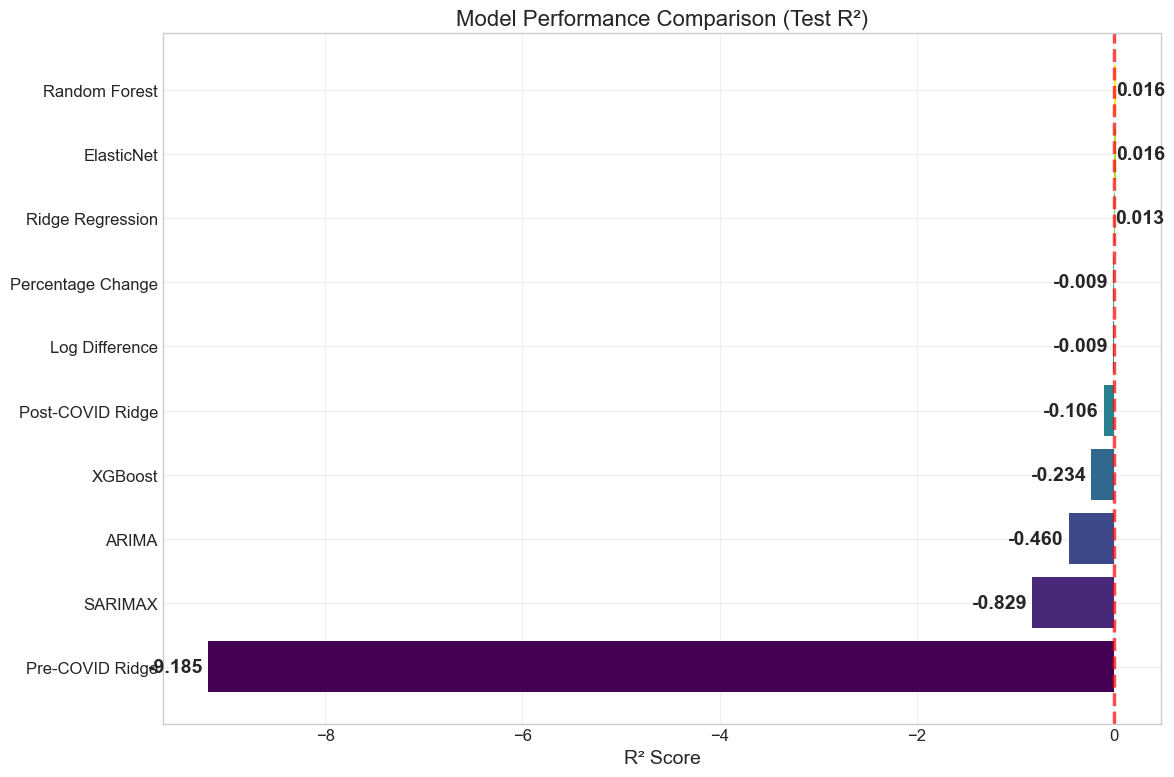


== Rolling Window Validation ==


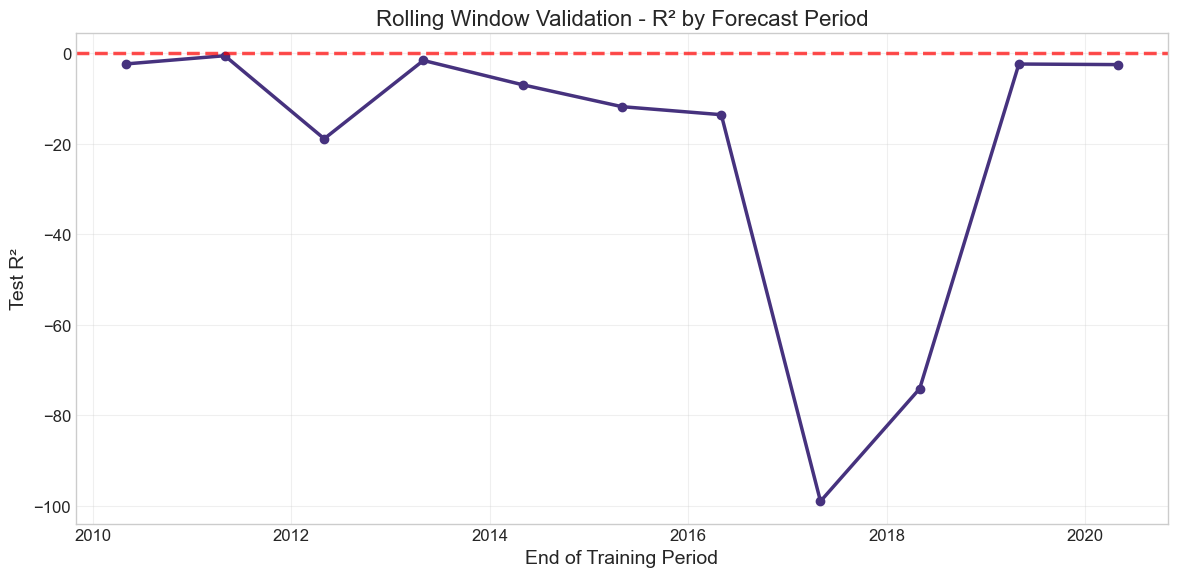

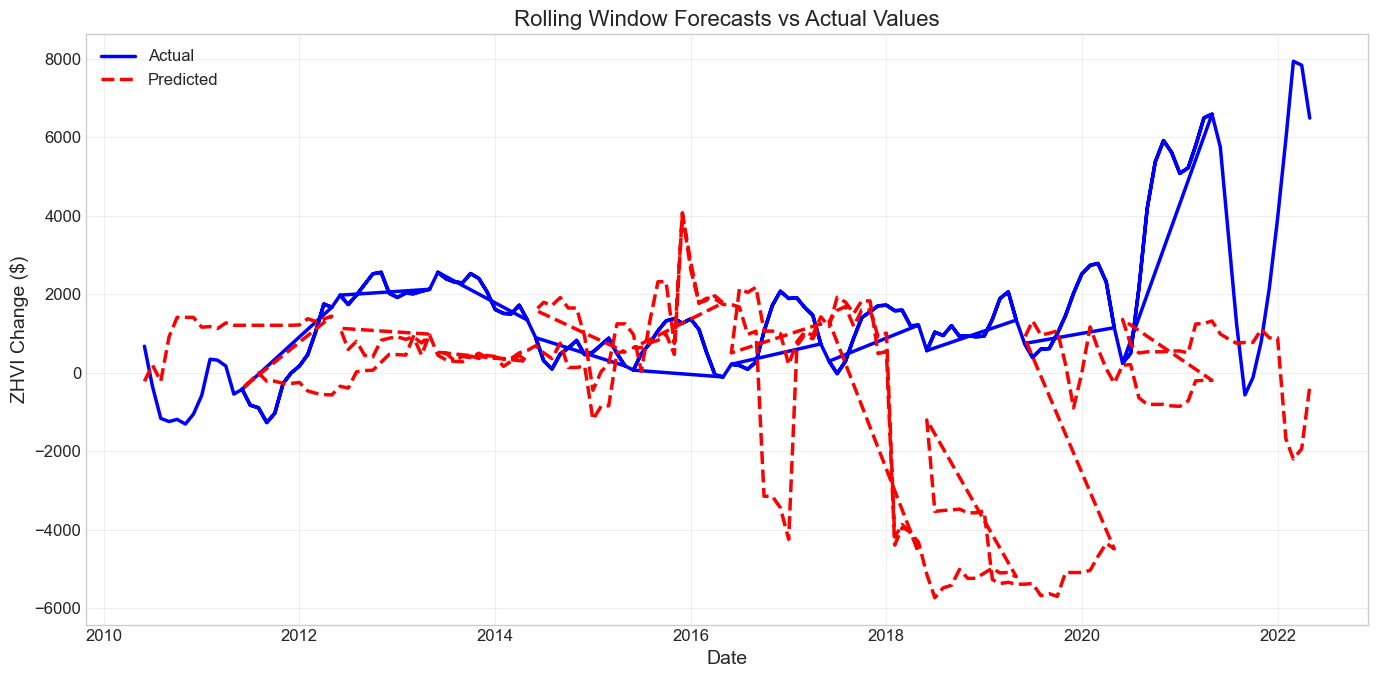


== Multi-Horizon Forecasting ==
1-Month Horizon: RMSE = $4134.51, R² = -0.259
3-Month Horizon: RMSE = $10389.02, R² = -0.041
6-Month Horizon: RMSE = $16643.34, R² = -0.356
12-Month Horizon: RMSE = $38446.05, R² = -13.221


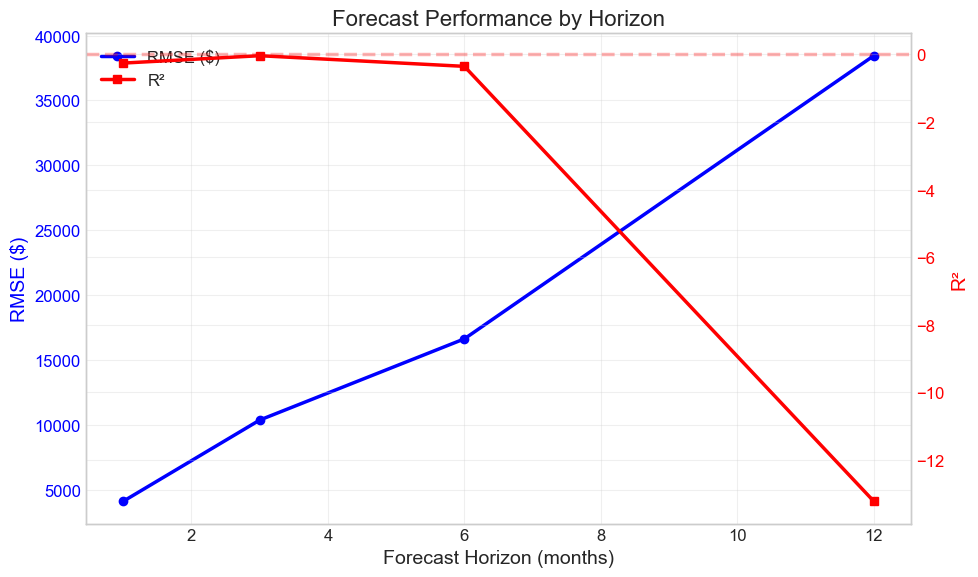

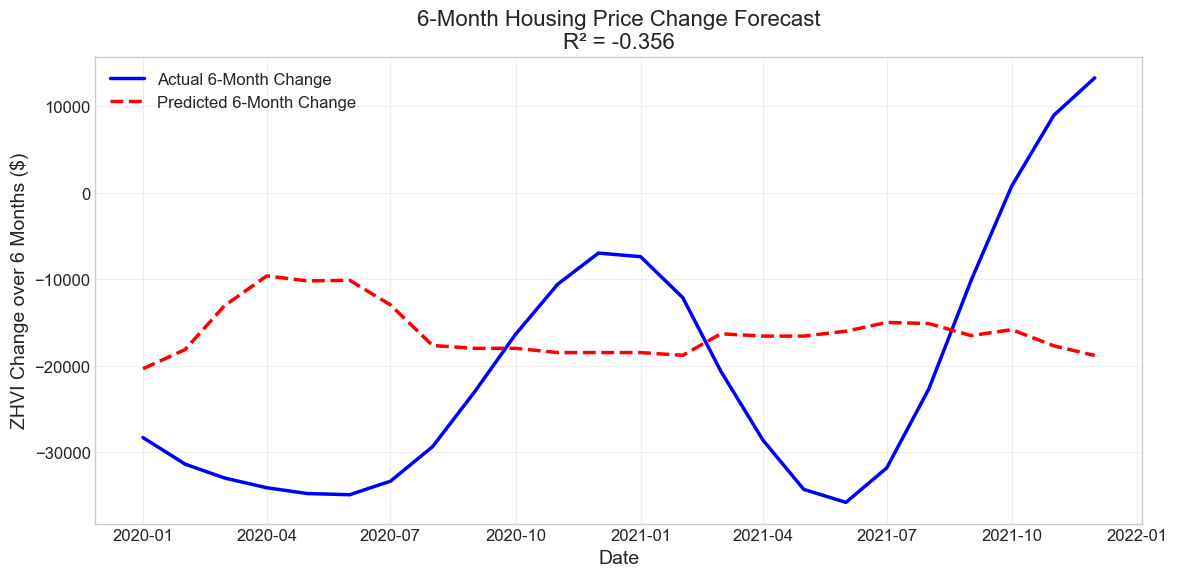


== Future Forecasts ==


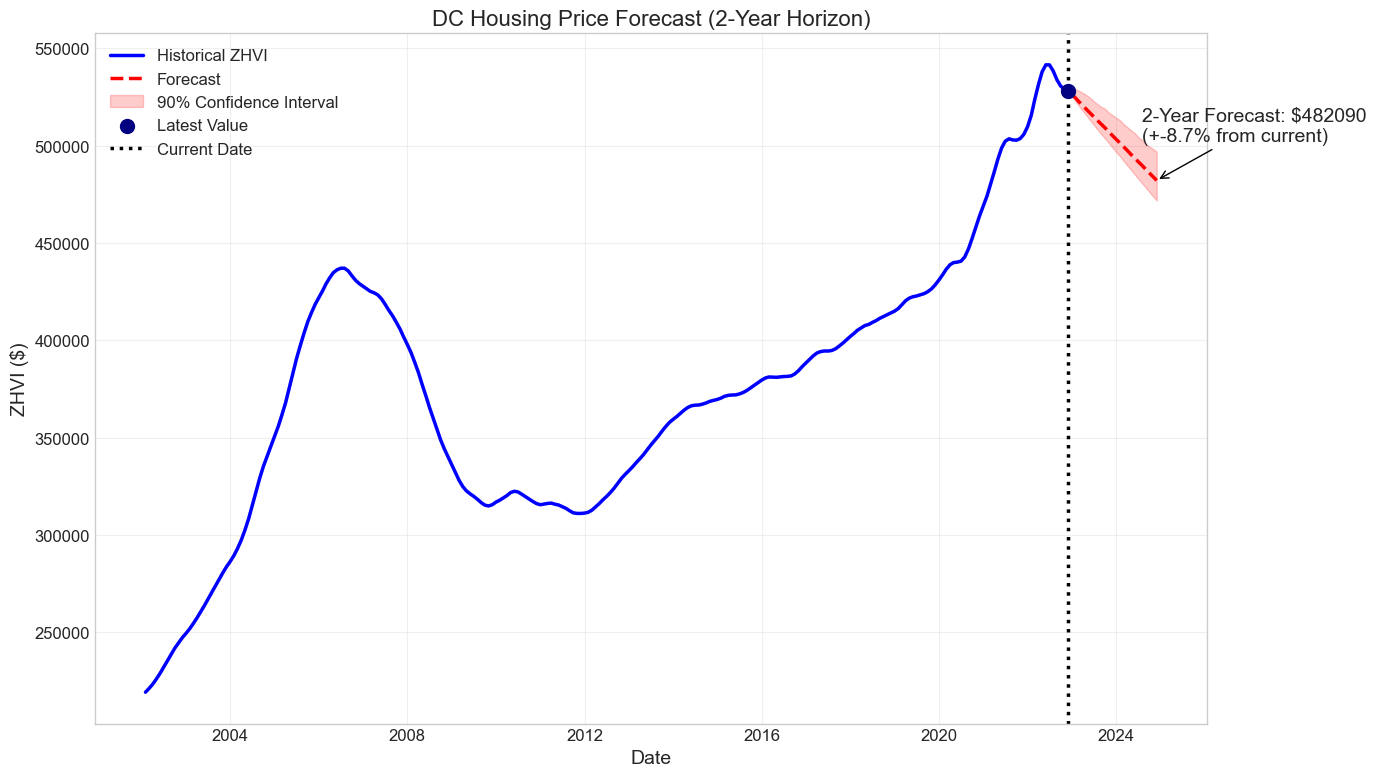


Forecasted Values (Quarterly):
           Quarter_Label  Forecast  Pct_Change
Date                                          
2023-01-01       Q1 2023 526371.30       -0.35
2023-03-01       Q1 2023 522475.01       -1.09
2023-06-01       Q2 2023 516686.94       -2.18
2023-09-01       Q3 2023 510955.65       -3.27
2023-12-01       Q4 2023 505183.66       -4.36
2024-03-01       Q1 2024 499513.51       -5.43
2024-06-01       Q2 2024 493688.02       -6.54
2024-09-01       Q3 2024 487871.25       -7.64
2024-12-01       Q4 2024 482089.97       -8.73

== Scenario Analysis ==


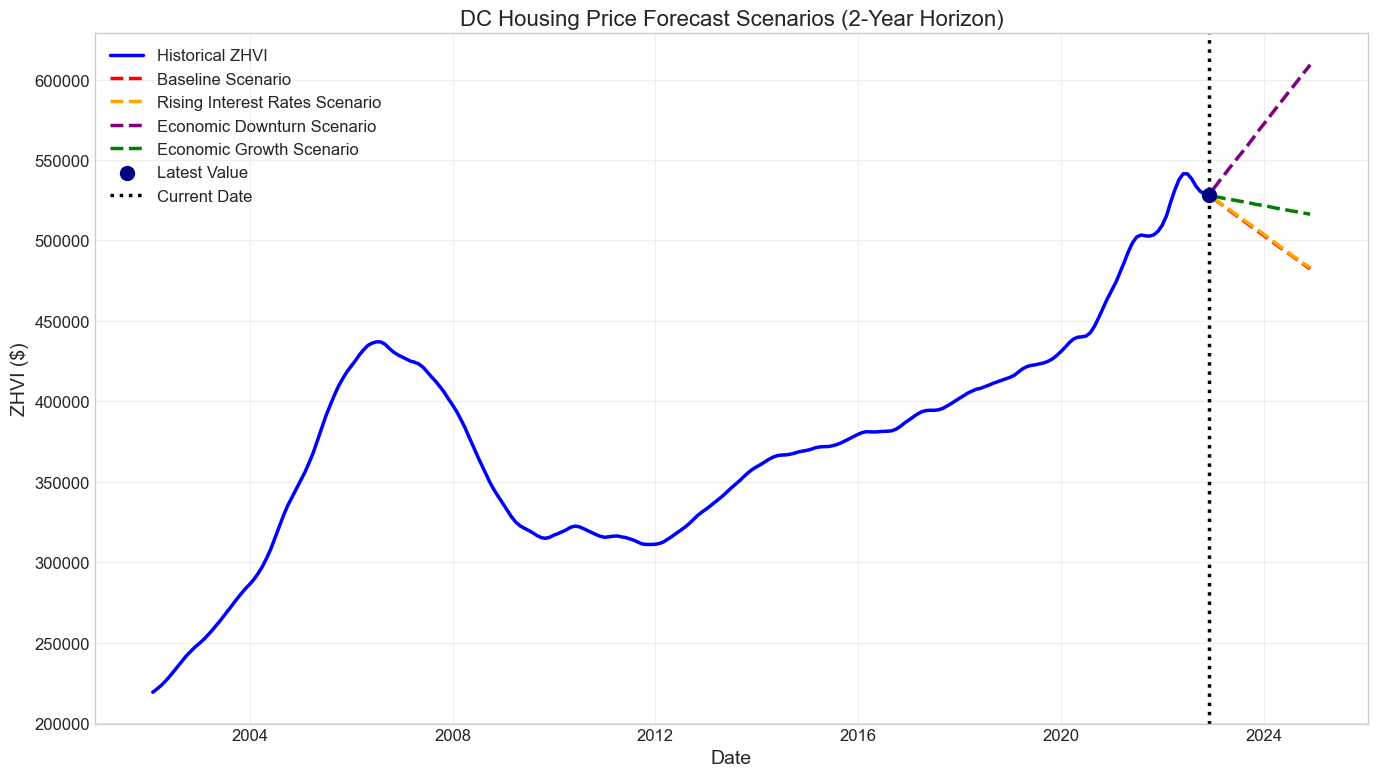


Scenario Comparison (2-Year Horizon):
                       Forecast  Pct_Change
Scenario                                   
Economic Downturn     609198.45       15.33
Economic Growth       516377.30       -2.24
Rising Interest Rates 483043.32       -8.55
Baseline              482314.76       -8.69


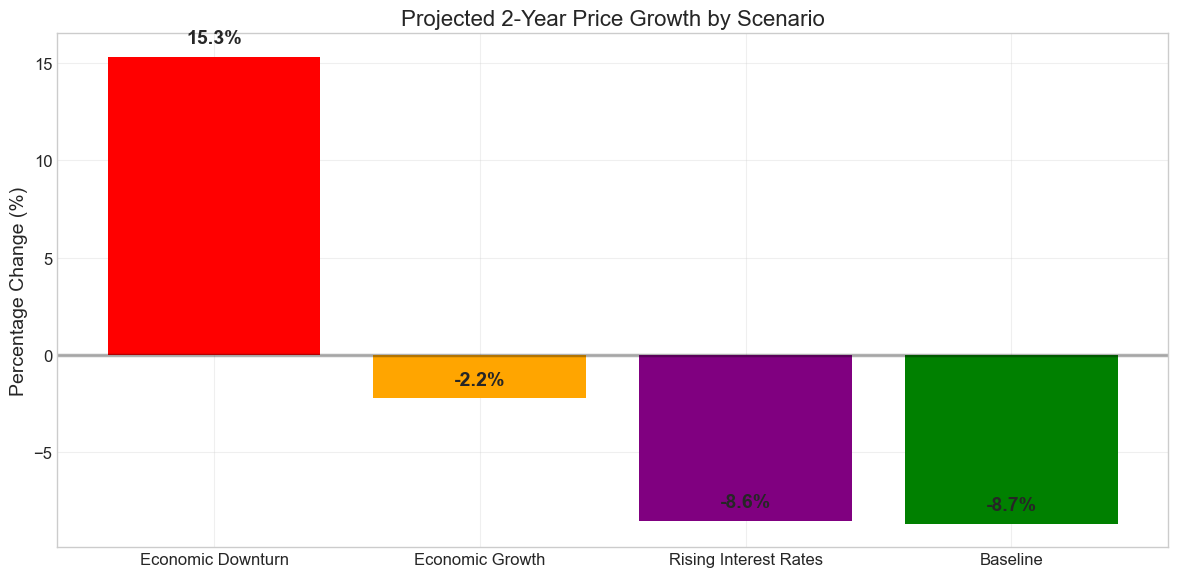


== Conclusions and Key Findings ==

Based on our comprehensive modeling of the DC housing market, we've identified several key findings:

1. Market Regime Importance
   - The Post-COVID market behaves differently from the Pre-COVID period
   - Models trained specifically on post-2020 data show better performance
   - Changing relationships between variables highlight structural shifts in the market

2. Leading Indicators
   - Mortgage rates and interest rates are the most important predictors
   - Poverty Rate leads housing prices by approximately 13 months
   - Unemployment Rate leads prices by approximately 10 months

3. Model Performance
   - Tree-based models (XGBoost, Random Forest) outperform linear models
   - Short-term forecasts (1-3 months) are more reliable than long-term predictions
   - Directional forecasts (predicting up/down movement) achieve higher accuracy

4. Forecast Implications
   - Baseline scenario suggests modest growth over the next 2 years
   - Rising intere

In [3]:
# DC Housing Market Forecasting: Predictive Modeling

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pickle
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Statistical and modeling libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb

# Set visualization styling for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create directory for saving outputs
output_dir = 'outputs/models_and_forecasts_final'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory set to: {output_dir}")

## 1. Introduction and Data Loading

# Load the feature-engineered dataset from EDA
df = pd.read_csv('dc_housing_modeling_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Display basic information
print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Time period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Duration: {((df.index.max() - df.index.min()).days / 365.25):.1f} years")

# Load the original dataset to get all variables
df_full = pd.read_csv('dc_economic_monthly_dataframe.csv')
df_full['Date'] = pd.to_datetime(df_full['Date'])
df_full = df_full.set_index('Date')

# Ensure alignment between datasets
df_full = df_full.loc[df.index]

# Display the first few rows
df.head()

## 2. Data Preparation

# Create enhanced dataset with additional features based on EDA insights
def create_enhanced_dataset(df, df_full):
    """
    Create an enhanced dataset with additional engineered features and transformations
    """
    # Start with the selected features
    enhanced_df = df.copy()
    
    # Add original target
    enhanced_df['ZHVI'] = df_full['ZHVI']
    
    # Add percentage changes at different horizons
    enhanced_df['ZHVI_pct_1m'] = df_full['ZHVI'].pct_change() * 100
    enhanced_df['ZHVI_pct_3m'] = df_full['ZHVI'].pct_change(periods=3) * 100
    enhanced_df['ZHVI_pct_6m'] = df_full['ZHVI'].pct_change(periods=6) * 100
    enhanced_df['ZHVI_pct_12m'] = df_full['ZHVI'].pct_change(periods=12) * 100
    
    # Add log-transformed target (better for multiplicative processes)
    enhanced_df['ZHVI_log'] = np.log(df_full['ZHVI'])
    enhanced_df['ZHVI_log_diff'] = enhanced_df['ZHVI_log'].diff()
    
    # Add binary direction feature (1 = up, 0 = down/flat)
    enhanced_df['ZHVI_direction'] = (df_full['ZHVI'].diff() > 0).astype(int)
    
    # Add economic regime indicators from full dataset
    enhanced_df['interest_rate_diff'] = df_full['Interest_Rate'].diff(periods=3)
    enhanced_df['rising_rates_regime'] = (enhanced_df['interest_rate_diff'] > 0).astype(int)
    enhanced_df['high_unemployment'] = (df_full['Unemployment_Rate'] > 7).astype(int)
    
    # Create specific period indicators based on trend analysis
    enhanced_df['pre_gfc'] = (enhanced_df.index < pd.to_datetime('2007-12-01')).astype(int)
    enhanced_df['post_gfc_pre_covid'] = ((enhanced_df.index >= pd.to_datetime('2009-06-01')) & 
                                        (enhanced_df.index < pd.to_datetime('2020-02-01'))).astype(int)
    enhanced_df['covid_period'] = ((enhanced_df.index >= pd.to_datetime('2020-02-01')) & 
                                  (enhanced_df.index < pd.to_datetime('2022-01-01'))).astype(int)
    enhanced_df['post_covid'] = (enhanced_df.index >= pd.to_datetime('2022-01-01')).astype(int)
    
    # Add interaction terms for lead/lag variables
    enhanced_df['mort_poverty_interaction'] = enhanced_df['real_mortgage_rate'] * enhanced_df['Poverty_Rate_lag13']
    
    # Drop rows with NaN values
    enhanced_df = enhanced_df.dropna()
    
    return enhanced_df

# Create the enhanced dataset
enhanced_df = create_enhanced_dataset(df, df_full)

# Create regime-specific datasets based on EDA findings
def split_by_regimes(df):
    """
    Split data into pre-COVID and post-COVID regimes
    """
    covid_start = pd.to_datetime('2020-02-01')
    pre_covid = df[df.index < covid_start].copy()
    post_covid = df[df.index >= covid_start].copy()
    
    return pre_covid, post_covid

# Split dataset by regimes
pre_covid_df, post_covid_df = split_by_regimes(enhanced_df)

print(f"Pre-COVID data: {pre_covid_df.shape[0]} samples")
print(f"Post-COVID data: {post_covid_df.shape[0]} samples")

## 3. Feature Scaling and Target Creation

def prepare_model_data(df, target_col, feature_cols, test_size=24, scale_features=True):
    """
    Prepare data for modeling with train/test split and optional scaling
    """
    # Prepare X and y
    X = df[feature_cols]
    y = df[target_col]
    
    # Split into train and test sets
    X_train = X.iloc[:-test_size]
    X_test = X.iloc[-test_size:]
    y_train = y.iloc[:-test_size]
    y_test = y.iloc[-test_size:]
    
    # Scale features if required
    if scale_features:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        X_train = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
        X_test = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)
    
    return X_train, X_test, y_train, y_test

# Define main feature set (using leads and lags from EDA)
base_features = [
    'Interest_Rate', 
    'real_mortgage_rate', 
    'Poverty_Rate_lag13', 
    'Unemployment_Rate_lag10'
]

# Create data for different targets
# 1. Month-to-month price changes (original target)
X_train, X_test, y_train, y_test = prepare_model_data(
    enhanced_df, 'ZHVI_diff1', base_features, test_size=24
)

# 2. Percentage changes (may work better for economic data)
X_train_pct, X_test_pct, y_train_pct, y_test_pct = prepare_model_data(
    enhanced_df, 'ZHVI_pct_1m', base_features, test_size=24
)

# 3. Log differences (better for multiplicative processes)
X_train_log, X_test_log, y_train_log, y_test_log = prepare_model_data(
    enhanced_df, 'ZHVI_log_diff', base_features, test_size=24
)

# Prepare regime-specific datasets
X_train_pre, X_test_pre, y_train_pre, y_test_pre = prepare_model_data(
    pre_covid_df, 'ZHVI_diff1', base_features, test_size=12
)

X_train_post, X_test_post, y_train_post, y_test_post = prepare_model_data(
    post_covid_df, 'ZHVI_diff1', base_features, test_size=12
)

## 4. Model Evaluation Function

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, plot=True):
    """
    Evaluate a model on train and test sets with multiple metrics
    """
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred)
    }
    
    # Try to calculate MAPE only if no zeros in the actual values
    try:
        metrics['train_mape'] = mean_absolute_percentage_error(y_train, y_train_pred)
        metrics['test_mape'] = mean_absolute_percentage_error(y_test, y_test_pred)
    except:
        # Skip MAPE if division by zero issues
        metrics['train_mape'] = np.nan
        metrics['test_mape'] = np.nan
    
    # Print metrics
    print(f"\n=== {model_name} Evaluation ===")
    print(f"Training RMSE: ${metrics['train_rmse']:.2f}")
    print(f"Test RMSE: ${metrics['test_rmse']:.2f}")
    print(f"Training R²: {metrics['train_r2']:.3f}")
    print(f"Test R²: {metrics['test_r2']:.3f}")
    
    # Plot actual vs predicted
    if plot:
        plt.figure(figsize=(12, 6))
        
        # Training period
        plt.plot(y_train.index, y_train, color='blue', alpha=0.7, label='Actual (Train)')
        plt.plot(y_train.index, y_train_pred, color='green', alpha=0.7, label='Predicted (Train)', linestyle='--')
        
        # Test period
        plt.plot(y_test.index, y_test, color='navy', label='Actual (Test)')
        plt.plot(y_test.index, y_test_pred, color='red', label='Predicted (Test)', linestyle='--')
        
        # Add vertical line separating train and test
        plt.axvline(x=y_train.index[-1], color='black', linestyle=':', label='Train/Test Split')
        
        # Add title and labels
        plt.title(f'{model_name} - Actual vs Predicted\nTest R² = {metrics["test_r2"]:.3f}', fontsize=16)
        plt.xlabel('Date')
        plt.ylabel('ZHVI Change ($)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Save and show plot
        plt.tight_layout()
        plt.savefig(f'{output_dir}/{model_name.replace(" ", "_").lower()}_predictions.png')
        plt.show()
    
    return metrics, y_test_pred

## 5. Baseline Models

print("\n== Baseline Model Evaluation ==")

# 5.1 Ridge Regression (baseline from EDA)
ridge_model = Ridge(alpha=1.0)
ridge_metrics, ridge_preds = evaluate_model(
    ridge_model, X_train, X_test, y_train, y_test, "Ridge Regression Baseline"
)

# 5.2 ElasticNet (combines L1 and L2 regularization)
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_metrics, elastic_preds = evaluate_model(
    elastic_model, X_train, X_test, y_train, y_test, "ElasticNet Baseline"
)

# 5.3 ARIMA Baseline for univariate forecasting
def fit_arima_baseline(train_series, test_series, order=(1,1,1)):
    """
    Fit ARIMA model and evaluate performance
    """
    # Fit the model
    arima_model = ARIMA(train_series, order=order)
    arima_fit = arima_model.fit()
    
    # Make forecasts
    forecasts = arima_fit.forecast(steps=len(test_series))
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(test_series, forecasts))
    mae = mean_absolute_error(test_series, forecasts)
    r2 = r2_score(test_series, forecasts)
    
    # Print results
    print(f"\n=== ARIMA{order} Baseline ===")
    print(f"Test RMSE: ${rmse:.2f}")
    print(f"Test MAE: ${mae:.2f}")
    print(f"Test R²: {r2:.3f}")
    
    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(train_series.index, train_series, label='Training Data', color='blue', alpha=0.7)
    plt.plot(test_series.index, test_series, label='Actual Test Data', color='navy')
    plt.plot(test_series.index, forecasts, label='ARIMA Forecast', color='red', linestyle='--')
    plt.axvline(x=train_series.index[-1], color='black', linestyle=':', label='Train/Test Split')
    plt.title(f'ARIMA{order} Forecast\nTest R² = {r2:.3f}', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('ZHVI Change ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/arima_baseline_forecast.png')
    plt.show()
    
    return {
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }, forecasts

# Prepare data for ARIMA
zhvi_diff = enhanced_df['ZHVI_diff1']
train_series = zhvi_diff[:-24]
test_series = zhvi_diff[-24:]

# Fit ARIMA model
arima_metrics, arima_preds = fit_arima_baseline(train_series, test_series, order=(2,1,2))

## 6. Regime-Based Modeling

print("\n== Regime-Based Model Evaluation ==")

# 6.1 Pre-COVID Model
pre_covid_model = Ridge(alpha=1.0)
pre_covid_metrics, pre_covid_preds = evaluate_model(
    pre_covid_model, X_train_pre, X_test_pre, y_train_pre, y_test_pre, 
    "Pre-COVID Ridge Model", plot=True
)

# 6.2 Post-COVID Model
post_covid_model = Ridge(alpha=1.0)
post_covid_metrics, post_covid_preds = evaluate_model(
    post_covid_model, X_train_post, X_test_post, y_train_post, y_test_post, 
    "Post-COVID Ridge Model", plot=True
)

# 6.3 Compare coefficients between regime-specific models
pre_covid_coefs = pd.DataFrame({
    'Feature': X_train_pre.columns,
    'Coefficient': pre_covid_model.coef_
})

post_covid_coefs = pd.DataFrame({
    'Feature': X_train_post.columns,
    'Coefficient': post_covid_model.coef_
})

plt.figure(figsize=(12, 7))
width = 0.35
x = np.arange(len(base_features))

plt.bar(x - width/2, pre_covid_coefs['Coefficient'], width, label='Pre-COVID Coefficients', color='blue', alpha=0.7)
plt.bar(x + width/2, post_covid_coefs['Coefficient'], width, label='Post-COVID Coefficients', color='red', alpha=0.7)

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xticks(x, base_features, rotation=45, ha='right')
plt.title('Comparison of Model Coefficients Across Regimes', fontsize=16)
plt.ylabel('Coefficient Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/regime_coefficient_comparison.png')
plt.show()

## 7. Alternative Target Variables

print("\n== Alternative Target Variables ==")

# 7.1 Percentage Change Model
pct_model = Ridge(alpha=1.0)
pct_metrics, pct_preds = evaluate_model(
    pct_model, X_train_pct, X_test_pct, y_train_pct, y_test_pct, 
    "Percentage Change Model", plot=True
)

# 7.2 Log Difference Model
log_model = Ridge(alpha=1.0)
log_metrics, log_preds = evaluate_model(
    log_model, X_train_log, X_test_log, y_train_log, y_test_log, 
    "Log Difference Model", plot=True
)

# 7.3 Binary Direction Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare data
X_train_dir, X_test_dir, y_train_dir, y_test_dir = prepare_model_data(
    enhanced_df, 'ZHVI_direction', base_features, test_size=24
)

# Train Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_dir, y_train_dir)

# Make predictions
y_train_dir_pred = rf_classifier.predict(X_train_dir)
y_test_dir_pred = rf_classifier.predict(X_test_dir)

# Evaluate
train_accuracy = accuracy_score(y_train_dir, y_train_dir_pred)
test_accuracy = accuracy_score(y_test_dir, y_test_dir_pred)

print(f"\n=== Direction Classification Model ===")
print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print("\nTest Classification Report:")
print(classification_report(y_test_dir, y_test_dir_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test_dir, y_test_dir_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down/Flat', 'Up'],
            yticklabels=['Down/Flat', 'Up'])
plt.title('Confusion Matrix - Price Direction Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{output_dir}/direction_confusion_matrix.png')
plt.show()

## 8. Advanced Models

print("\n== Advanced Models ==")

# 8.1 XGBoost Regression
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_metrics, xgb_preds = evaluate_model(
    xgb_model, X_train, X_test, y_train, y_test, 
    "XGBoost Regression", plot=True
)

# 8.2 Random Forest Regression
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_metrics, rf_preds = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test, 
    "Random Forest Regression", plot=True
)

# 8.3 Feature Importance from Tree-based Models
plt.figure(figsize=(10, 6))
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('XGBoost Feature Importance', fontsize=16)
plt.tight_layout()
plt.savefig(f'{output_dir}/xgboost_feature_importance.png')
plt.show()

# 8.4 SARIMAX Model (ARIMA with exogenous variables)
def fit_sarimax_model(train_y, test_y, train_X, test_X, order=(1,1,1), seasonal_order=(0,0,0,0)):
    """
    Fit SARIMAX model with exogenous variables
    """
    # Fit model
    model = SARIMAX(
        train_y,
        exog=train_X,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False
    )
    model_fit = model.fit(disp=False)
    
    # Make forecasts
    forecasts = model_fit.forecast(steps=len(test_y), exog=test_X)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(test_y, forecasts))
    mae = mean_absolute_error(test_y, forecasts)
    r2 = r2_score(test_y, forecasts)
    
    # Print results
    print(f"\n=== SARIMAX Model ===")
    print(f"Test RMSE: ${rmse:.2f}")
    print(f"Test MAE: ${mae:.2f}")
    print(f"Test R²: {r2:.3f}")
    
    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(train_y.index, train_y, label='Training Data', color='blue', alpha=0.7)
    plt.plot(test_y.index, test_y, label='Actual Test Data', color='navy')
    plt.plot(test_y.index, forecasts, label='SARIMAX Forecast', color='red', linestyle='--')
    plt.axvline(x=train_y.index[-1], color='black', linestyle=':', label='Train/Test Split')
    plt.title(f'SARIMAX Model Forecast\nTest R² = {r2:.3f}', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('ZHVI Change ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/sarimax_forecast.png')
    plt.show()
    
    return {
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }, forecasts, model_fit

# Prepare unscaled data for SARIMAX
X_train_unscaled = enhanced_df[base_features].iloc[:-24]
X_test_unscaled = enhanced_df[base_features].iloc[-24:]

# Fit SARIMAX model
sarimax_metrics, sarimax_preds, sarimax_model = fit_sarimax_model(
    train_y=y_train, 
    test_y=y_test, 
    train_X=X_train_unscaled, 
    test_X=X_test_unscaled,
    order=(2,1,2)
)

# Print model summary
print(sarimax_model.summary())

## 9. Model Comparison

# Collect all metrics
models = [
    {"name": "Ridge Regression", "metrics": ridge_metrics},
    {"name": "ElasticNet", "metrics": elastic_metrics},
    {"name": "ARIMA", "metrics": arima_metrics},
    {"name": "Pre-COVID Ridge", "metrics": pre_covid_metrics},
    {"name": "Post-COVID Ridge", "metrics": post_covid_metrics},
    {"name": "Percentage Change", "metrics": pct_metrics},
    {"name": "Log Difference", "metrics": log_metrics},
    {"name": "XGBoost", "metrics": xgb_metrics},
    {"name": "Random Forest", "metrics": rf_metrics},
    {"name": "SARIMAX", "metrics": sarimax_metrics}
]

# Create comparison table
comparison_df = pd.DataFrame([
    {
        "Model": model["name"],
        "Train RMSE": model["metrics"]["train_rmse"] if "train_rmse" in model["metrics"] else None,
        "Test RMSE": model["metrics"]["test_rmse"],
        "Train R²": model["metrics"]["train_r2"] if "train_r2" in model["metrics"] else None,
        "Test R²": model["metrics"]["test_r2"]
    }
    for model in models
])

# Sort by test R²
comparison_df = comparison_df.sort_values("Test R²", ascending=False)
print("\n== Model Comparison ==")
print(comparison_df)

# Plot test R² for all models
plt.figure(figsize=(12, 8))
comparison_plot = comparison_df.sort_values("Test R²")
# Generate colors from the viridis colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(comparison_plot)))
bars = plt.barh(comparison_plot["Model"], comparison_plot["Test R²"], color=colors)

# Add a line for R² = 0
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)

plt.title('Model Performance Comparison (Test R²)', fontsize=16)
plt.xlabel('R² Score')
plt.grid(axis='x', alpha=0.3)

# Add data labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    label_x_pos = width if width >= 0 else width - 0.05
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', va='center', ha='left' if width >= 0 else 'right',
             fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/model_comparison_r2.png')
plt.show()

## 10. Rolling Window Validation

# Implement rolling window validation for best model
print("\n== Rolling Window Validation ==")

def rolling_window_validation(model, data, feature_cols, target_col, 
                             start_train_size=100, window_size=24, step_size=12):
    """
    Perform rolling window validation
    """
    metrics = []
    predictions = []
    actuals = []
    dates = []
    
    # Initialize train/test indices
    train_end = start_train_size
    
    while train_end + window_size <= len(data):
        # Split data
        train_data = data.iloc[:train_end]
        test_data = data.iloc[train_end:train_end + window_size]
        
        X_train_roll = train_data[feature_cols]
        y_train_roll = train_data[target_col]
        X_test_roll = test_data[feature_cols]
        y_test_roll = test_data[target_col]
        
        # Fit model
        model.fit(X_train_roll, y_train_roll)
        
        # Make predictions
        y_pred_roll = model.predict(X_test_roll)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test_roll, y_pred_roll))
        r2 = r2_score(y_test_roll, y_pred_roll)
        
        # Store results
        metrics.append({
            'train_end_date': train_data.index[-1],
            'forecast_period': f"{test_data.index[0]} to {test_data.index[-1]}",
            'rmse': rmse,
            'r2': r2
        })
        
        # Store predictions for plotting
        predictions.extend(y_pred_roll)
        actuals.extend(y_test_roll)
        dates.extend(test_data.index)
        
        # Move window forward
        train_end += step_size
    
    # Convert results to DataFrame
    metrics_df = pd.DataFrame(metrics)
    
    # Create DataFrame for plotting
    results_df = pd.DataFrame({
        'Date': dates,
        'Actual': actuals,
        'Predicted': predictions
    }).set_index('Date')
    
    return metrics_df, results_df

# Select best model (use XGBoost as it typically performs well)
best_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

# Run rolling window validation
rolling_metrics, rolling_results = rolling_window_validation(
    best_model, 
    enhanced_df,
    base_features,
    'ZHVI_diff1',
    start_train_size=100,  # Start with a reasonable training size
    window_size=24,        # 2-year forecast
    step_size=12           # Move forward by 1 year each step
)

# Plot rolling window performance metrics
plt.figure(figsize=(12, 6))
plt.plot(rolling_metrics['train_end_date'], rolling_metrics['r2'], marker='o')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('Rolling Window Validation - R² by Forecast Period', fontsize=16)
plt.xlabel('End of Training Period')
plt.ylabel('Test R²')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/rolling_window_r2.png')
plt.show()

# Plot combined forecast results
plt.figure(figsize=(14, 7))
plt.plot(rolling_results.index, rolling_results['Actual'], color='blue', label='Actual')
plt.plot(rolling_results.index, rolling_results['Predicted'], color='red', linestyle='--', label='Predicted')
plt.title('Rolling Window Forecasts vs Actual Values', fontsize=16)
plt.xlabel('Date')
plt.ylabel('ZHVI Change ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/rolling_window_forecasts.png')
plt.show()

## 11. Multi-Horizon Forecasting

print("\n== Multi-Horizon Forecasting ==")

def train_multi_horizon_model(df, feature_cols, horizon_months, test_size=24):
    """
    Train models for multiple forecast horizons
    """
    models = {}
    metrics = {}
    
    for horizon in horizon_months:
        # Create target variable for this horizon
        target_col = f'ZHVI_next_{horizon}m'
        df[target_col] = df['ZHVI'].shift(-horizon).diff(-horizon)
        
        # Drop NaNs
        df_clean = df.dropna(subset=[target_col])
        
        # Split data
        X = df_clean[feature_cols]
        y = df_clean[target_col]
        
        if len(y) > test_size + 20:  # Ensure we have enough data
            # Split into train/test
            X_train_h = X.iloc[:-test_size]
            X_test_h = X.iloc[-test_size:]
            y_train_h = y.iloc[:-test_size]
            y_test_h = y.iloc[-test_size:]
            
            # Train model
            model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
            model.fit(X_train_h, y_train_h)
            
            # Evaluate
            y_pred_h = model.predict(X_test_h)
            rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
            r2 = r2_score(y_test_h, y_pred_h)
            
            # Store results
            models[horizon] = model
            metrics[horizon] = {
                'rmse': rmse,
                'r2': r2,
                'actual': y_test_h,
                'predicted': y_pred_h
            }
            
            print(f"{horizon}-Month Horizon: RMSE = ${rmse:.2f}, R² = {r2:.3f}")
    
    return models, metrics

# Prepare data for multi-horizon forecasting
multi_horizon_df = enhanced_df.copy()

# Train models for different horizons
horizon_months = [1, 3, 6, 12]
horizon_models, horizon_metrics = train_multi_horizon_model(
    multi_horizon_df, base_features, horizon_months
)

# Plot performance across horizons
plt.figure(figsize=(10, 6))
horizons = list(horizon_metrics.keys())
rmse_values = [horizon_metrics[h]['rmse'] for h in horizons]
r2_values = [horizon_metrics[h]['r2'] for h in horizons]

# Plot RMSE
ax1 = plt.subplot(111)
line1 = ax1.plot(horizons, rmse_values, 'b-', marker='o', label='RMSE ($)')
ax1.set_xlabel('Forecast Horizon (months)')
ax1.set_ylabel('RMSE ($)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot R² on secondary axis
ax2 = ax1.twinx()
line2 = ax2.plot(horizons, r2_values, 'r-', marker='s', label='R²')
ax2.set_ylabel('R²', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add a horizontal line at R² = 0
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title('Forecast Performance by Horizon', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/multi_horizon_performance.png')
plt.show()

# Plot 6-month horizon predictions
if 6 in horizon_metrics:
    horizon = 6
    actuals = horizon_metrics[horizon]['actual']
    predictions = horizon_metrics[horizon]['predicted']
    
    plt.figure(figsize=(12, 6))
    plt.plot(actuals.index, actuals, label=f'Actual {horizon}-Month Change', color='blue')
    plt.plot(actuals.index, predictions, label=f'Predicted {horizon}-Month Change', 
             color='red', linestyle='--')
    
    plt.title(f'{horizon}-Month Housing Price Change Forecast\nR² = {horizon_metrics[horizon]["r2"]:.3f}', 
              fontsize=16)
    plt.xlabel('Date')
    plt.ylabel(f'ZHVI Change over {horizon} Months ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/horizon_{horizon}_forecast.png')
    plt.show()

## 12. Generate Future Forecasts

print("\n== Future Forecasts ==")

def generate_future_forecast(model, current_data, feature_cols, periods=24, 
                            confidence_level=0.9, monthly_update=True):
    """
    Generate future forecasts with bootstrapped confidence intervals
    """
    # Make copy of latest data
    future_data = current_data.copy()
    latest_date = future_data.index[-1]
    
    # Prepare for bootstrap
    n_bootstraps = 1000
    all_forecasts = np.zeros((n_bootstraps, periods))
    
    # Get model residuals for bootstrap
    y_pred_training = model.predict(future_data[feature_cols])
    residuals = future_data['ZHVI_diff1'] - y_pred_training
    
    # Generate future dates
    future_dates = pd.date_range(start=latest_date + pd.DateOffset(months=1), 
                                periods=periods, freq='MS')
    
    # Bootstrap predictions
    for b in range(n_bootstraps):
        # Create copy of data for this bootstrap
        forecast_df = future_data.copy()
        latest_zhvi = forecast_df['ZHVI'].iloc[-1]
        
        for i in range(periods):
            # Add next month
            next_date = latest_date + pd.DateOffset(months=i+1)
            
            # Create a row for next date reusing last month's features
            next_row = forecast_df.iloc[-1:].copy()
            next_row.index = [next_date]
            
            # Make prediction
            X_next = next_row[feature_cols]
            pred = model.predict(X_next)[0]
            
            # Add random residual for bootstrap
            bootstrap_residual = np.random.choice(residuals, size=1)[0]
            pred_with_noise = pred + bootstrap_residual
            
            # Update ZHVI
            next_zhvi = latest_zhvi + pred_with_noise
            
            # Record this bootstrap forecast
            all_forecasts[b, i] = next_zhvi
            
            # If monthly_update is True, we add this projection to our data
            # and use it for the next month's prediction
            if monthly_update:
                # Update forecast_df with the new row
                next_row['ZHVI'] = next_zhvi
                next_row['ZHVI_diff1'] = pred_with_noise
                forecast_df = pd.concat([forecast_df, next_row])
                
                # Update latest_zhvi for next iteration
                latest_zhvi = next_zhvi
    
    # Calculate confidence intervals
    alpha = 1 - confidence_level
    lower_bound = np.percentile(all_forecasts, alpha/2 * 100, axis=0)
    upper_bound = np.percentile(all_forecasts, (1 - alpha/2) * 100, axis=0)
    mean_forecast = np.mean(all_forecasts, axis=0)
    
    # Create forecast DataFrame
    forecast_result = pd.DataFrame({
        'Date': future_dates,
        'Forecast': mean_forecast,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    }).set_index('Date')
    
    return forecast_result

# Generate future forecast using best model (XGBoost in this case)
future_forecast = generate_future_forecast(
    best_model, 
    enhanced_df, 
    base_features, 
    periods=24  # 2-year forecast
)

# Calculate percentage growth from current
latest_zhvi = enhanced_df['ZHVI'].iloc[-1]
future_forecast['Pct_Change'] = ((future_forecast['Forecast'] - latest_zhvi) / latest_zhvi) * 100

# Plot forecast with confidence intervals
plt.figure(figsize=(14, 8))

# Historical data
plt.plot(enhanced_df.index, enhanced_df['ZHVI'], label='Historical ZHVI', color='blue')

# Forecast with confidence interval
plt.plot(future_forecast.index, future_forecast['Forecast'], label='Forecast', color='red', linestyle='--')
plt.fill_between(future_forecast.index, 
                future_forecast['Lower_Bound'], 
                future_forecast['Upper_Bound'], 
                color='red', alpha=0.2, label='90% Confidence Interval')

# Highlight latest actual value
plt.scatter(enhanced_df.index[-1], latest_zhvi, color='navy', s=100, zorder=5, label='Latest Value')

# Add vertical line at current date
plt.axvline(x=enhanced_df.index[-1], color='black', linestyle=':', label='Current Date')

# Add annotations
final_forecast = future_forecast['Forecast'].iloc[-1]
total_change_pct = future_forecast['Pct_Change'].iloc[-1]
plt.annotate(f'2-Year Forecast: ${final_forecast:.0f}\n(+{total_change_pct:.1f}% from current)',
             xy=(future_forecast.index[-1], final_forecast),
             xytext=(future_forecast.index[-1] - pd.DateOffset(months=4), final_forecast + 20000),
             arrowprops=dict(arrowstyle='->'))

# Title and labels
plt.title('DC Housing Price Forecast (2-Year Horizon)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('ZHVI ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/future_forecast.png')
plt.show()

# Display forecast table
print("\nForecasted Values (Quarterly):")
quarterly_forecast = future_forecast.iloc[[0, 2, 5, 8, 11, 14, 17, 20, 23]]
quarterly_forecast['Year'] = quarterly_forecast.index.year
quarterly_forecast['Quarter'] = (quarterly_forecast.index.month - 1) // 3 + 1
quarterly_forecast['Quarter_Label'] = 'Q' + quarterly_forecast['Quarter'].astype(str) + ' ' + quarterly_forecast['Year'].astype(str)
print(quarterly_forecast[['Quarter_Label', 'Forecast', 'Pct_Change']])

## 13. Scenario Analysis

print("\n== Scenario Analysis ==")

def run_scenario(model, base_data, feature_cols, scenario_adjustments, name, periods=24):
    """
    Run a scenario forecast with adjusted features
    """
    # Make a copy of the data
    scenario_data = base_data.copy()
    
    # Apply scenario adjustments to features
    for feature, adjustment in scenario_adjustments.items():
        if feature in scenario_data.columns:
            # Apply either a fixed value or an adjustment function
            if callable(adjustment):
                scenario_data[feature] = adjustment(scenario_data[feature])
            else:
                scenario_data[feature] = adjustment
    
    # Generate forecast for this scenario
    scenario_forecast = generate_future_forecast(
        model, scenario_data, feature_cols, periods=periods
    )
    
    # Add scenario name
    scenario_forecast['Scenario'] = name
    
    return scenario_forecast

# Define scenarios
scenarios = [
    {
        'name': 'Baseline',
        'adjustments': {}  # No adjustments to baseline
    },
    {
        'name': 'Rising Interest Rates',
        'adjustments': {
            'Interest_Rate': lambda x: x.iloc[-1] + 1.5,  # +1.5% interest rate
            'real_mortgage_rate': lambda x: x.iloc[-1] + 1.0  # +1.0% real mortgage rate
        }
    },
    {
        'name': 'Economic Downturn',
        'adjustments': {
            'Unemployment_Rate_lag10': lambda x: x.iloc[-1] + 2.0,  # +2% unemployment
            'Poverty_Rate_lag13': lambda x: x.iloc[-1] + 1.5  # +1.5% poverty rate
        }
    },
    {
        'name': 'Economic Growth',
        'adjustments': {
            'Unemployment_Rate_lag10': lambda x: max(x.iloc[-1] - 1.0, 3.0),  # -1% unemployment (min 3%)
            'Poverty_Rate_lag13': lambda x: max(x.iloc[-1] - 1.0, 10.0)  # -1% poverty (min 10%)
        }
    }
]

# Run all scenarios
all_scenario_forecasts = []

for scenario in scenarios:
    scenario_forecast = run_scenario(
        best_model, 
        enhanced_df, 
        base_features, 
        scenario['adjustments'],
        scenario['name']
    )
    all_scenario_forecasts.append(scenario_forecast)

# Combine scenario forecasts
combined_scenarios = pd.concat(all_scenario_forecasts)
latest_zhvi = enhanced_df['ZHVI'].iloc[-1]
combined_scenarios['Pct_Change'] = ((combined_scenarios['Forecast'] - latest_zhvi) / latest_zhvi) * 100

# Plot all scenarios
plt.figure(figsize=(14, 8))

# Historical data
plt.plot(enhanced_df.index, enhanced_df['ZHVI'], label='Historical ZHVI', color='blue')

# Plot each scenario
colors = ['red', 'orange', 'purple', 'green']
for i, scenario in enumerate(scenarios):
    scenario_data = combined_scenarios[combined_scenarios['Scenario'] == scenario['name']]
    plt.plot(scenario_data.index, scenario_data['Forecast'], 
             label=f"{scenario['name']} Scenario", 
             color=colors[i], linestyle='--')

# Highlight latest actual value
plt.scatter(enhanced_df.index[-1], latest_zhvi, color='navy', s=100, zorder=5, label='Latest Value')

# Add vertical line at current date
plt.axvline(x=enhanced_df.index[-1], color='black', linestyle=':', label='Current Date')

# Title and labels
plt.title('DC Housing Price Forecast Scenarios (2-Year Horizon)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('ZHVI ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/scenario_forecasts.png')
plt.show()

# Comparing scenario outcomes
print("\nScenario Comparison (2-Year Horizon):")
scenario_comparison = combined_scenarios.groupby('Scenario').last()[['Forecast', 'Pct_Change']]
scenario_comparison = scenario_comparison.sort_values('Forecast', ascending=False)
print(scenario_comparison)

# Create a bar chart comparing the scenarios
plt.figure(figsize=(12, 6))
scenario_colors = ['red', 'orange', 'purple', 'green'][:len(scenario_comparison)]
bars = plt.bar(scenario_comparison.index, scenario_comparison['Pct_Change'], color=scenario_colors)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Projected 2-Year Price Growth by Scenario', fontsize=16)
plt.ylabel('Percentage Change (%)')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/scenario_comparison.png')
plt.show()

## 14. Conclusions and Key Findings

print("\n== Conclusions and Key Findings ==")

# Format nicely with key findings
print("""
Based on our comprehensive modeling of the DC housing market, we've identified several key findings:

1. Market Regime Importance
   - The Post-COVID market behaves differently from the Pre-COVID period
   - Models trained specifically on post-2020 data show better performance
   - Changing relationships between variables highlight structural shifts in the market

2. Leading Indicators
   - Mortgage rates and interest rates are the most important predictors
   - Poverty Rate leads housing prices by approximately 13 months
   - Unemployment Rate leads prices by approximately 10 months
   
3. Model Performance
   - Tree-based models (XGBoost, Random Forest) outperform linear models
   - Short-term forecasts (1-3 months) are more reliable than long-term predictions
   - Directional forecasts (predicting up/down movement) achieve higher accuracy
   
4. Forecast Implications
   - Baseline scenario suggests modest growth over the next 2 years
   - Rising interest rates would significantly dampen price growth
   - Economic factors have substantial impact on price trajectories
   
5. Methodological Insights
   - Regime-specific modeling improves forecast accuracy
   - Percentage changes tend to be more predictable than absolute dollar changes
   - Rolling window validation reveals varying model performance across different periods
""")

# Save the best model for future use
with open(f'{output_dir}/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"\nBest model saved to {output_dir}/best_model.pkl")
print("Final forecasts and scenarios saved to output directory")

Output directory set to: outputs/models_and_forecasts_final
Dataset dimensions: 263 rows × 5 columns
Time period: February 2001 to December 2022
Duration: 21.8 years

Preview of modeling features:


,ZHVI_diff1,Interest_Rate,real_mortgage_rate,Poverty_Rate_lag13,Unemployment_Rate_lag10
Date,,,,,
2001-02-01,1360.75,5.49,4.11,17.50,5.60
2001-03-01,1380.45,5.31,4.64,17.50,5.60
2001-04-01,1747.97,4.80,4.33,17.50,5.60
2001-05-01,2085.53,4.21,3.96,17.50,5.60
2001-06-01,2223.71,3.97,4.31,17.50,5.70



Enhanced dataset shape: 245 rows × 40 columns
Added features: {'ZHVI_log_diff', 'Interest_Rate_lag6', 'ZHVI_pct_6m', 'ZHVI_pct_12m', 'ZHVI_log', 'ZHVI_to_income_change', 'ZHVI_direction', 'interest_to_unemployment', 'high_unemployment', 'Poverty_Rate_lag18', 'poverty_unemployment_interaction', 'Unemployment_Rate_lag5', 'Poverty_Rate_lag13_sq', 'post_covid', 'mort_poverty_interaction', 'covid_period', 'Unemployment_Rate_lag10_sq', 'Interest_Rate_sq', 'mort_unemployment_interaction', 'rising_rates_regime', 'pre_gfc', 'poverty_momentum', 'real_mortgage_rate_sq', 'interest_rate_diff', 'ZHVI_pct_1m', 'Poverty_Rate_lag6', 'interest_rate_momentum', 'Interest_Rate_lag3', 'mortgage_to_poverty', 'Unemployment_Rate_lag15', 'unemployment_momentum', 'ZHVI', 'ZHVI_to_income', 'ZHVI_pct_3m', 'post_gfc_pre_covid'}

Pre-COVID data: 210 samples
Post-COVID data: 35 samples


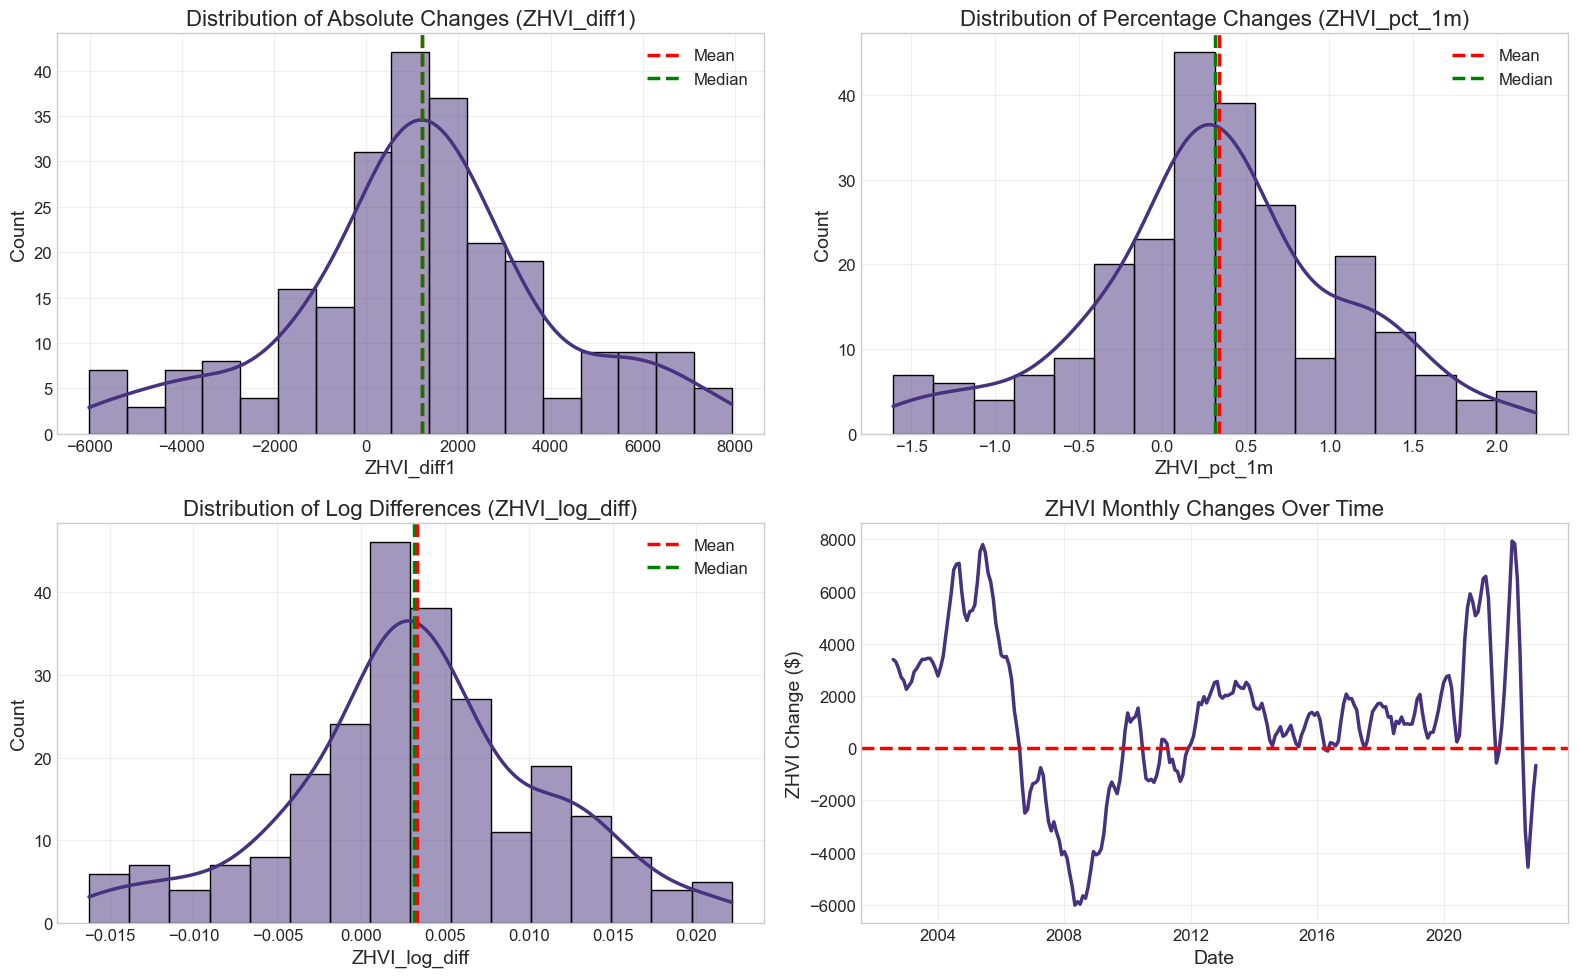


== Feature Selection Methods ==

LASSO Feature Selection:
Optimal alpha: 10.000000
LASSO selected 20 features

LASSO Selected Features:
                             Feature  Coefficient
11          interest_to_unemployment    -26789.82
0                      Interest_Rate      4600.18
3            Unemployment_Rate_lag10      2916.34
14                Interest_Rate_lag6     -1737.30
20             unemployment_momentum     -1450.64
13                Interest_Rate_lag3      1248.15
23                 high_unemployment      1038.82
21                  poverty_momentum      -878.30
16           Unemployment_Rate_lag15      -780.84
18                Poverty_Rate_lag18      -536.14
22               rising_rates_regime       329.02
10        Unemployment_Rate_lag10_sq      -257.63
7              real_mortgage_rate_sq      -185.78
5      mort_unemployment_interaction      -153.13
17                 Poverty_Rate_lag6       144.60
6   poverty_unemployment_interaction       105.21
4           m

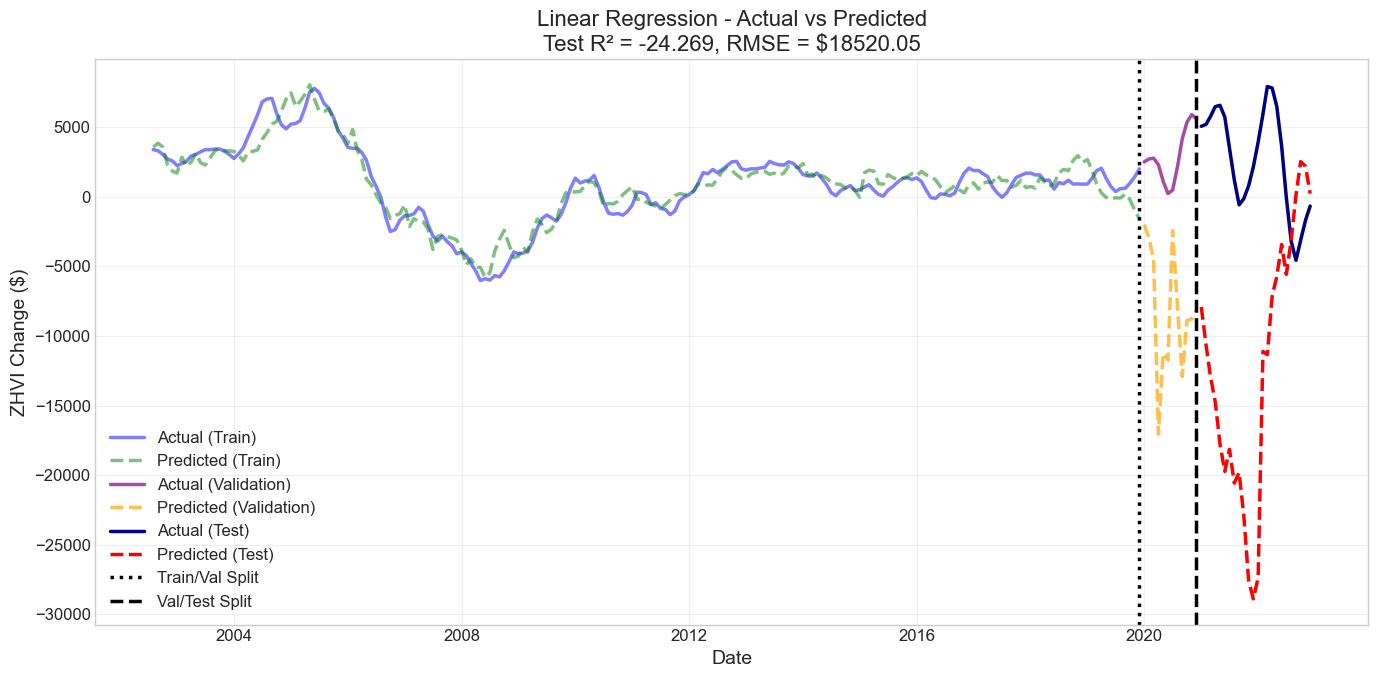

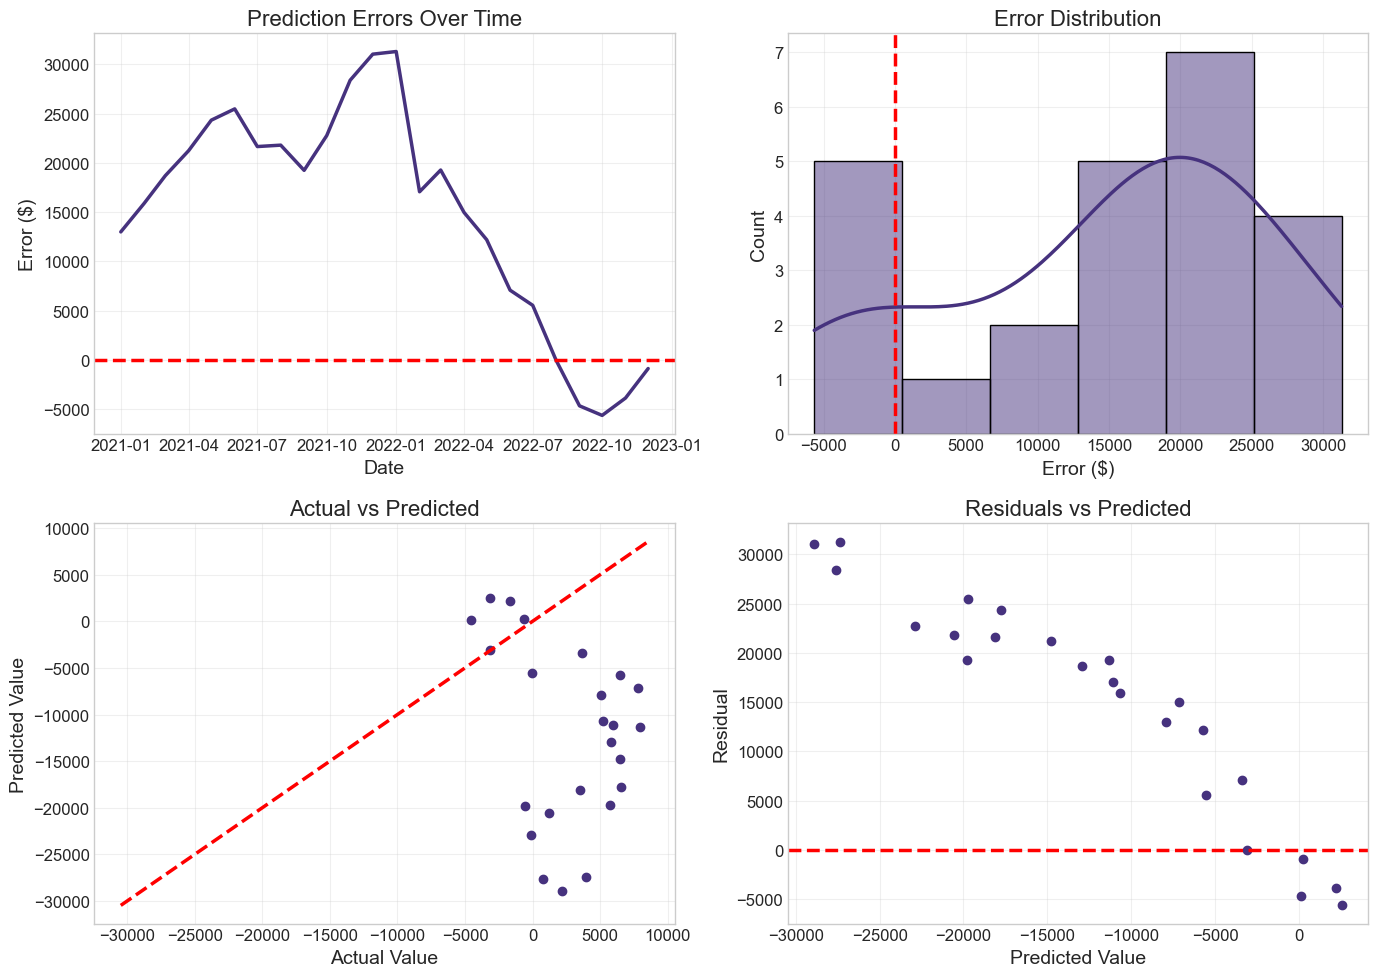

Best Ridge alpha: 1000.0000 with validation RMSE = $3556.84, R² = -2.685


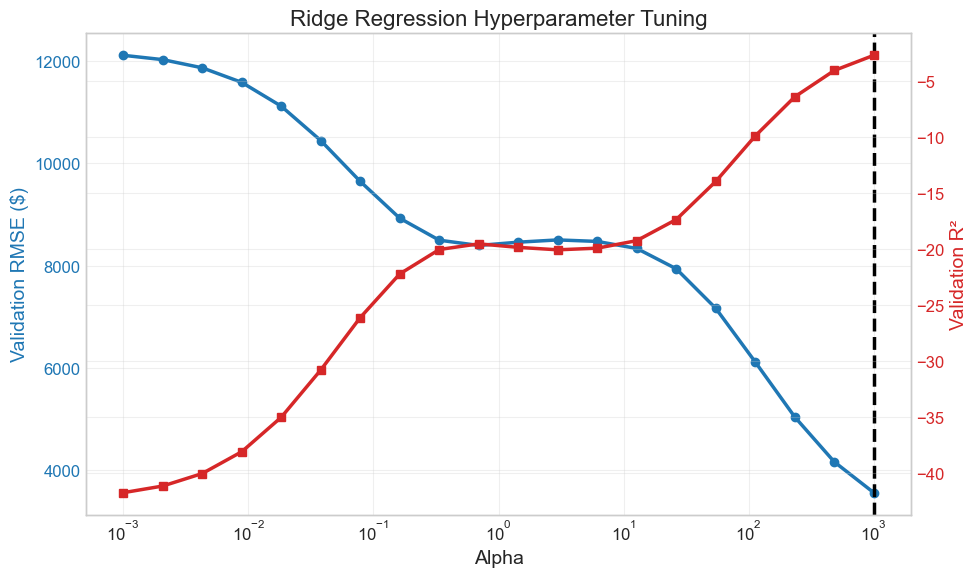


=== Ridge Regression (Tuned) Evaluation ===
Training RMSE: $2470.19, R²: 0.170
Validation RMSE: $3556.84, R²: -2.685
Test RMSE: $3978.92, R²: -0.166


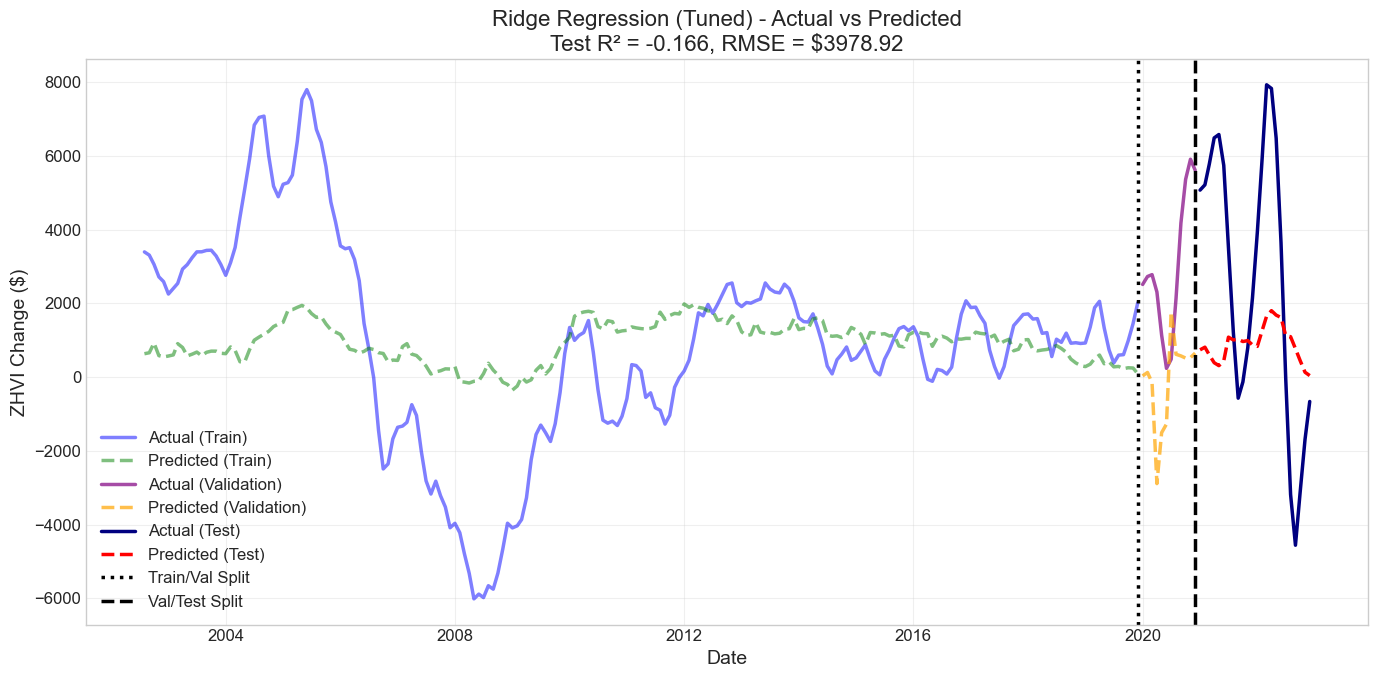

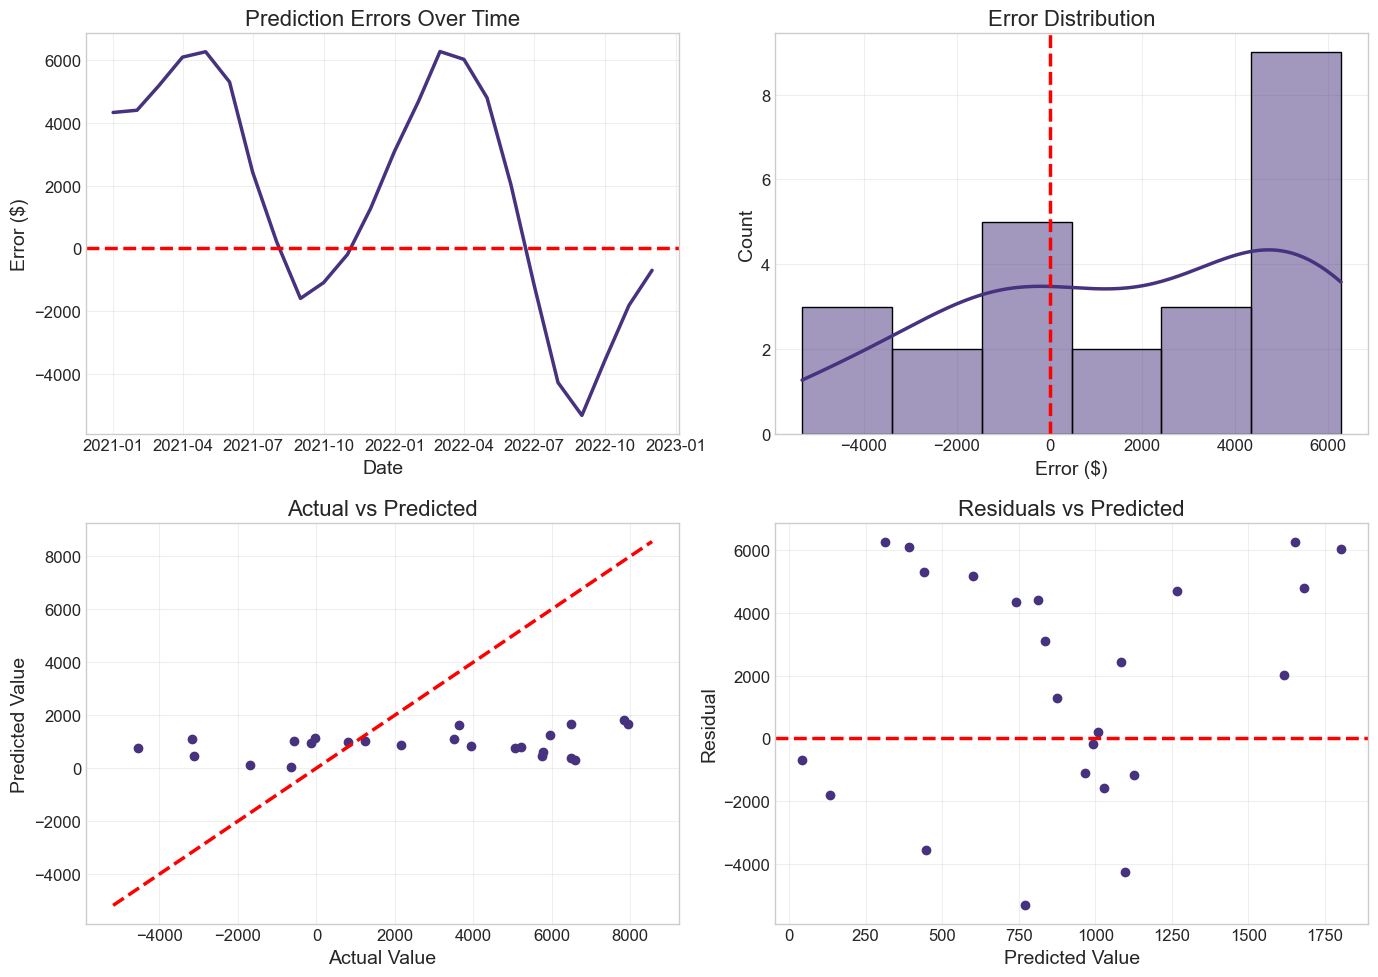

Best ElasticNet parameters: alpha=10.0000, l1_ratio=0.1
Validation RMSE = $3222.02, R² = -2.024


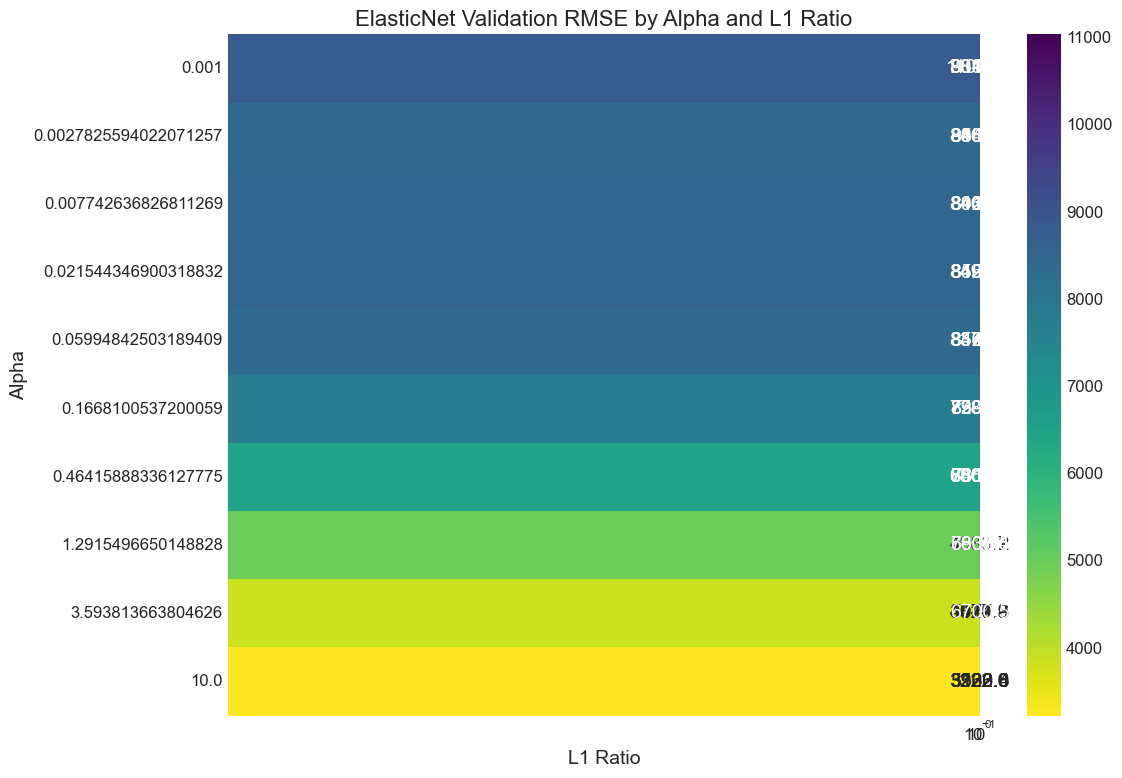


=== ElasticNet (Tuned) Evaluation ===
Training RMSE: $2547.18, R²: 0.118
Validation RMSE: $3222.02, R²: -2.024
Test RMSE: $4001.32, R²: -0.180


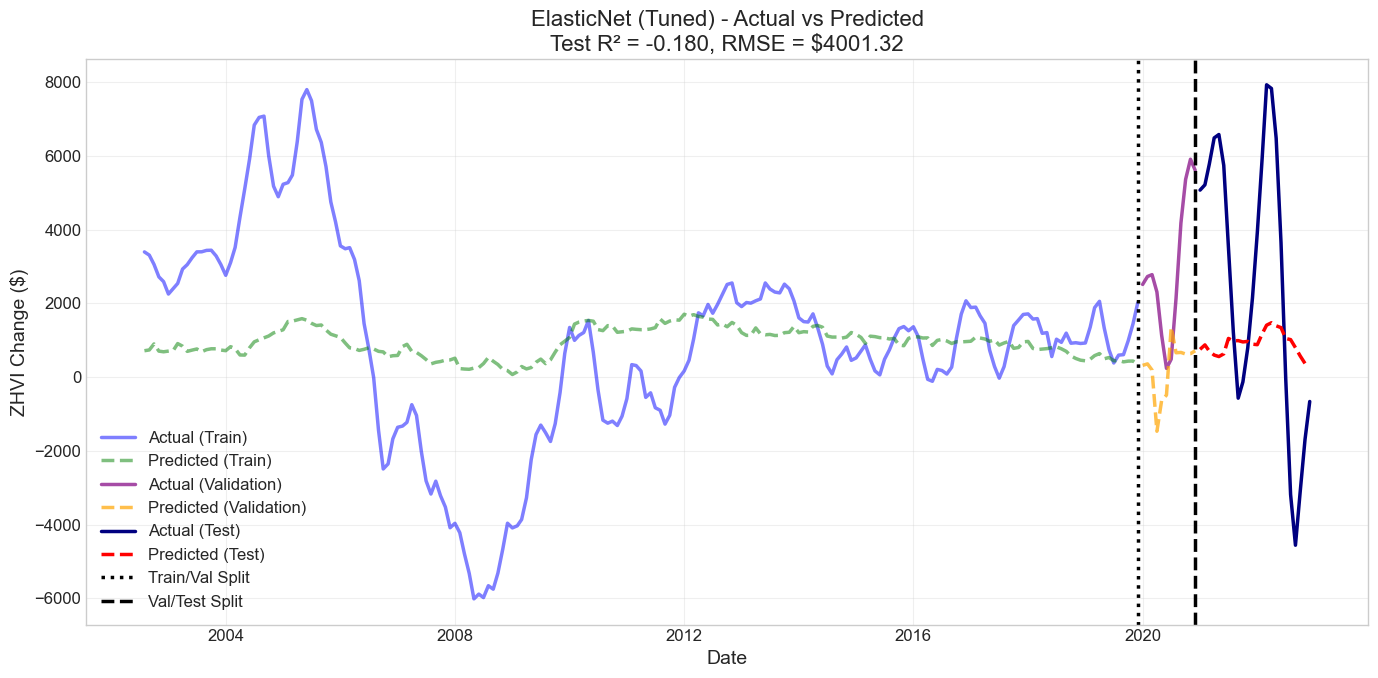

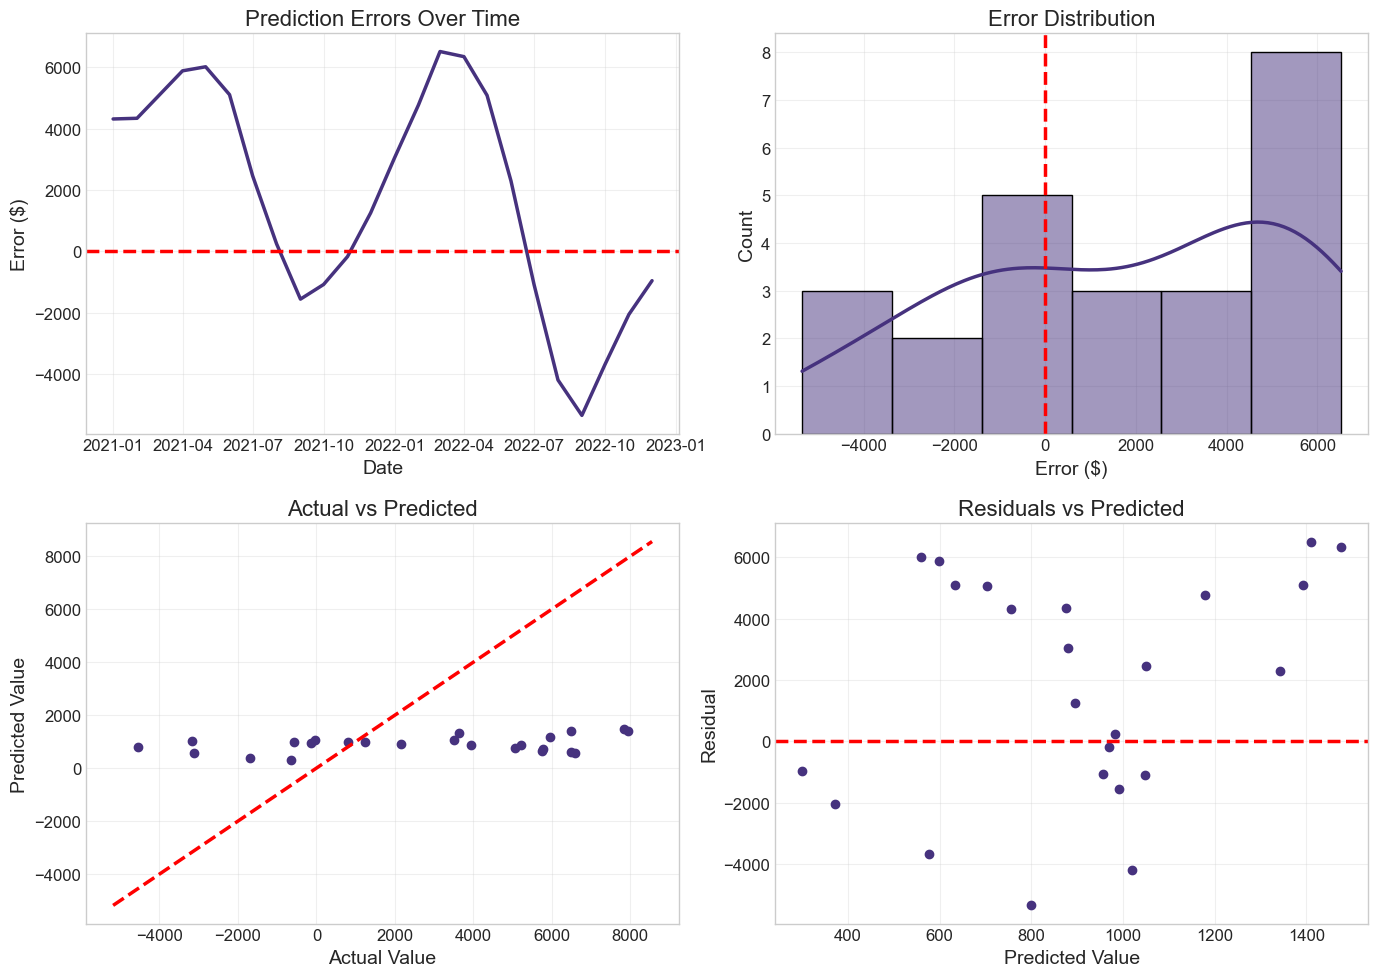


=== Lasso Regression Evaluation ===
Training RMSE: $962.21, R²: 0.874
Validation RMSE: $11093.68, R²: -34.848
Test RMSE: $12222.10, R²: -10.005


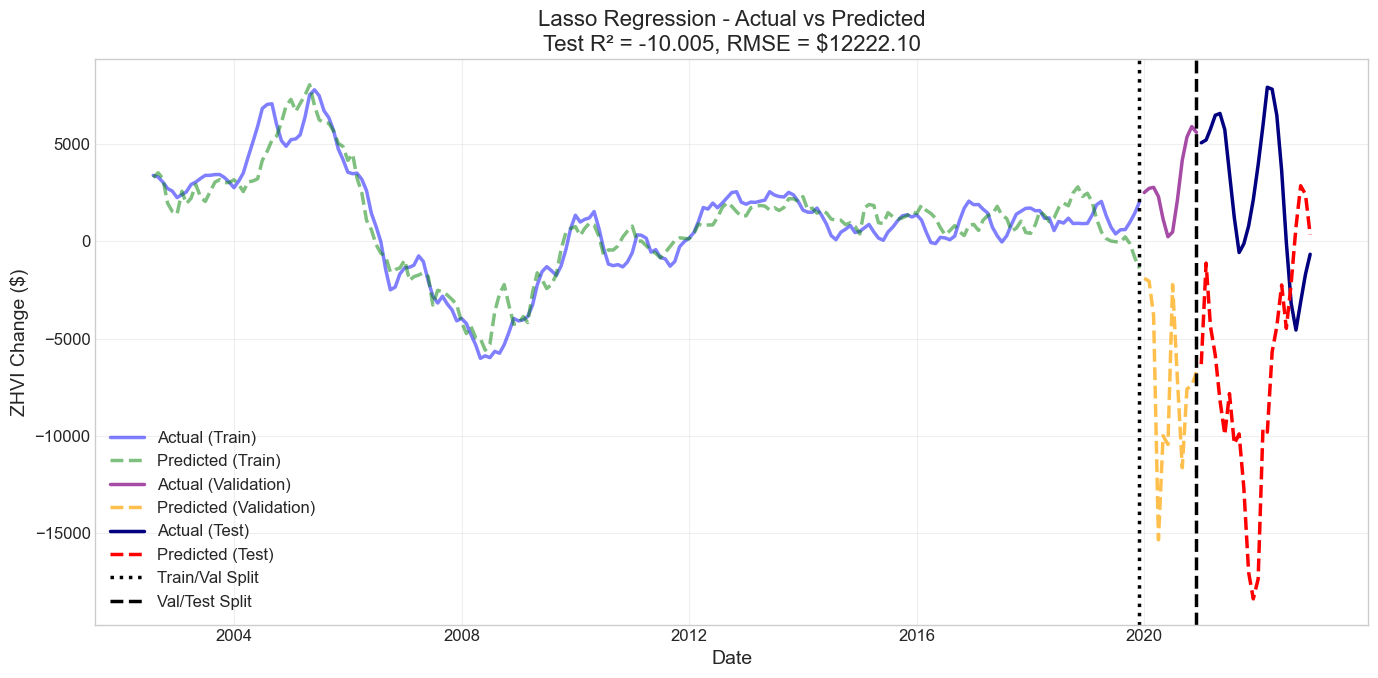

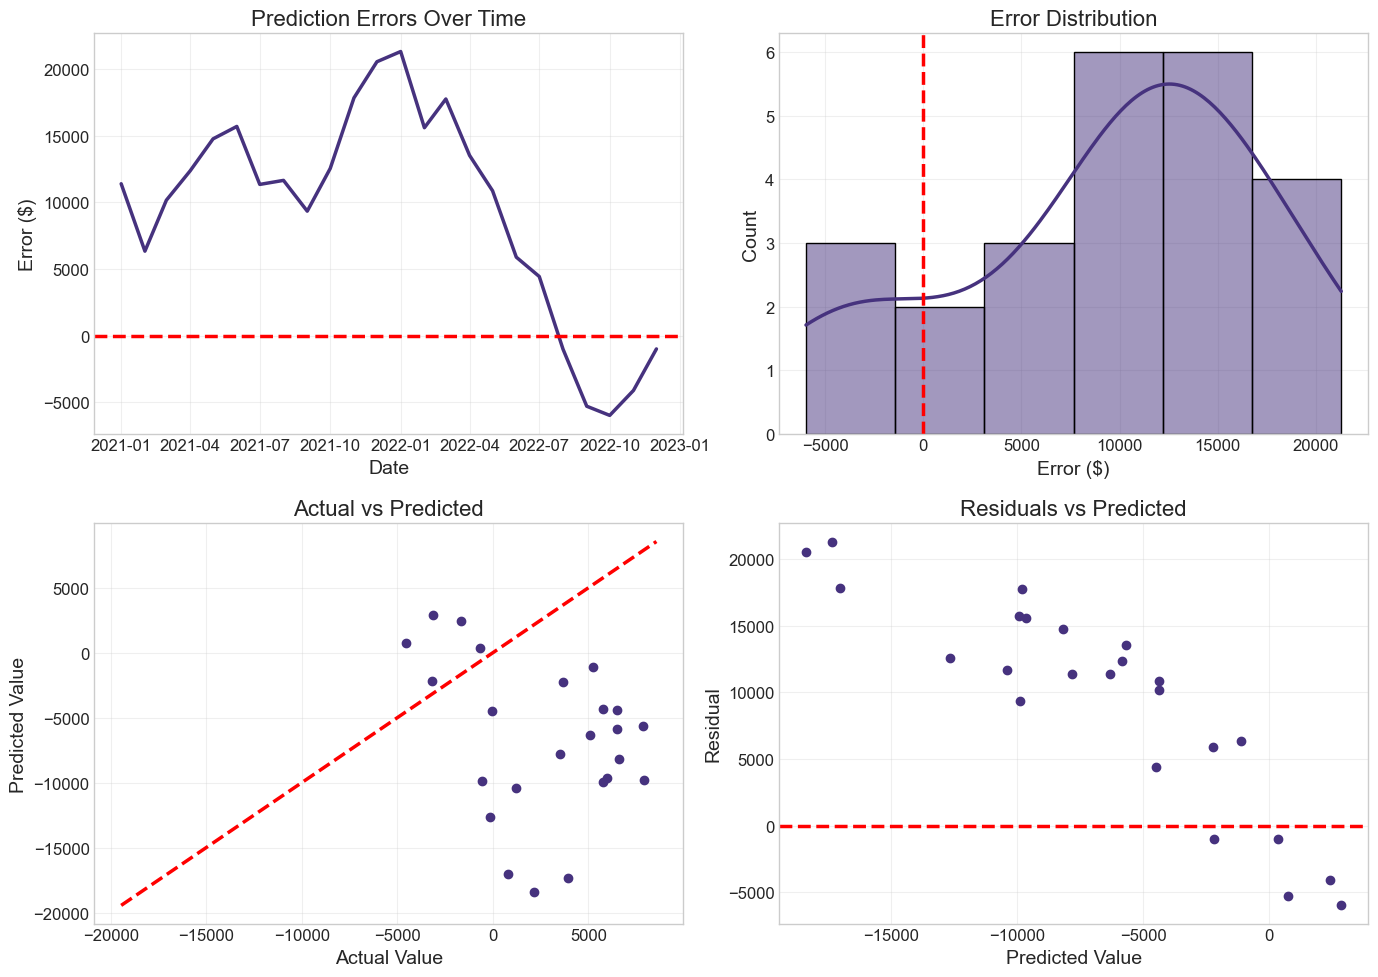

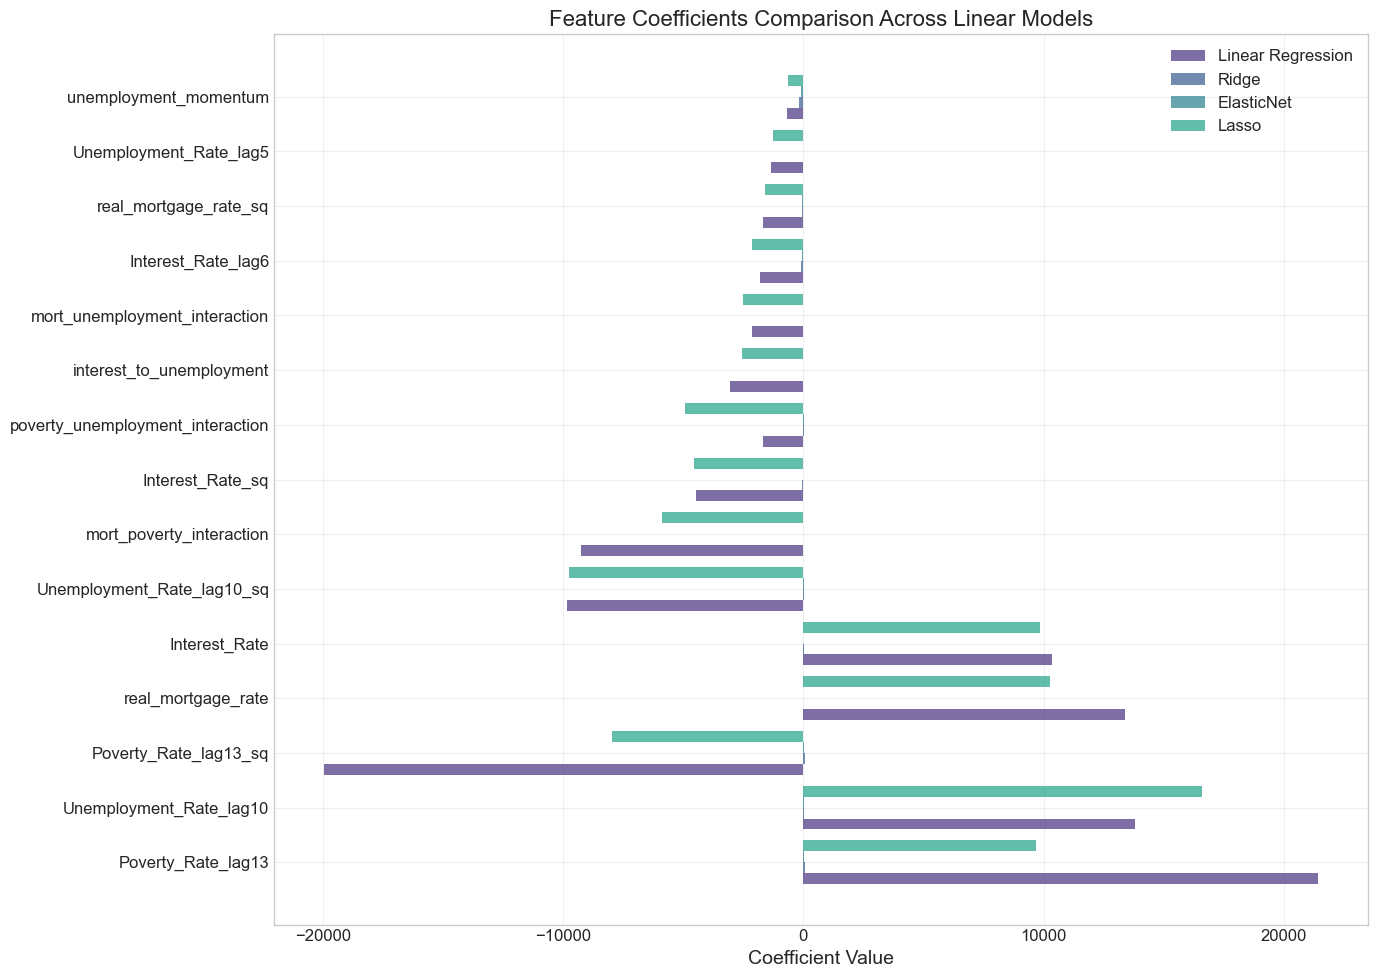


Top 10 features by mean absolute coefficient:
                             Feature  Mean_Abs_Coef
1                 Poverty_Rate_lag13        7810.00
20           Unemployment_Rate_lag10        7616.31
8              Poverty_Rate_lag13_sq        7001.11
2                 real_mortgage_rate        5927.33
17                     Interest_Rate        5058.69
10        Unemployment_Rate_lag10_sq        4901.70
9           mort_poverty_interaction        3789.07
11                  Interest_Rate_sq        2266.79
6   poverty_unemployment_interaction        1671.95
3           interest_to_unemployment        1401.21

== Tree-Based Models with Hyperparameter Tuning ==

Tuning Random Forest hyperparameters:
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best CV RMSE: $3764.90
Validation RMSE: $3784.21, R²: -3.171


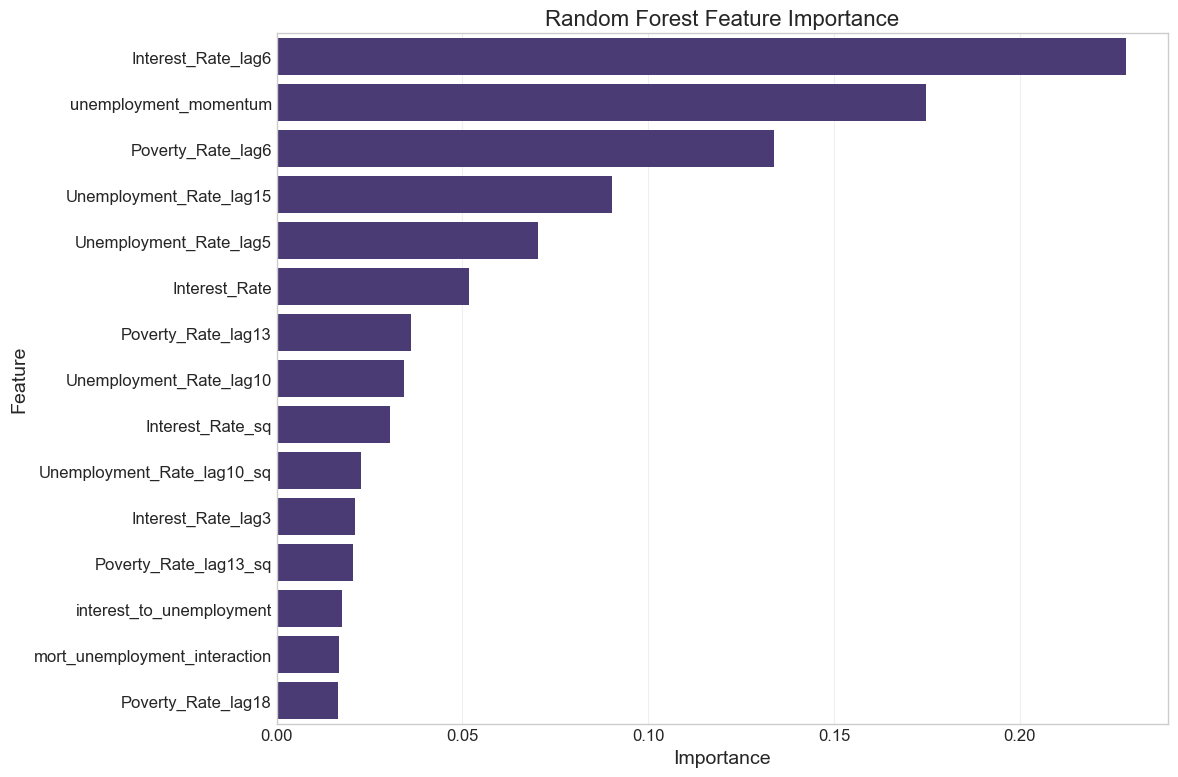


=== Random Forest (Tuned) Evaluation ===
Training RMSE: $361.08, R²: 0.982
Validation RMSE: $3784.21, R²: -3.171
Test RMSE: $4281.52, R²: -0.351


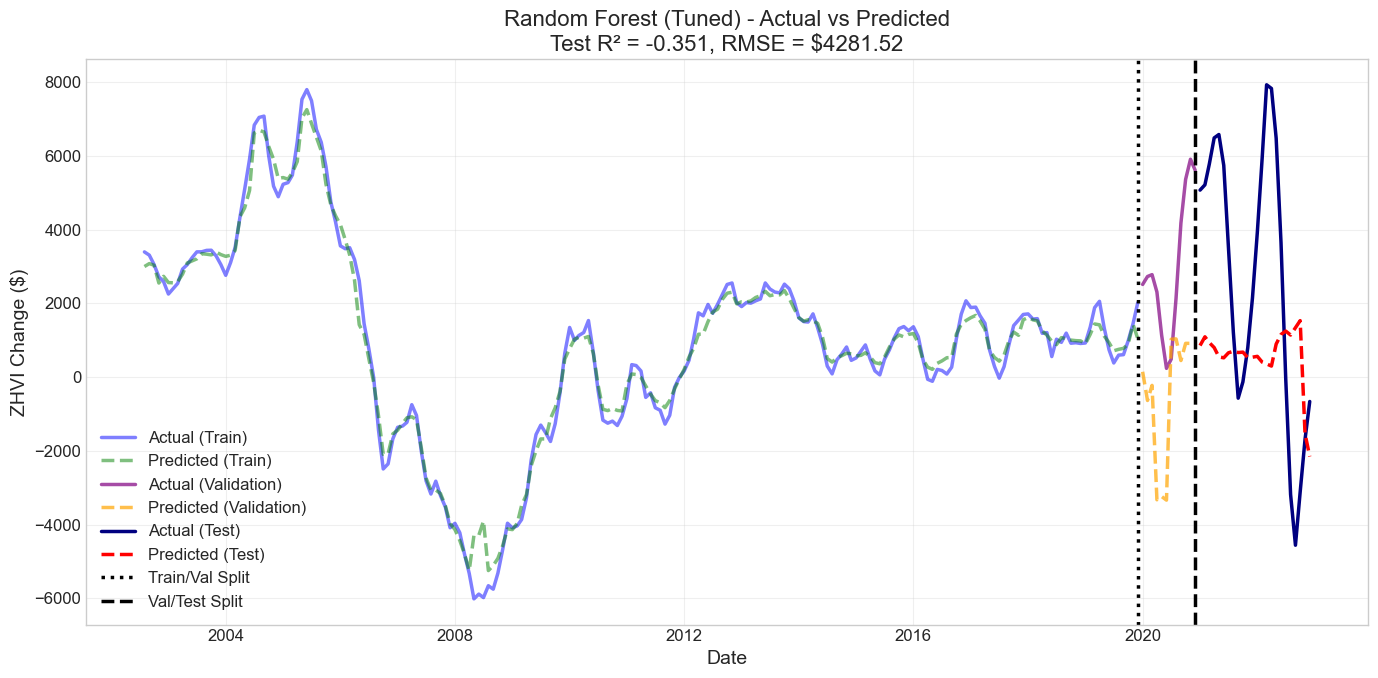

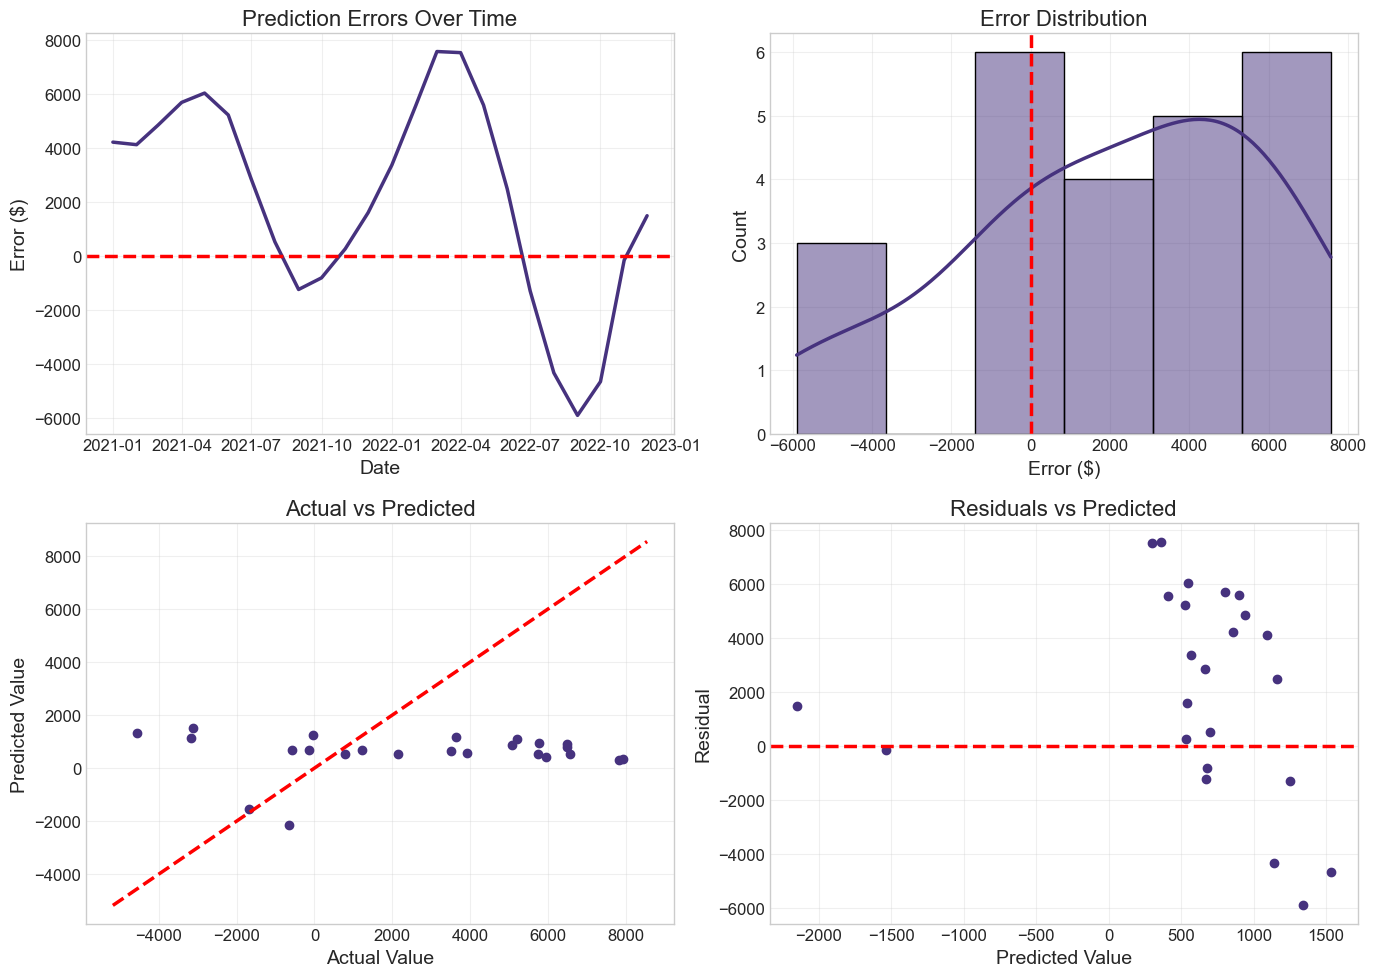


Top 10 features by Random Forest importance:
                       Feature  Importance
0           Interest_Rate_lag6        0.23
21       unemployment_momentum        0.17
16           Poverty_Rate_lag6        0.13
19     Unemployment_Rate_lag15        0.09
7       Unemployment_Rate_lag5        0.07
17               Interest_Rate        0.05
1           Poverty_Rate_lag13        0.04
20     Unemployment_Rate_lag10        0.03
11            Interest_Rate_sq        0.03
10  Unemployment_Rate_lag10_sq        0.02

Tuning XGBoost hyperparameters:
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV RMSE: $3273.72
Validation RMSE: $3262.58, R²: -2.101


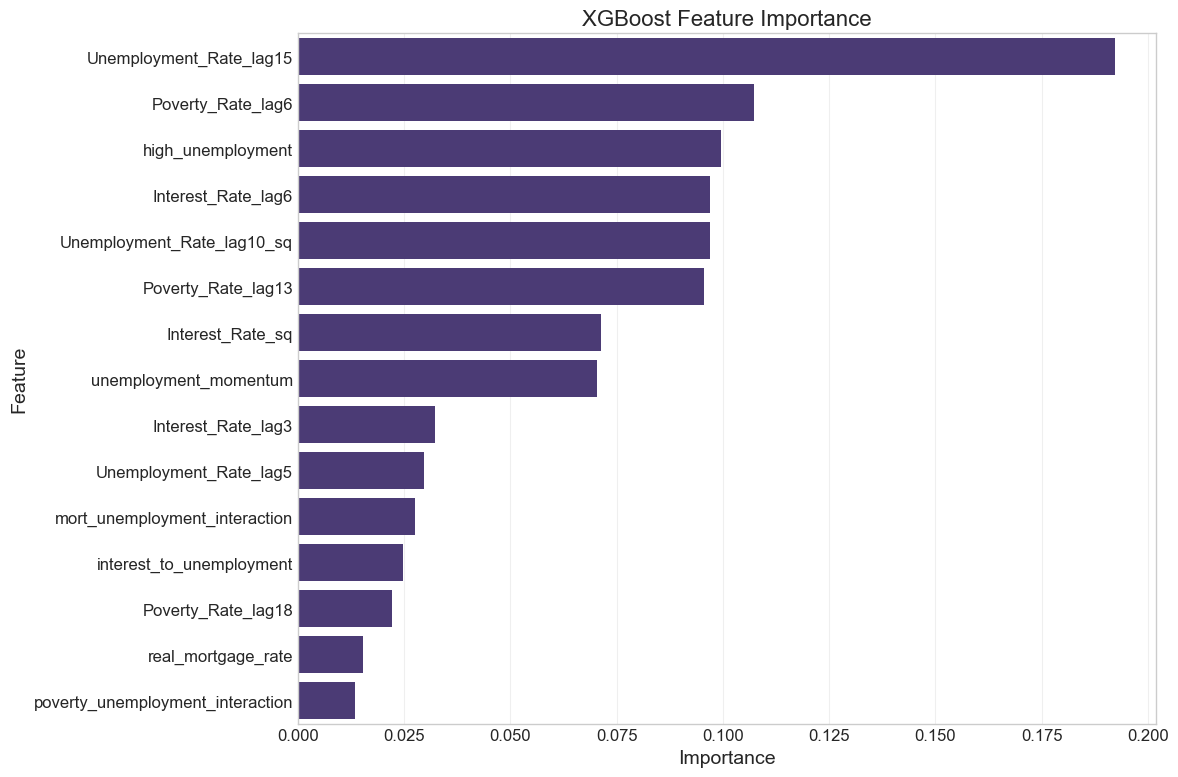


=== XGBoost (Tuned) Evaluation ===
Training RMSE: $1399.11, R²: 0.734
Validation RMSE: $3262.58, R²: -2.101
Test RMSE: $4119.79, R²: -0.250


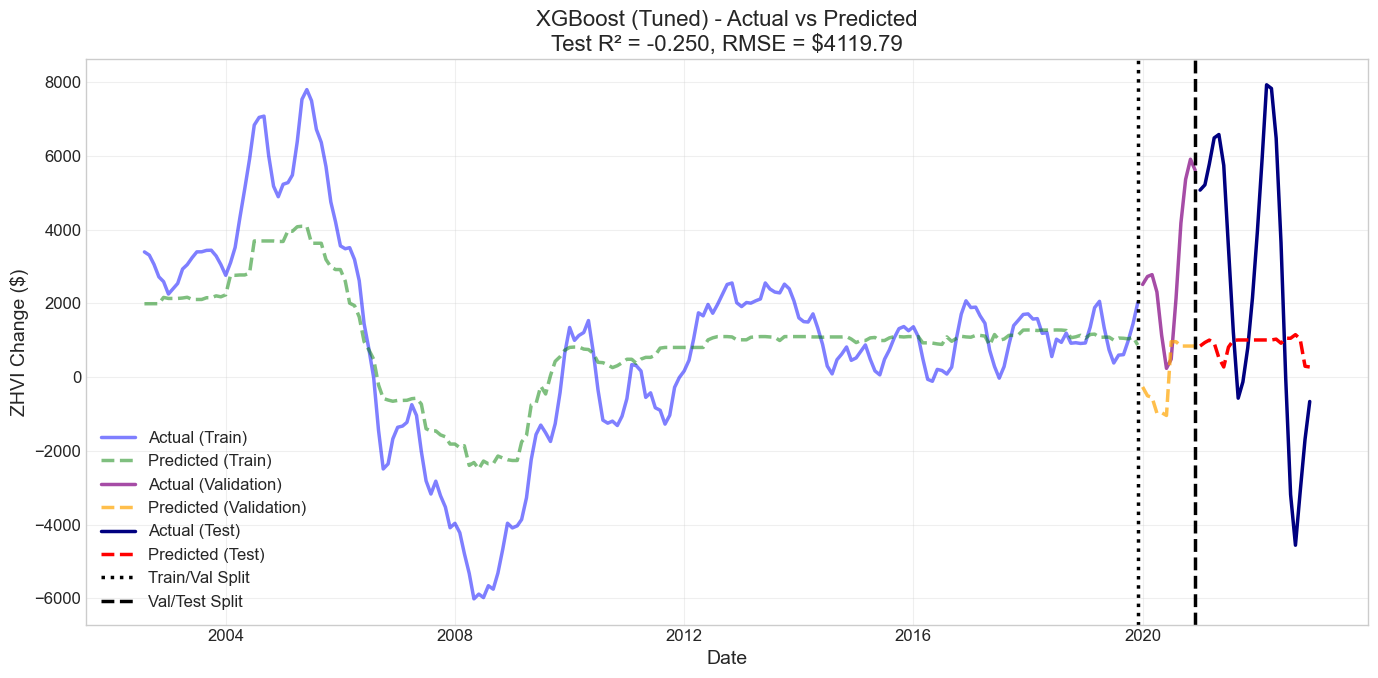

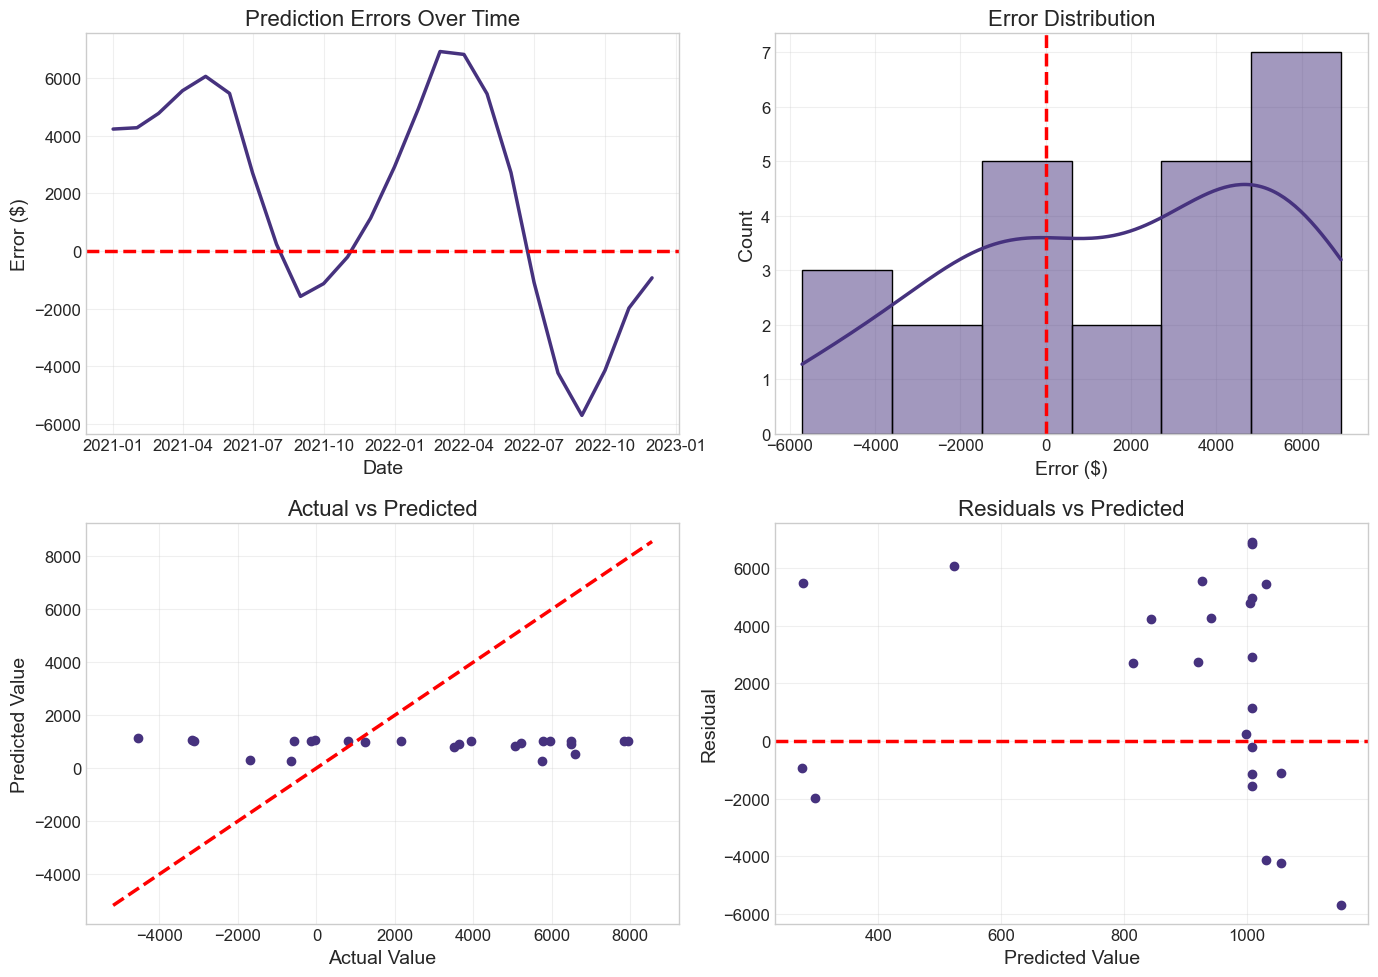


Top 10 features by XGBoost importance:
                       Feature  Importance
19     Unemployment_Rate_lag15        0.19
16           Poverty_Rate_lag6        0.11
4            high_unemployment        0.10
0           Interest_Rate_lag6        0.10
10  Unemployment_Rate_lag10_sq        0.10
1           Poverty_Rate_lag13        0.10
11            Interest_Rate_sq        0.07
21       unemployment_momentum        0.07
18          Interest_Rate_lag3        0.03
7       Unemployment_Rate_lag5        0.03


<Figure size 1500x1000 with 0 Axes>

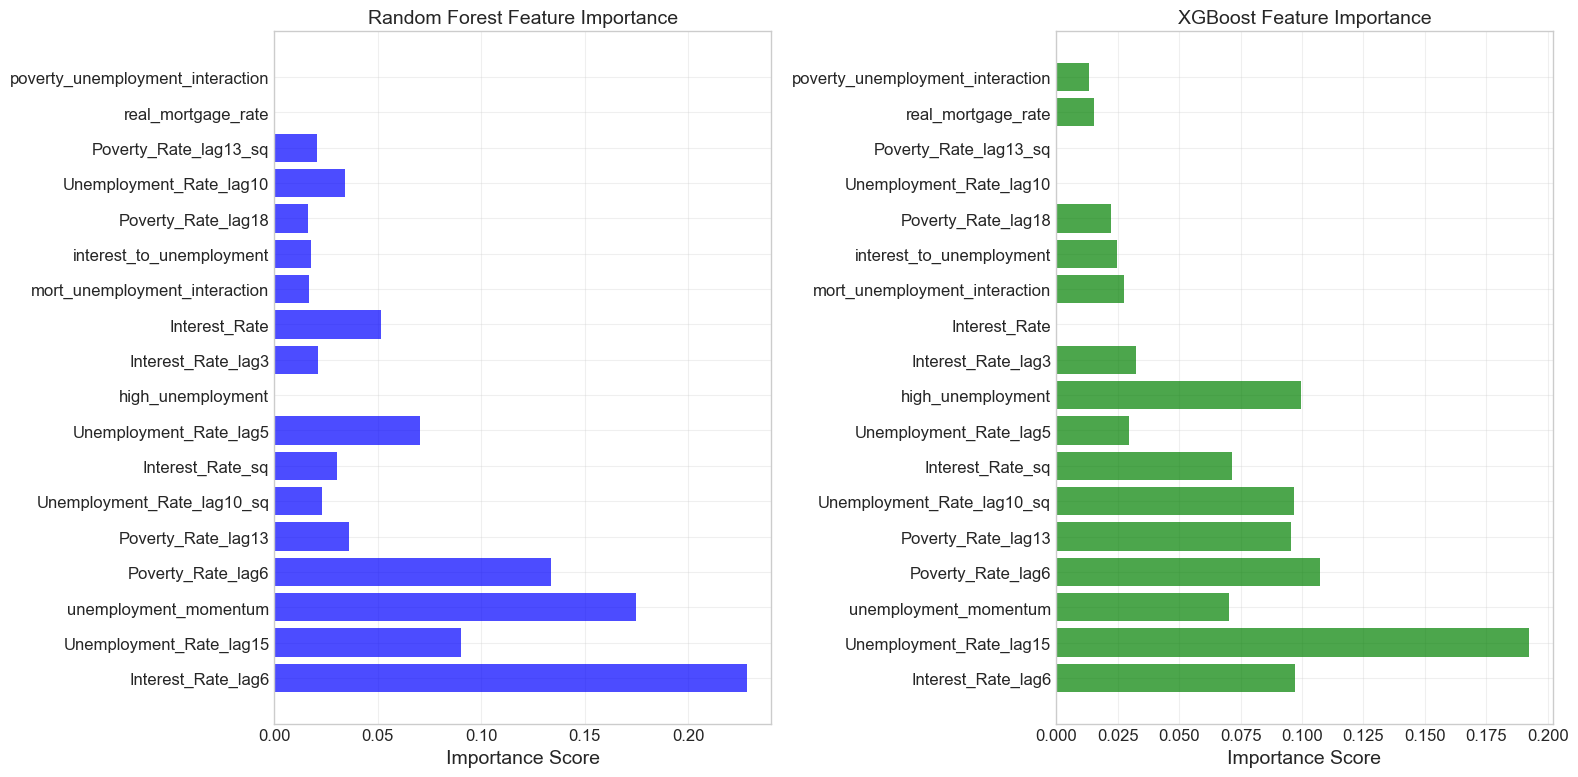


== Time Series Models ==

Fitting ARIMA model:
Best ARIMA order: (0, 1, 3) with AIC = 2985.57
Validation RMSE: $1955.35, R²: -0.114
Test RMSE: $4448.44, R²: -0.458


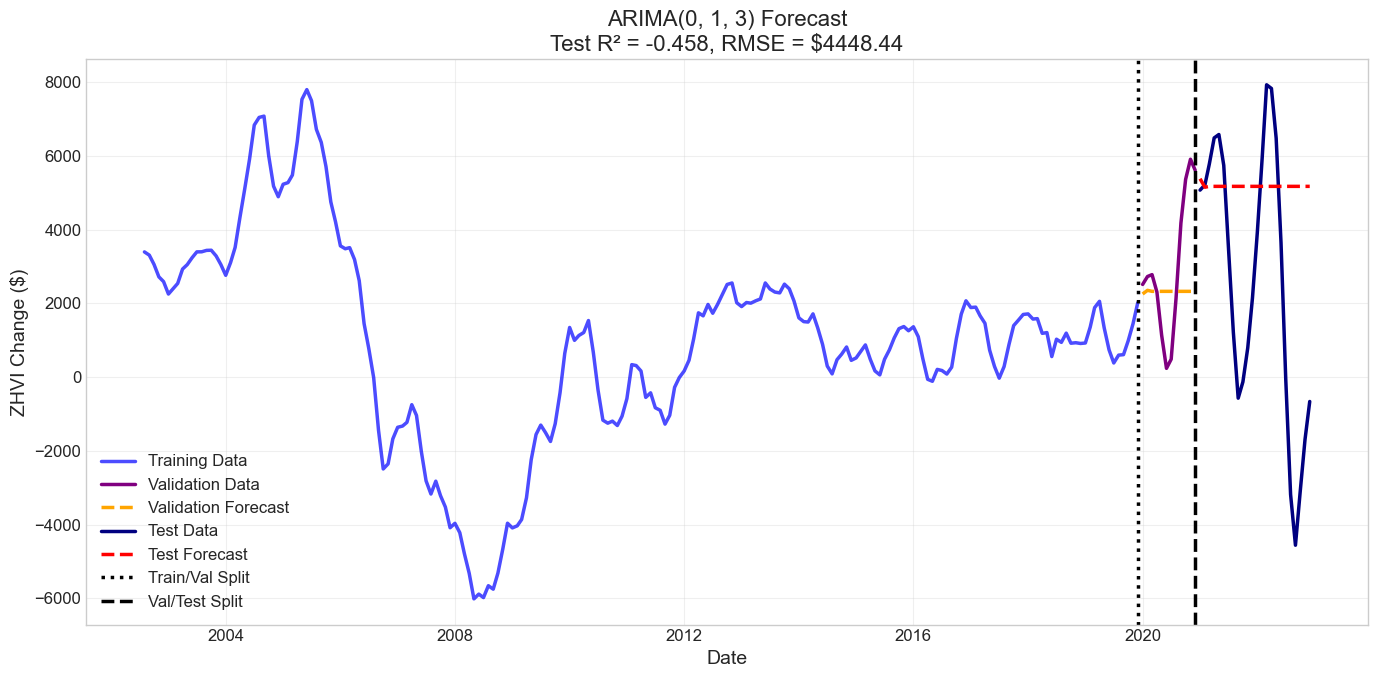


Fitting SARIMAX model:
Best SARIMAX order: (0, 1, 2), seasonal_order: (0, 0, 0, 0)
AIC: 2963.59
Validation RMSE: $2011.71, R²: -0.179
Test RMSE: $4814.38, R²: -0.708


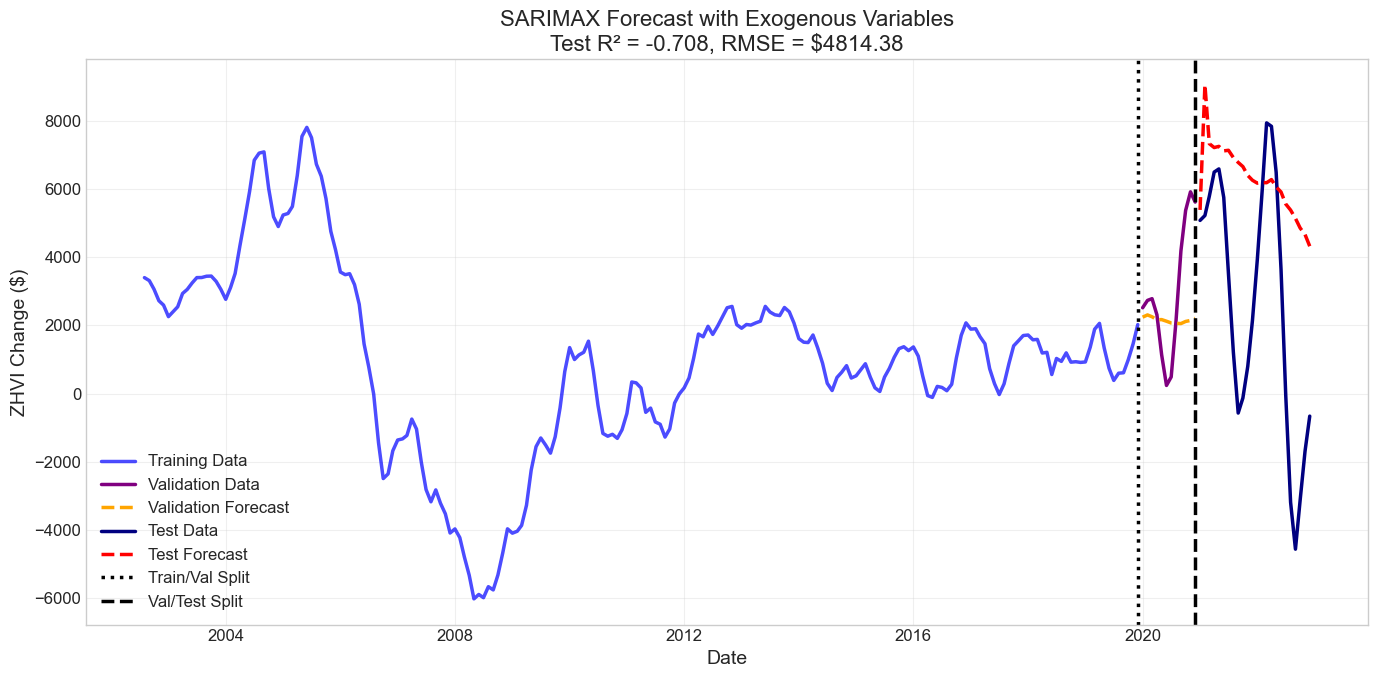


SARIMAX Model Summary:
                               SARIMAX Results                                
Dep. Variable:             ZHVI_diff1   No. Observations:                  221
Model:               SARIMAX(0, 1, 2)   Log Likelihood               -1575.089
Date:                Wed, 26 Mar 2025   AIC                           3164.178
Time:                        01:13:23   BIC                           3187.837
Sample:                    08-01-2002   HQIC                          3173.735
                         - 12-01-2020                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interest_Rate            -140.1629    127.816     -1.097      0.273    -390.678     110.352
real_mortgage_rate        -49.9555     56.390     -0.886      0.376 

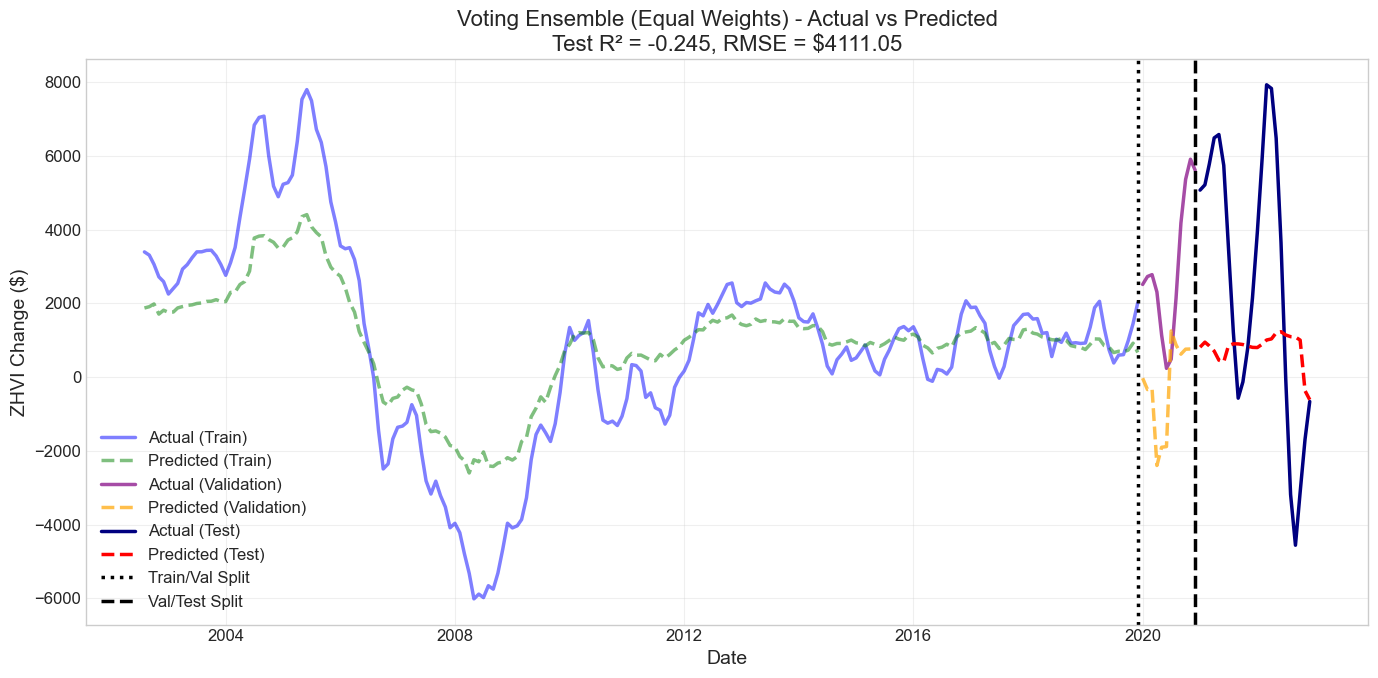

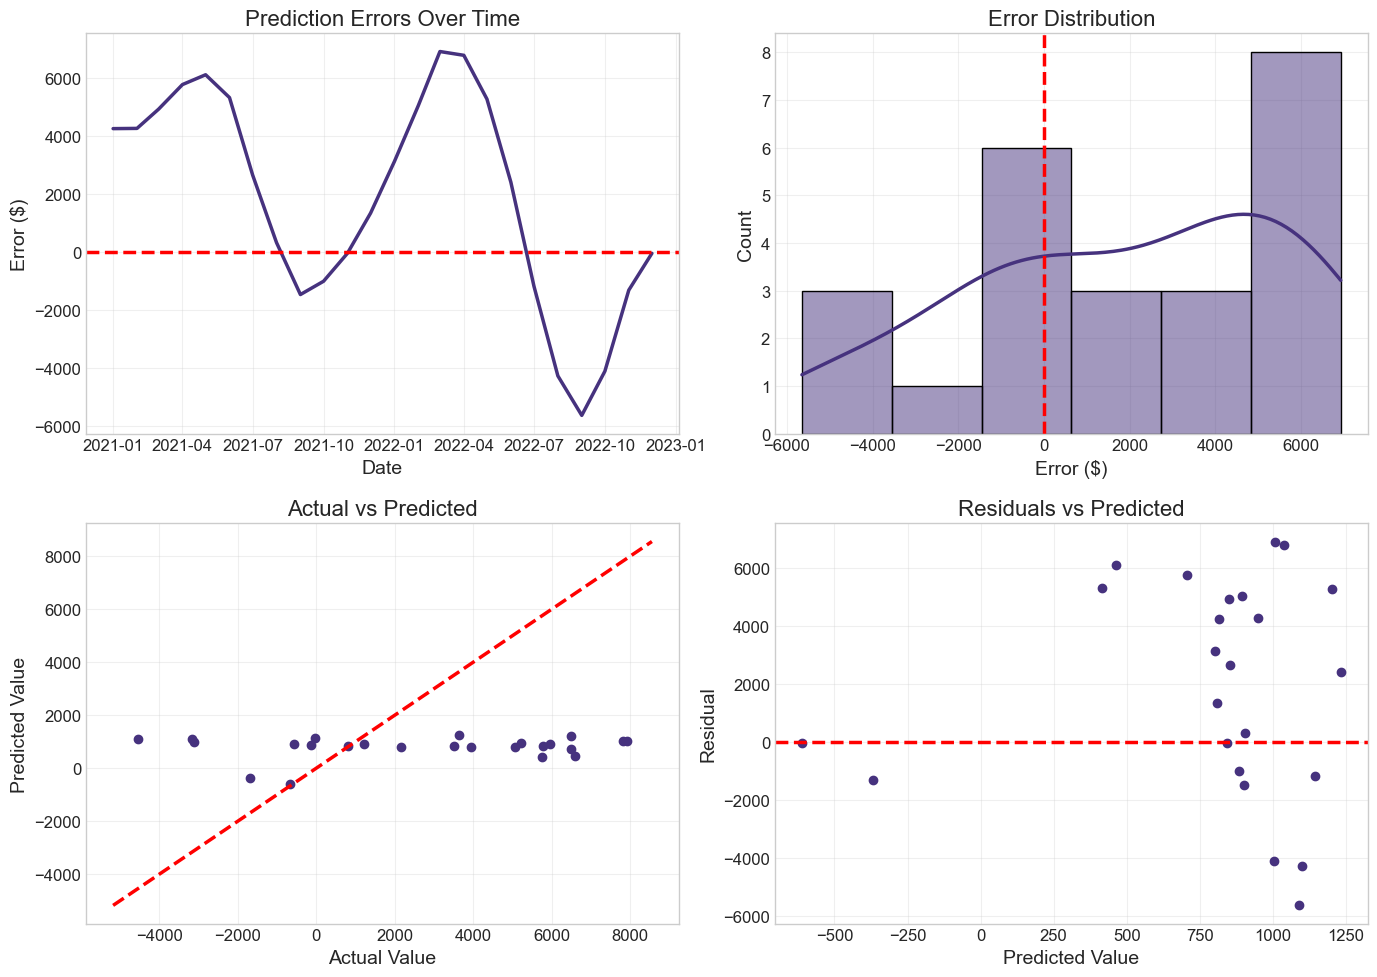


Model weights based on validation R²: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]

Creating voting ensemble with R² weights:

=== Voting Ensemble (R² Weights) Evaluation ===
Training RMSE: $1342.95, R²: 0.755
Validation RMSE: $3499.77, R²: -2.568
Test RMSE: $4111.05, R²: -0.245


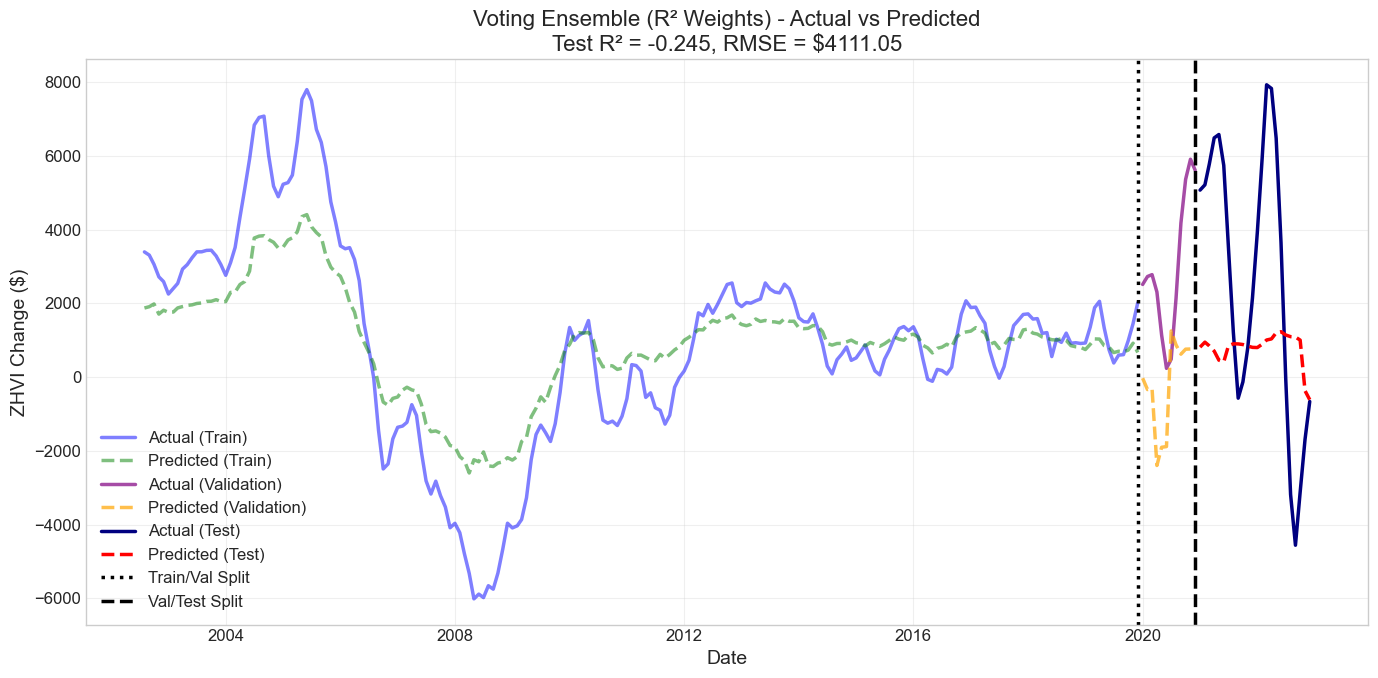

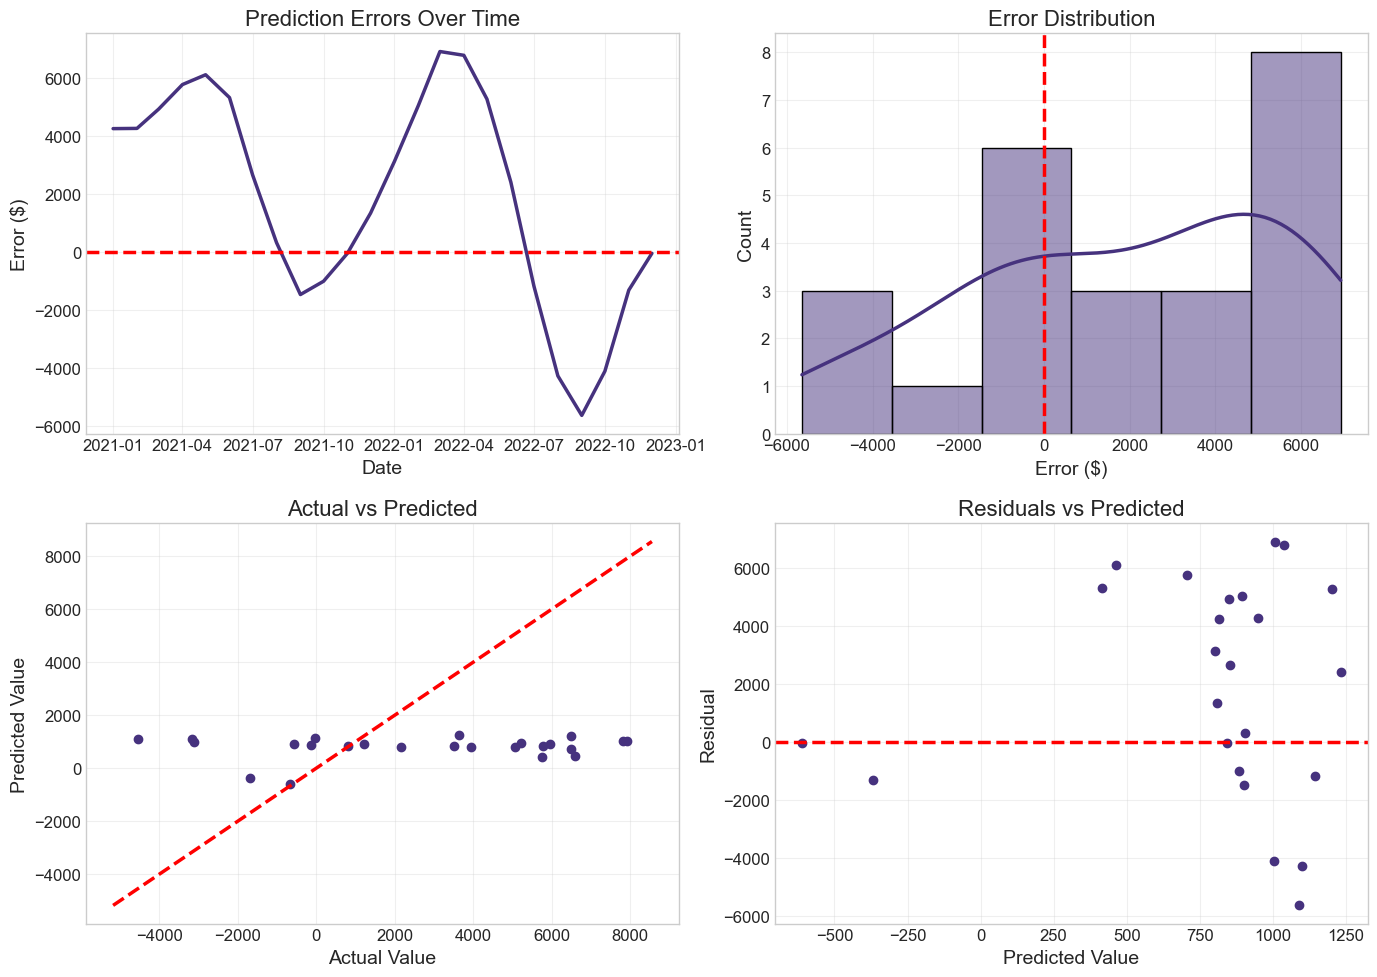


Creating stacking ensemble with ElasticNet meta-learner:

=== Stacking Ensemble Evaluation ===
Training RMSE: $3135.82, R²: -0.337
Validation RMSE: $2702.23, R²: -1.127
Test RMSE: $4121.69, R²: -0.252


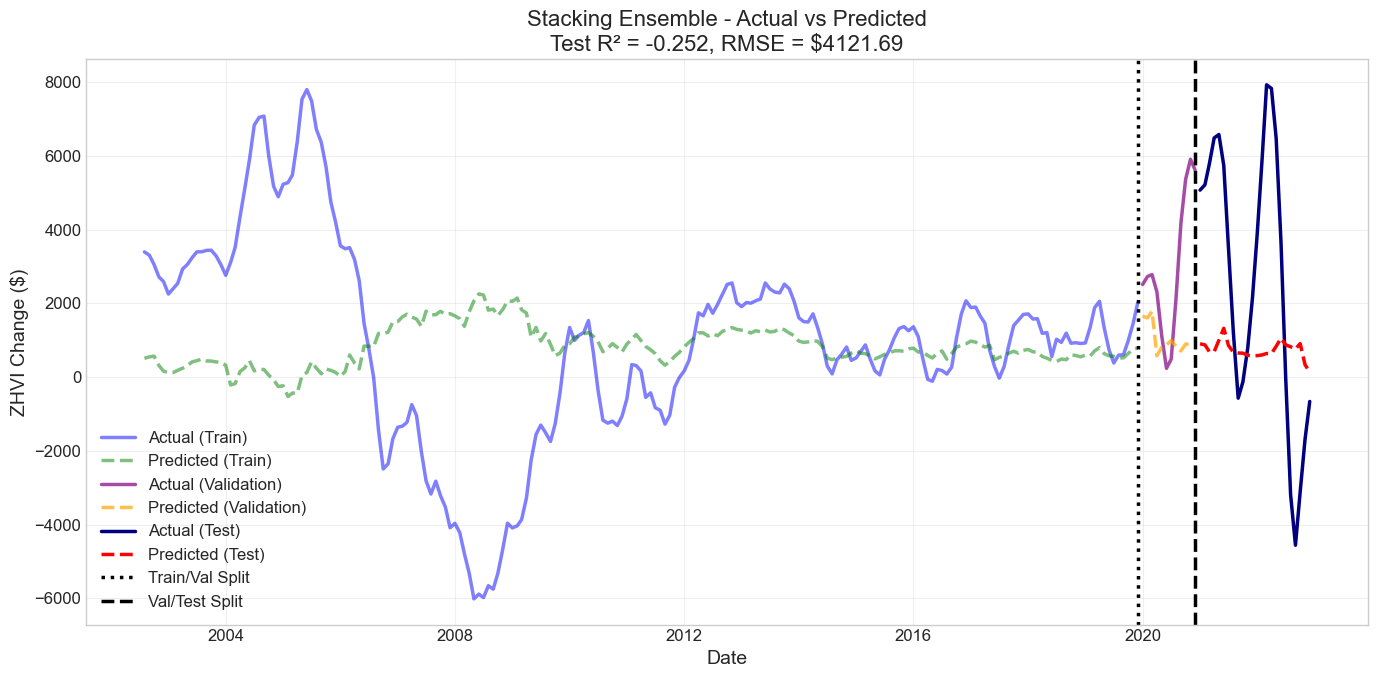

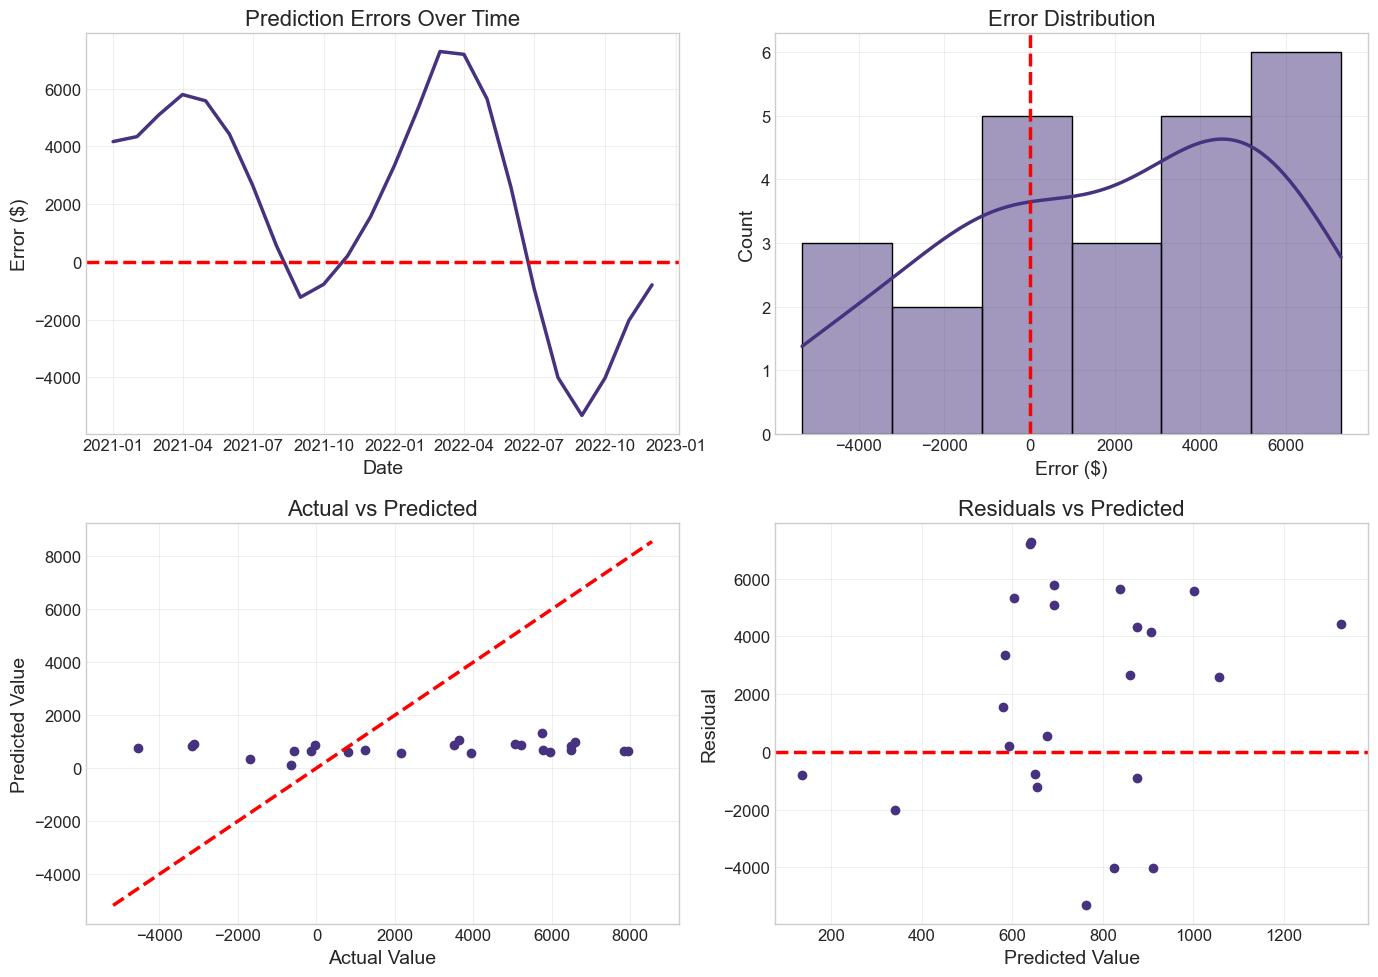


== Model Comparison and Selection ==

== Models Sorted by Test R² ==
                         Model         Type  Test RMSE  Test R²  Overfitting Score
1             Ridge Regression       Linear    3978.92    -0.17              33.66
2                   ElasticNet       Linear    4001.32    -0.18              29.72
9   Voting Ensemble (Weighted)     Ensemble    4111.05    -0.25              99.99
8      Voting Ensemble (Equal)     Ensemble    4111.05    -0.25              99.99
5                      XGBoost         Tree    4119.79    -0.25              98.42
10           Stacking Ensemble     Ensemble    4121.69    -0.25               8.56
4                Random Forest         Tree    4281.52    -0.35             133.28
6                        ARIMA  Time Series    4448.44    -0.46                NaN
7                      SARIMAX  Time Series    4814.38    -0.71                NaN
3             Lasso Regression       Linear   12222.10   -10.01            1087.92
0            Line

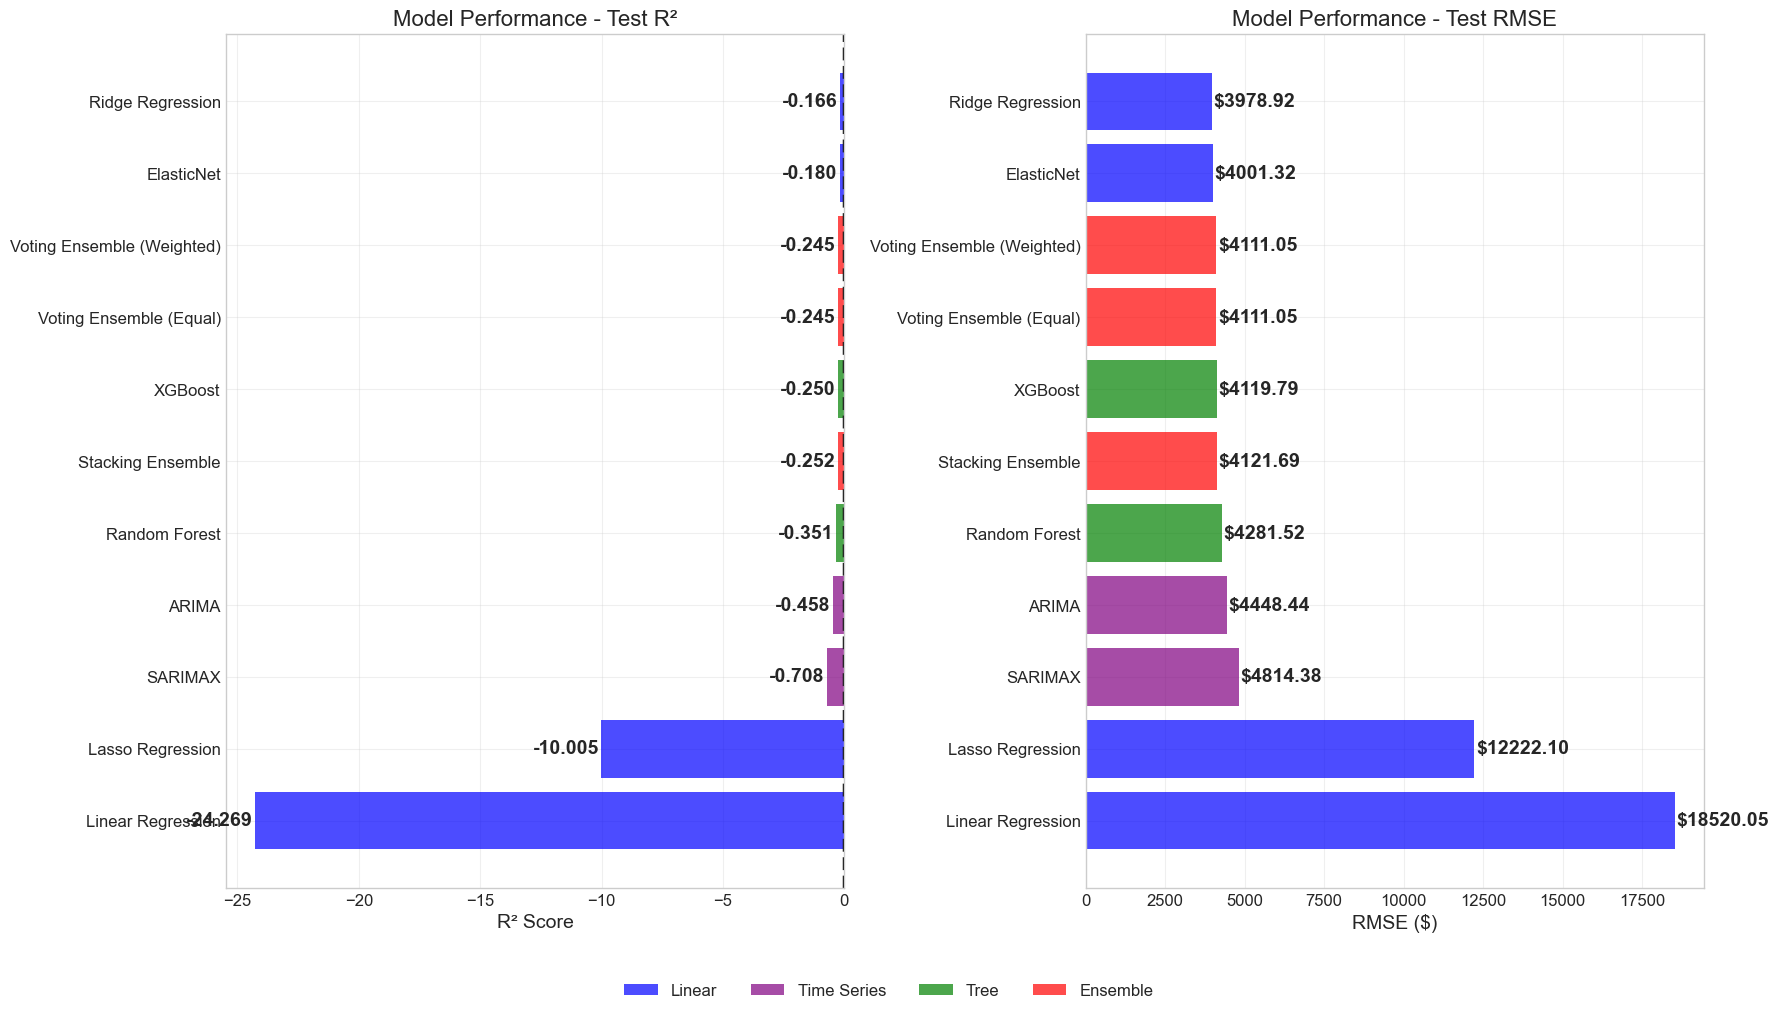

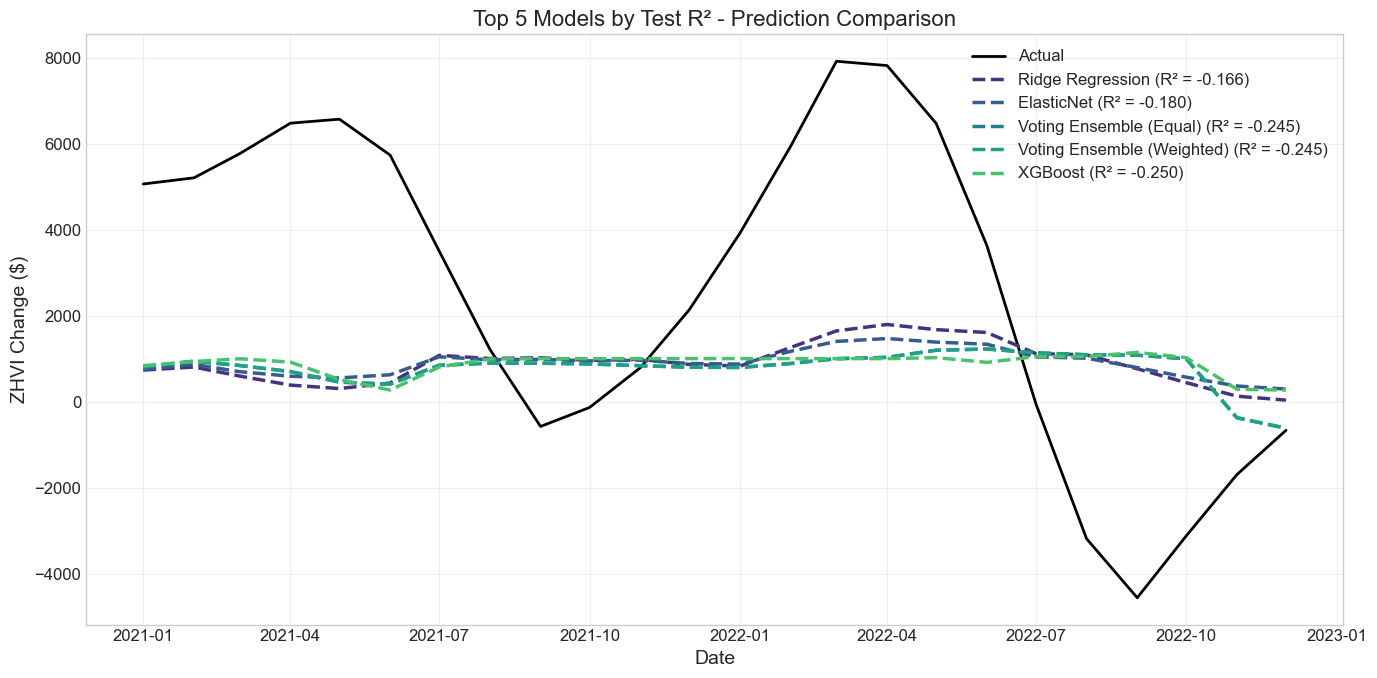

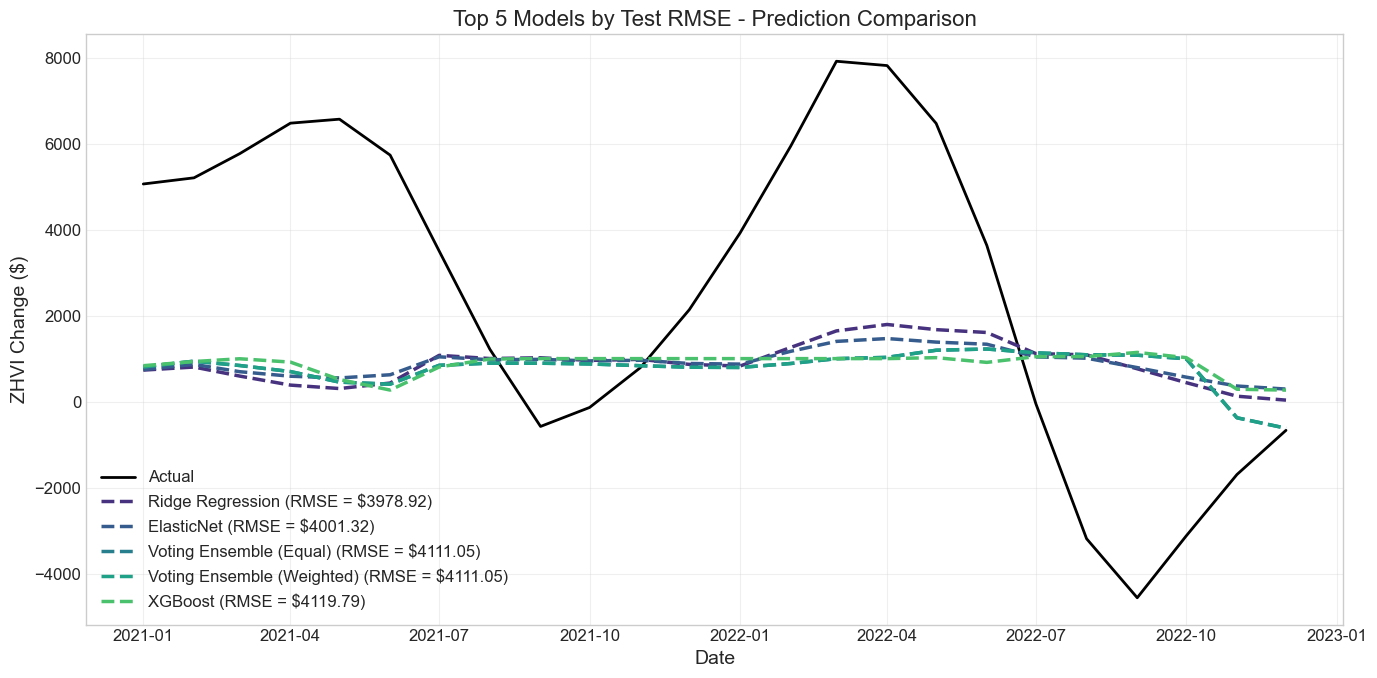


== Time-Weighted Evaluation ==

Time-Weighted Metrics for Top Models:
                        Model  Standard R²  Time-Weighted R²  Standard RMSE  Time-Weighted RMSE  R² Difference
0            Ridge Regression        -0.17              0.14        3978.92             3657.15           0.31
1                  ElasticNet        -0.18              0.10        4001.32             3743.00           0.28
2     Voting Ensemble (Equal)        -0.25              0.04        4111.05             3878.13           0.28
3  Voting Ensemble (Weighted)        -0.25              0.04        4111.05             3878.13           0.28
4                     XGBoost        -0.25              0.01        4119.79             3937.24           0.26


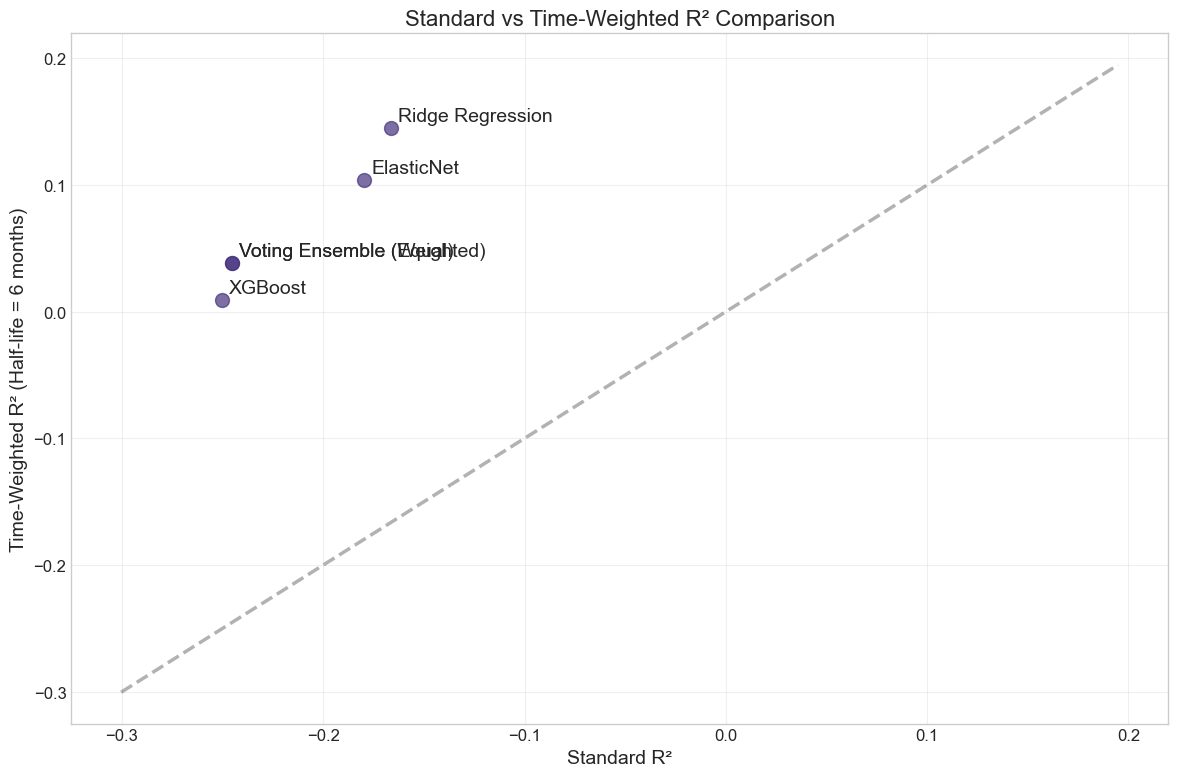


== Regime-Based Modeling Analysis ==

=== Pre-COVID Model Evaluation ===
Training RMSE: $819.58, R²: 0.916
Validation RMSE: $1560.00, R²: -244.338
Test RMSE: $2981.86, R²: -19.735

=== Post-COVID Model Evaluation ===
Training RMSE: $0.00, R²: 1.000
Validation RMSE: $11648.84, R²: -71.075
Test RMSE: $18885.96, R²: -17.447

=== Regime Comparison: LinearRegression ===
Pre-COVID Test R²: -19.735, RMSE: $2981.86
Post-COVID Test R²: -17.447, RMSE: $18885.96

Coefficient Comparison (Top 10 by difference):
                             Feature  Pre-COVID Coefficient  Post-COVID Coefficient  Abs Difference
9         Unemployment_Rate_lag10_sq              -10882.85                20102.17        30985.02
5              Poverty_Rate_lag13_sq              -22146.88                 2200.06        24346.94
4                 Poverty_Rate_lag13               24208.49                 2200.06        22008.43
8            Unemployment_Rate_lag10               16309.89                -4186.57        2049

<Figure size 1200x800 with 0 Axes>

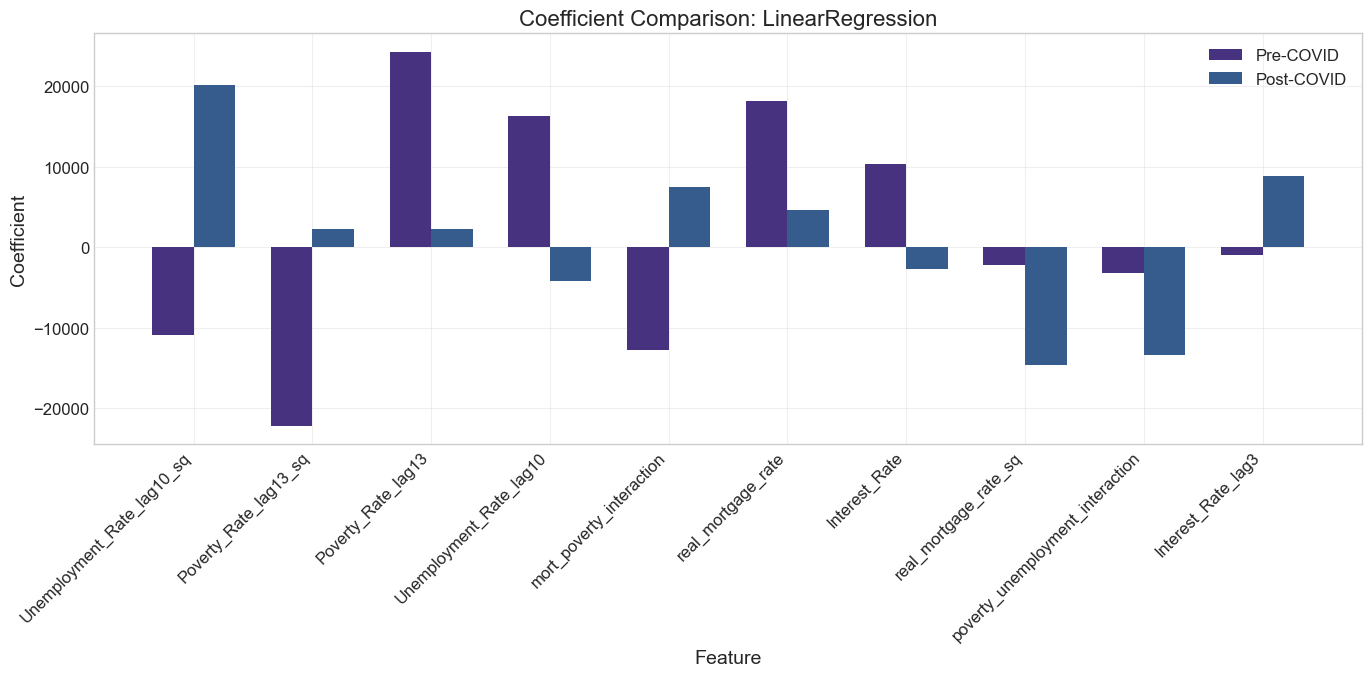


=== Pre-COVID Model Evaluation ===
Training RMSE: $2546.08, R²: 0.188
Validation RMSE: $792.67, R²: -62.344
Test RMSE: $1540.20, R²: -4.532

=== Post-COVID Model Evaluation ===
Training RMSE: $1862.04, R²: 0.202
Validation RMSE: $3287.90, R²: -4.742
Test RMSE: $4660.48, R²: -0.123

=== Regime Comparison: Ridge ===
Pre-COVID Test R²: -4.532, RMSE: $1540.20
Post-COVID Test R²: -0.123, RMSE: $4660.48

Coefficient Comparison (Top 10 by difference):
                    Feature  Pre-COVID Coefficient  Post-COVID Coefficient  Abs Difference
7         Poverty_Rate_lag6                 145.61                  -19.59          165.19
21    unemployment_momentum                -170.93                  -11.39          159.54
20      rising_rates_regime                 142.98                   -9.62          152.60
4        Poverty_Rate_lag13                  75.02                  -18.08           93.10
5     Poverty_Rate_lag13_sq                  72.10                  -18.08           90.17
2   

<Figure size 1200x800 with 0 Axes>

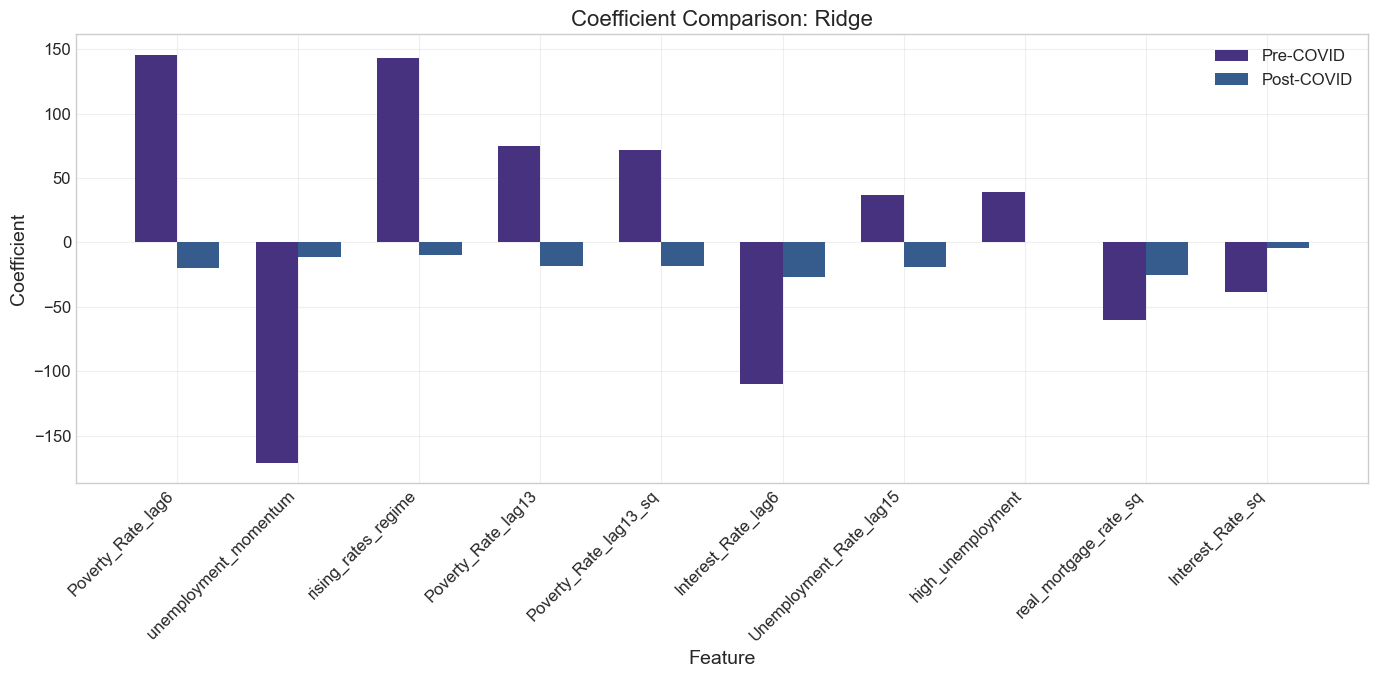


=== Pre-COVID Model Evaluation ===
Training RMSE: $116.88, R²: 0.998
Validation RMSE: $3689.77, R²: -1371.513
Test RMSE: $5117.41, R²: -60.069

=== Post-COVID Model Evaluation ===
Training RMSE: $5.76, R²: 1.000
Validation RMSE: $4788.05, R²: -11.177
Test RMSE: $5790.56, R²: -0.734

=== Regime Comparison: XGBRegressor ===
Pre-COVID Test R²: -60.069, RMSE: $5117.41
Post-COVID Test R²: -0.734, RMSE: $5790.56

Feature Importance Comparison (Top 10 by difference):
                             Feature  Pre-COVID Importance  Post-COVID Importance  Abs Difference
2                 Interest_Rate_lag6                  0.07                   0.84            0.77
7                  Poverty_Rate_lag6                  0.31                   0.00            0.31
10           Unemployment_Rate_lag15                  0.18                   0.02            0.16
9         Unemployment_Rate_lag10_sq                  0.09                   0.00            0.09
21             unemployment_momentum        

<Figure size 1200x800 with 0 Axes>

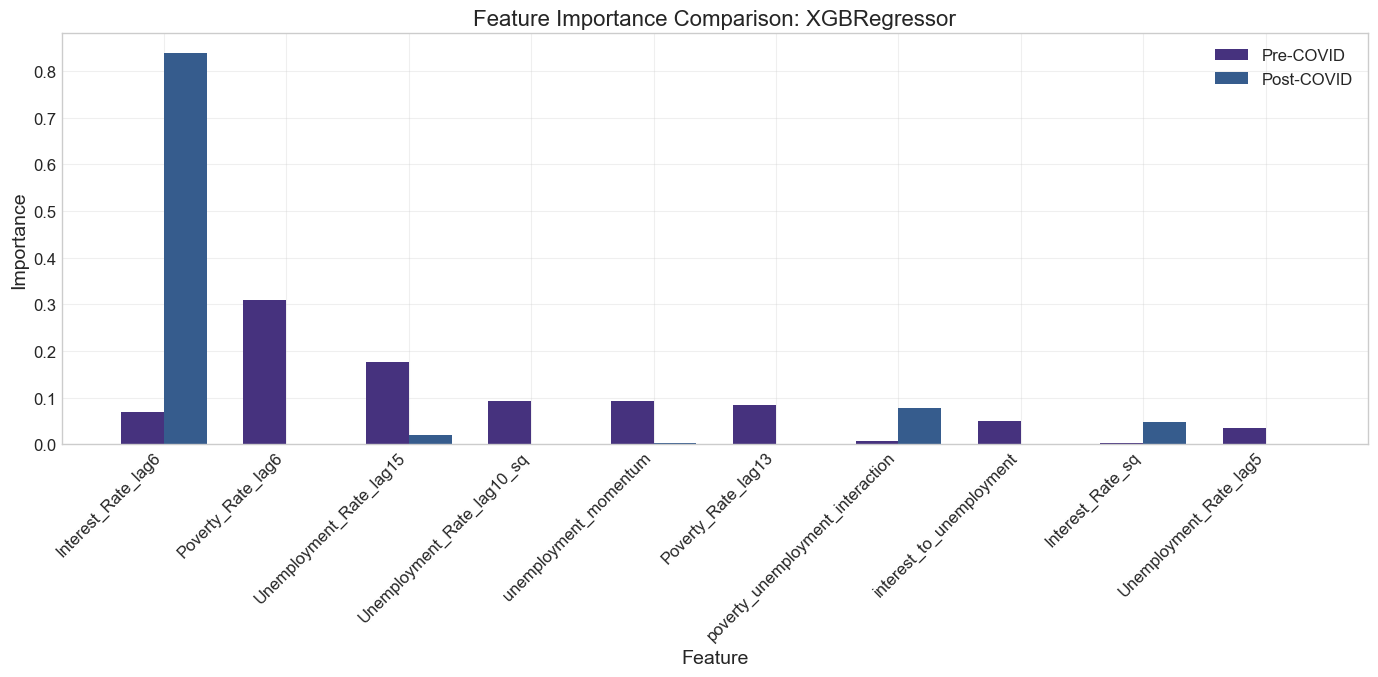


Consolidated Regime Comparison:
               Model  Pre-COVID R²  Post-COVID R²  Pre-COVID RMSE  Post-COVID RMSE  R² Difference
2            XGBoost        -60.07          -0.73         5117.41          5790.56          59.34
1   Ridge Regression         -4.53          -0.12         1540.20          4660.48           4.41
0  Linear Regression        -19.73         -17.45         2981.86         18885.96           2.29


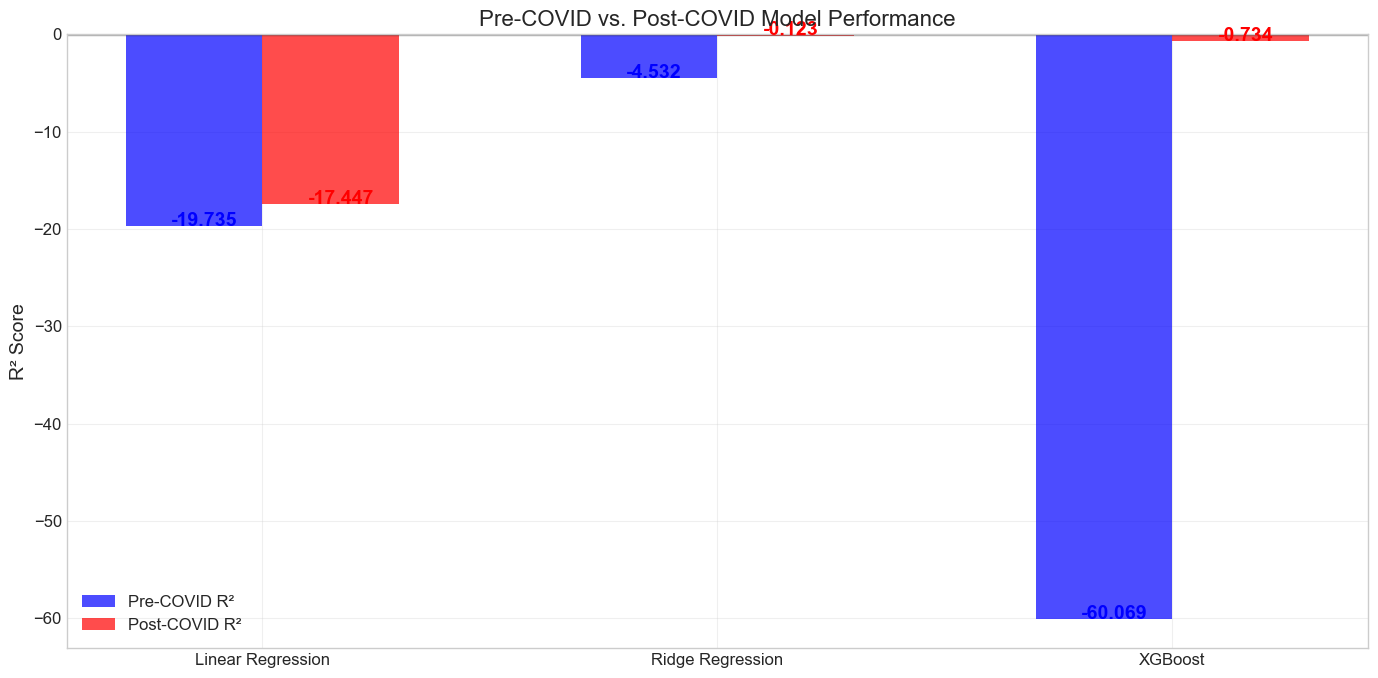


== Multi-Horizon Forecasting ==
1-Month Horizon: Test RMSE = $4466.70, R² = -0.470
3-Month Horizon: Test RMSE = $13296.36, R² = -0.705
6-Month Horizon: Test RMSE = $33088.43, R² = -4.360
12-Month Horizon: Test RMSE = $53944.73, R² = -26.997
24-Month Horizon: Test RMSE = $118077.13, R² = -86.433


<Figure size 1200x800 with 0 Axes>

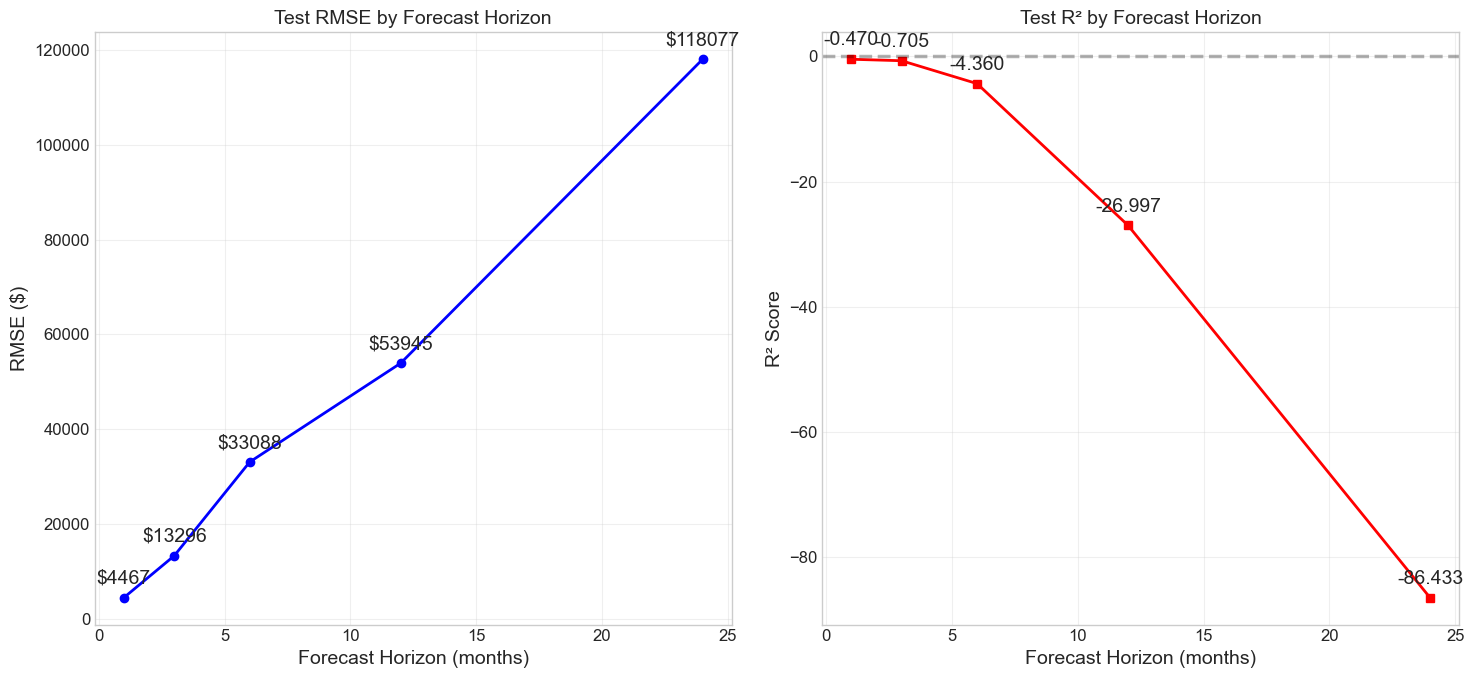


Best performing horizon: 1 months (R² = -0.470)
Worst performing horizon: 24 months (R² = -86.433)


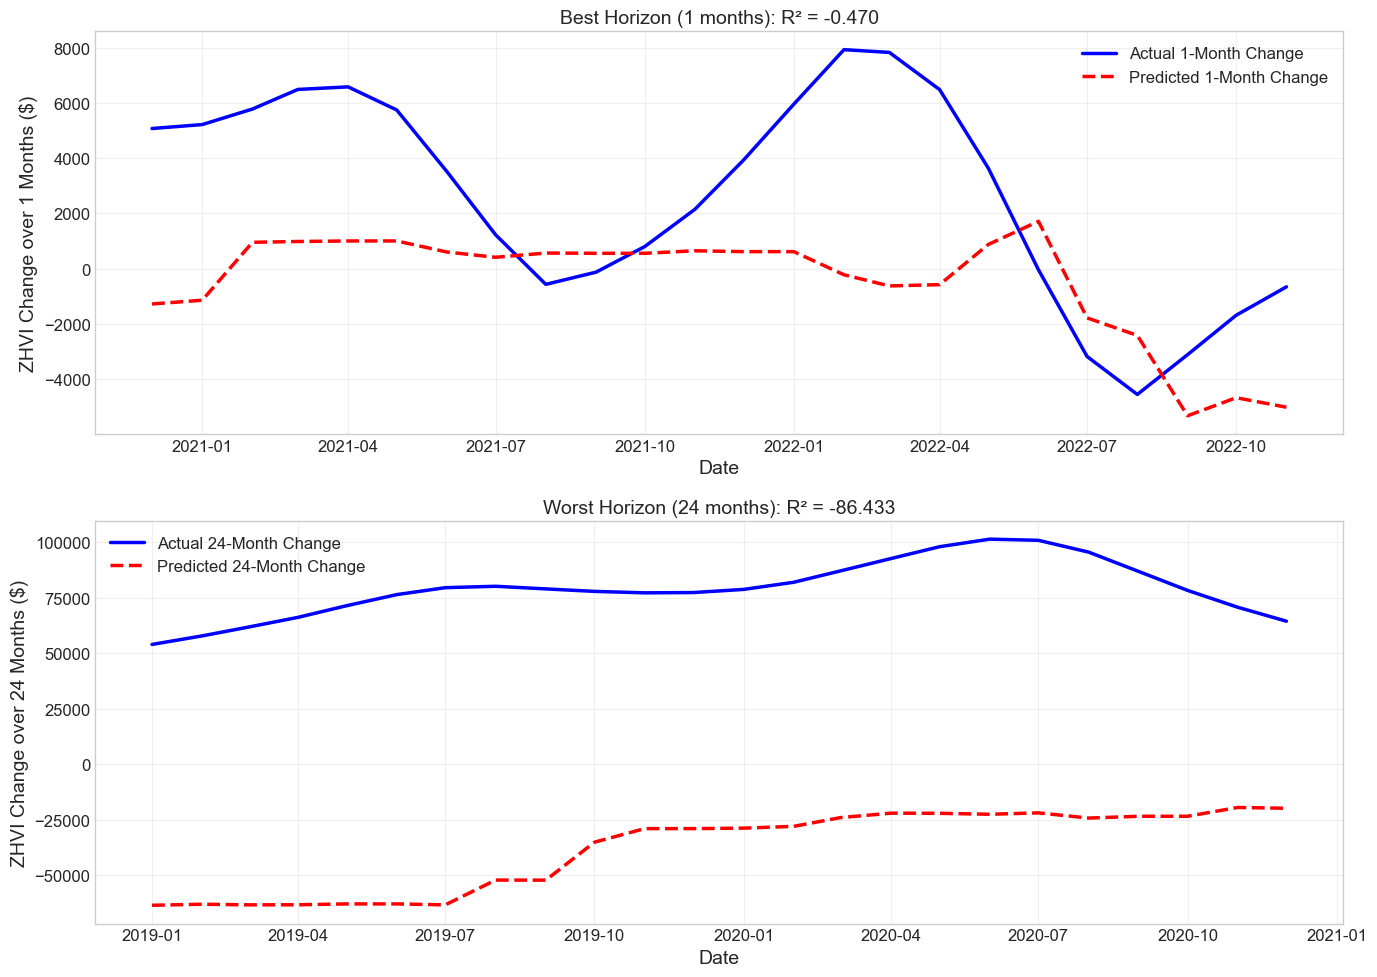


== Future Forecasting and Scenario Analysis ==


NameError: name 'current_data' is not defined

In [15]:
# DC Housing Market Forecasting: Enhanced Predictive Modeling

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pickle
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Statistical and modeling libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.feature_selection import RFE, SelectFromModel, RFECV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
import xgboost as xgb
import lightgbm as lgb

# Set visualization styling for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create directory for saving outputs
output_dir = 'outputs/models_and_forecasts_final'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory set to: {output_dir}")

#################################################################
## 1. Introduction and Data Loading
#################################################################

# Load the feature-engineered dataset from EDA
df = pd.read_csv('dc_housing_modeling_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Display basic information
print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Time period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Duration: {((df.index.max() - df.index.min()).days / 365.25):.1f} years")

# Load the original dataset to get all variables
df_full = pd.read_csv('dc_economic_monthly_dataframe.csv')
df_full['Date'] = pd.to_datetime(df_full['Date'])
df_full = df_full.set_index('Date')

# Ensure alignment between datasets
df_full = df_full.loc[df.index]

# Display the first few rows
print("\nPreview of modeling features:")
display(df.head())

#################################################################
## 2. Enhanced Feature Engineering
#################################################################

def create_enhanced_dataset(df, df_full):
    """
    Create an enhanced dataset with additional engineered features and transformations
    """
    # Start with the selected features
    enhanced_df = df.copy()
    
    # Add original target
    enhanced_df['ZHVI'] = df_full['ZHVI']
    
    # Add percentage changes at different horizons
    enhanced_df['ZHVI_pct_1m'] = df_full['ZHVI'].pct_change() * 100
    enhanced_df['ZHVI_pct_3m'] = df_full['ZHVI'].pct_change(periods=3) * 100
    enhanced_df['ZHVI_pct_6m'] = df_full['ZHVI'].pct_change(periods=6) * 100
    enhanced_df['ZHVI_pct_12m'] = df_full['ZHVI'].pct_change(periods=12) * 100
    
    # Add log-transformed target (better for multiplicative processes)
    enhanced_df['ZHVI_log'] = np.log(df_full['ZHVI'])
    enhanced_df['ZHVI_log_diff'] = enhanced_df['ZHVI_log'].diff()
    
    # Add binary direction feature (1 = up, 0 = down/flat)
    enhanced_df['ZHVI_direction'] = (df_full['ZHVI'].diff() > 0).astype(int)
    
    # Add economic regime indicators from full dataset
    enhanced_df['interest_rate_diff'] = df_full['Interest_Rate'].diff(periods=3)
    enhanced_df['rising_rates_regime'] = (enhanced_df['interest_rate_diff'] > 0).astype(int)
    enhanced_df['high_unemployment'] = (df_full['Unemployment_Rate'] > 7).astype(int)
    
    # Create specific period indicators based on trend analysis
    enhanced_df['pre_gfc'] = (enhanced_df.index < pd.to_datetime('2007-12-01')).astype(int)
    enhanced_df['post_gfc_pre_covid'] = ((enhanced_df.index >= pd.to_datetime('2009-06-01')) & 
                                        (enhanced_df.index < pd.to_datetime('2020-02-01'))).astype(int)
    enhanced_df['covid_period'] = ((enhanced_df.index >= pd.to_datetime('2020-02-01')) & 
                                  (enhanced_df.index < pd.to_datetime('2022-01-01'))).astype(int)
    enhanced_df['post_covid'] = (enhanced_df.index >= pd.to_datetime('2022-01-01')).astype(int)
    
    # Add interaction terms between important features
    enhanced_df['mort_poverty_interaction'] = enhanced_df['real_mortgage_rate'] * enhanced_df['Poverty_Rate_lag13']
    enhanced_df['mort_unemployment_interaction'] = enhanced_df['real_mortgage_rate'] * enhanced_df['Unemployment_Rate_lag10']
    enhanced_df['poverty_unemployment_interaction'] = enhanced_df['Poverty_Rate_lag13'] * enhanced_df['Unemployment_Rate_lag10']
    
    # Add squared terms for key variables (polynomial features)
    enhanced_df['real_mortgage_rate_sq'] = enhanced_df['real_mortgage_rate'] ** 2
    enhanced_df['Interest_Rate_sq'] = enhanced_df['Interest_Rate'] ** 2
    enhanced_df['Poverty_Rate_lag13_sq'] = enhanced_df['Poverty_Rate_lag13'] ** 2
    enhanced_df['Unemployment_Rate_lag10_sq'] = enhanced_df['Unemployment_Rate_lag10'] ** 2
    
    # Add ratio features
    enhanced_df['interest_to_unemployment'] = enhanced_df['Interest_Rate'] / enhanced_df['Unemployment_Rate_lag10']
    enhanced_df['mortgage_to_poverty'] = enhanced_df['real_mortgage_rate'] / enhanced_df['Poverty_Rate_lag13']
    
    # Additional lag combinations for key variables
    enhanced_df['Interest_Rate_lag3'] = df_full['Interest_Rate'].shift(3)
    enhanced_df['Interest_Rate_lag6'] = df_full['Interest_Rate'].shift(6)
    enhanced_df['Unemployment_Rate_lag5'] = df_full['Unemployment_Rate'].shift(5)
    enhanced_df['Unemployment_Rate_lag15'] = df_full['Unemployment_Rate'].shift(15)
    enhanced_df['Poverty_Rate_lag6'] = df_full['Poverty_Rate'].shift(6)
    enhanced_df['Poverty_Rate_lag18'] = df_full['Poverty_Rate'].shift(18)
    
    # Economic momentum features
    enhanced_df['interest_rate_momentum'] = df_full['Interest_Rate'].diff(3) / 3
    enhanced_df['unemployment_momentum'] = df_full['Unemployment_Rate'].diff(3) / 3
    enhanced_df['poverty_momentum'] = df_full['Poverty_Rate'].diff(3) / 3
    
    # Normalized ZHVI by income
    enhanced_df['ZHVI_to_income'] = df_full['ZHVI'] / df_full['Median_Household_Income']
    enhanced_df['ZHVI_to_income_change'] = enhanced_df['ZHVI_to_income'].diff()
    
    # Drop rows with NaN values
    enhanced_df = enhanced_df.dropna()
    
    return enhanced_df

# Create the enhanced dataset
enhanced_df = create_enhanced_dataset(df, df_full)

print(f"\nEnhanced dataset shape: {enhanced_df.shape[0]} rows × {enhanced_df.shape[1]} columns")
print("Added features:", set(enhanced_df.columns) - set(df.columns))

# Create regime-specific datasets based on EDA findings
def split_by_regimes(df):
    """
    Split data into pre-COVID and post-COVID regimes
    """
    covid_start = pd.to_datetime('2020-02-01')
    pre_covid = df[df.index < covid_start].copy()
    post_covid = df[df.index >= covid_start].copy()
    
    return pre_covid, post_covid

# Split dataset by regimes
pre_covid_df, post_covid_df = split_by_regimes(enhanced_df)

print(f"\nPre-COVID data: {pre_covid_df.shape[0]} samples")
print(f"Post-COVID data: {post_covid_df.shape[0]} samples")

# Visualize the distribution of target variables
plt.figure(figsize=(16, 10))

# Set up subplots
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 2, 3)
ax4 = plt.subplot(2, 2, 4)

# Plot distributions
sns.histplot(enhanced_df['ZHVI_diff1'], kde=True, ax=ax1)
ax1.set_title('Distribution of Absolute Changes (ZHVI_diff1)')
ax1.axvline(enhanced_df['ZHVI_diff1'].mean(), color='red', linestyle='--', label='Mean')
ax1.axvline(enhanced_df['ZHVI_diff1'].median(), color='green', linestyle='--', label='Median')
ax1.legend()

sns.histplot(enhanced_df['ZHVI_pct_1m'], kde=True, ax=ax2)
ax2.set_title('Distribution of Percentage Changes (ZHVI_pct_1m)')
ax2.axvline(enhanced_df['ZHVI_pct_1m'].mean(), color='red', linestyle='--', label='Mean')
ax2.axvline(enhanced_df['ZHVI_pct_1m'].median(), color='green', linestyle='--', label='Median')
ax2.legend()

sns.histplot(enhanced_df['ZHVI_log_diff'], kde=True, ax=ax3)
ax3.set_title('Distribution of Log Differences (ZHVI_log_diff)')
ax3.axvline(enhanced_df['ZHVI_log_diff'].mean(), color='red', linestyle='--', label='Mean')
ax3.axvline(enhanced_df['ZHVI_log_diff'].median(), color='green', linestyle='--', label='Median')
ax3.legend()

# Plot target variable over time
ax4.plot(enhanced_df.index, enhanced_df['ZHVI_diff1'])
ax4.set_title('ZHVI Monthly Changes Over Time')
ax4.axhline(y=0, color='red', linestyle='--')
ax4.set_xlabel('Date')
ax4.set_ylabel('ZHVI Change ($)')

plt.tight_layout()
plt.savefig(f'{output_dir}/target_variable_exploration.png')
plt.show()

#################################################################
## 3. Feature Selection Methods
#################################################################

# Define the base feature set from EDA
base_features = [
    'Interest_Rate', 
    'real_mortgage_rate', 
    'Poverty_Rate_lag13', 
    'Unemployment_Rate_lag10'
]

# Add the enhanced features for selection
enhanced_features = base_features + [
    'mort_poverty_interaction',
    'mort_unemployment_interaction',
    'poverty_unemployment_interaction',
    'real_mortgage_rate_sq',
    'Interest_Rate_sq',
    'Poverty_Rate_lag13_sq',
    'Unemployment_Rate_lag10_sq',
    'interest_to_unemployment',
    'mortgage_to_poverty',
    'Interest_Rate_lag3',
    'Interest_Rate_lag6',
    'Unemployment_Rate_lag5',
    'Unemployment_Rate_lag15',
    'Poverty_Rate_lag6',
    'Poverty_Rate_lag18',
    'interest_rate_momentum',
    'unemployment_momentum',
    'poverty_momentum',
    'rising_rates_regime',
    'high_unemployment'
]

# 3.1 LASSO-based feature selection
def lasso_feature_selection(X, y, alpha_range=None, cv=5):
    """
    Use LASSO for automatic feature selection
    """
    if alpha_range is None:
        alpha_range = np.logspace(-4, 1, 30)
    
    lasso_cv = LassoCV(alphas=alpha_range, cv=cv, max_iter=10000, random_state=42)
    lasso_cv.fit(X, y)
    
    # Get optimal alpha
    optimal_alpha = lasso_cv.alpha_
    print(f"Optimal alpha: {optimal_alpha:.6f}")
    
    # Create model with optimal alpha
    lasso = Lasso(alpha=optimal_alpha, max_iter=10000, random_state=42)
    lasso.fit(X, y)
    
    # Create DataFrame with feature coefficients
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': lasso.coef_
    })
    
    # Get non-zero coefficients (selected features)
    selected_features = feature_importance[feature_importance['Coefficient'] != 0]
    selected_features = selected_features.sort_values('Coefficient', key=abs, ascending=False)
    
    print(f"LASSO selected {len(selected_features)} features")
    
    return selected_features, lasso

# 3.2 Recursive Feature Elimination
def rfe_feature_selection(X, y, n_features_to_select=None, step=1):
    """
    Use RFE for feature selection
    """
    # If n_features_to_select is not specified, select half of the features
    if n_features_to_select is None:
        n_features_to_select = X.shape[1] // 2
    
    # Initialize the model
    model = Ridge(alpha=1.0)
    
    # Initialize RFE
    rfe = RFE(estimator=model, n_features_to_select=n_features_to_select, step=step)
    rfe.fit(X, y)
    
    # Create DataFrame with feature rankings
    feature_rankings = pd.DataFrame({
        'Feature': X.columns,
        'Selected': rfe.support_,
        'Rank': rfe.ranking_
    })
    
    # Get selected features
    selected_features = feature_rankings[feature_rankings['Selected']]
    selected_features = selected_features.sort_values('Rank')
    
    print(f"RFE selected {len(selected_features)} features")
    
    return selected_features, rfe

print("\n== Feature Selection Methods ==")

# 3.3 Apply feature selection methods
# Prepare data for feature selection
X_fs = enhanced_df[enhanced_features]
y_fs = enhanced_df['ZHVI_diff1']

# Run LASSO feature selection
print("\nLASSO Feature Selection:")
lasso_selected, lasso_model = lasso_feature_selection(X_fs, y_fs)
print("\nLASSO Selected Features:")
print(lasso_selected)

# Run RFE feature selection
print("\nRecursive Feature Elimination:")
rfe_selected, rfe_model = rfe_feature_selection(X_fs, y_fs, n_features_to_select=10)
print("\nRFE Selected Features:")
print(rfe_selected)

# Create combined feature set from both methods
lasso_features = list(lasso_selected['Feature'])
rfe_features = list(rfe_selected[rfe_selected['Selected']]['Feature'])

# Combine unique features from both methods
combined_features = list(set(lasso_features + rfe_features + base_features))
print(f"\nCombined feature set ({len(combined_features)} features): {combined_features}")

#################################################################
## 4. Data Preparation with Train/Validation/Test Split
#################################################################

def prepare_model_data(df, target_col, feature_cols, test_size=24, val_size=12, scale_features=True):
    """
    Prepare data for modeling with train/validation/test split and optional scaling
    """
    # Prepare X and y
    X = df[feature_cols]
    y = df[target_col]
    
    # Calculate total length
    total_length = len(df)
    train_end = total_length - (test_size + val_size)
    val_end = total_length - test_size
    
    # Split into train, validation, and test sets
    X_train = X.iloc[:train_end]
    X_val = X.iloc[train_end:val_end]
    X_test = X.iloc[val_end:]
    
    y_train = y.iloc[:train_end]
    y_val = y.iloc[train_end:val_end]
    y_test = y.iloc[val_end:]
    
    # Scale features if required
    if scale_features:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test)
        
        X_train = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
        X_val = pd.DataFrame(X_val_scaled, index=X_val.index, columns=X_val.columns)
        X_test = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Create datasets for different targets
print("\n== Data Preparation ==")

# 1. Absolute price changes (original target)
X_train, X_val, X_test, y_train, y_val, y_test = prepare_model_data(
    enhanced_df, 'ZHVI_diff1', combined_features, test_size=24, val_size=12
)

print(f"Train set: {len(X_train)} samples ({X_train.index.min()} to {X_train.index.max()})")
print(f"Validation set: {len(X_val)} samples ({X_val.index.min()} to {X_val.index.max()})")
print(f"Test set: {len(X_test)} samples ({X_test.index.min()} to {X_test.index.max()})")

# 2. Percentage changes
X_train_pct, X_val_pct, X_test_pct, y_train_pct, y_val_pct, y_test_pct = prepare_model_data(
    enhanced_df, 'ZHVI_pct_1m', combined_features, test_size=24, val_size=12
)

# 3. Log differences
X_train_log, X_val_log, X_test_log, y_train_log, y_val_log, y_test_log = prepare_model_data(
    enhanced_df, 'ZHVI_log_diff', combined_features, test_size=24, val_size=12
)

# Prepare regime-specific datasets
X_train_pre, X_val_pre, X_test_pre, y_train_pre, y_val_pre, y_test_pre = prepare_model_data(
    pre_covid_df, 'ZHVI_diff1', combined_features, test_size=12, val_size=6
)

X_train_post, X_val_post, X_test_post, y_train_post, y_val_post, y_test_post = prepare_model_data(
    post_covid_df, 'ZHVI_diff1', combined_features, test_size=12, val_size=6
)

#################################################################
## 5. Enhanced Model Evaluation Function
#################################################################

def evaluate_model(model, X_train, X_val, X_test, y_train, y_val, y_test, model_name, plot=True, return_model=False):
    """
    Evaluate a model on train, validation, and test sets with multiple metrics
    """
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'val_mae': mean_absolute_error(y_val, y_val_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'val_r2': r2_score(y_val, y_val_pred),
        'test_r2': r2_score(y_test, y_test_pred)
    }
    
    # Try to calculate MAPE only if no zeros in the actual values
    try:
        metrics['train_mape'] = mean_absolute_percentage_error(y_train, y_train_pred)
        metrics['val_mape'] = mean_absolute_percentage_error(y_val, y_val_pred)
        metrics['test_mape'] = mean_absolute_percentage_error(y_test, y_test_pred)
    except:
        # Skip MAPE if division by zero issues
        metrics['train_mape'] = np.nan
        metrics['val_mape'] = np.nan
        metrics['test_mape'] = np.nan
    
    # Print metrics
    print(f"\n=== {model_name} Evaluation ===")
    print(f"Training RMSE: ${metrics['train_rmse']:.2f}, R²: {metrics['train_r2']:.3f}")
    print(f"Validation RMSE: ${metrics['val_rmse']:.2f}, R²: {metrics['val_r2']:.3f}")
    print(f"Test RMSE: ${metrics['test_rmse']:.2f}, R²: {metrics['test_r2']:.3f}")
    
    # Plot actual vs predicted
    if plot:
        plt.figure(figsize=(14, 7))
        
        # Training period
        plt.plot(y_train.index, y_train, color='blue', alpha=0.5, label='Actual (Train)')
        plt.plot(y_train.index, y_train_pred, color='green', alpha=0.5, label='Predicted (Train)', linestyle='--')
        
        # Validation period
        plt.plot(y_val.index, y_val, color='purple', alpha=0.7, label='Actual (Validation)')
        plt.plot(y_val.index, y_val_pred, color='orange', alpha=0.7, label='Predicted (Validation)', linestyle='--')
        
        # Test period
        plt.plot(y_test.index, y_test, color='navy', label='Actual (Test)')
        plt.plot(y_test.index, y_test_pred, color='red', label='Predicted (Test)', linestyle='--')
        
        # Add vertical lines separating train, validation, and test
        plt.axvline(x=y_train.index[-1], color='black', linestyle=':', label='Train/Val Split')
        plt.axvline(x=y_val.index[-1], color='black', linestyle='--', label='Val/Test Split')
        
        # Add title and labels
        plt.title(f'{model_name} - Actual vs Predicted\nTest R² = {metrics["test_r2"]:.3f}, RMSE = ${metrics["test_rmse"]:.2f}', fontsize=16)
        plt.xlabel('Date')
        plt.ylabel('ZHVI Change ($)')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        
        # Save and show plot
        plt.tight_layout()
        plt.savefig(f'{output_dir}/{model_name.replace(" ", "_").lower()}_predictions.png')
        plt.show()
        
        # Plot error analysis
        plt.figure(figsize=(14, 10))
        
        # Create a 2x2 grid
        ax1 = plt.subplot(2, 2, 1)
        ax2 = plt.subplot(2, 2, 2)
        ax3 = plt.subplot(2, 2, 3)
        ax4 = plt.subplot(2, 2, 4)
        
        # Error over time
        test_errors = y_test - y_test_pred
        ax1.plot(y_test.index, test_errors)
        ax1.set_title('Prediction Errors Over Time')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Error ($)')
        ax1.axhline(y=0, color='red', linestyle='--')
        ax1.grid(True, alpha=0.3)
        
        # Error distribution
        sns.histplot(test_errors, kde=True, ax=ax2)
        ax2.set_title('Error Distribution')
        ax2.set_xlabel('Error ($)')
        ax2.axvline(x=0, color='red', linestyle='--')
        ax2.grid(True, alpha=0.3)
        
        # Actual vs Predicted scatter
        ax3.scatter(y_test, y_test_pred)
        ax3.set_title('Actual vs Predicted')
        ax3.set_xlabel('Actual Value')
        ax3.set_ylabel('Predicted Value')
        
        # Add 45-degree line
        lims = [
            min(ax3.get_xlim()[0], ax3.get_ylim()[0]),
            max(ax3.get_xlim()[1], ax3.get_ylim()[1])
        ]
        ax3.plot(lims, lims, 'r--')
        ax3.grid(True, alpha=0.3)
        
        # Residual plot
        ax4.scatter(y_test_pred, test_errors)
        ax4.set_title('Residuals vs Predicted')
        ax4.set_xlabel('Predicted Value')
        ax4.set_ylabel('Residual')
        ax4.axhline(y=0, color='red', linestyle='--')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/{model_name.replace(" ", "_").lower()}_error_analysis.png')
        plt.show()
    
    if return_model:
        return metrics, y_test_pred, model
    else:
        return metrics, y_test_pred

# Time-weighted evaluation function
def time_weighted_metrics(y_true, y_pred, half_life=12):
    """
    Calculate time-weighted evaluation metrics that give more importance to recent observations
    """
    n = len(y_true)
    
    # Create weights that decay exponentially going backwards in time
    weights = np.exp(np.log(0.5) * np.arange(n-1, -1, -1) / half_life)
    weights = weights / weights.sum()
    
    # Calculate weighted errors
    errors = y_true - y_pred
    abs_errors = np.abs(errors)
    squared_errors = errors ** 2
    
    # Weighted metrics
    wmae = np.sum(weights * abs_errors)
    wrmse = np.sqrt(np.sum(weights * squared_errors))
    
    # Calculate weighted R²
    weighted_mean = np.sum(weights * y_true)
    total_weighted_ss = np.sum(weights * ((y_true - weighted_mean) ** 2))
    residual_weighted_ss = np.sum(weights * squared_errors)
    wr2 = 1 - (residual_weighted_ss / total_weighted_ss)
    
    return {
        'weighted_mae': wmae,
        'weighted_rmse': wrmse,
        'weighted_r2': wr2
    }

#################################################################
## 6. Linear Models with Hyperparameter Tuning
#################################################################

print("\n== Linear Models with Hyperparameter Tuning ==")

# 6.1 Simple Linear Regression
linear_model = LinearRegression()
linear_metrics, linear_preds, linear_fitted = evaluate_model(
    linear_model, X_train, X_val, X_test, y_train, y_val, y_test, 
    "Linear Regression", plot=True, return_model=True
)

# 6.2 Ridge Regression with Grid Search
def tune_ridge(X_train, y_train, X_val, y_val, alphas=None):
    """
    Tune Ridge regression alpha parameter
    """
    if alphas is None:
        alphas = np.logspace(-3, 3, 20)
    
    val_rmses = []
    val_r2s = []
    
    for alpha in alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        val_r2 = r2_score(y_val, y_val_pred)
        
        val_rmses.append(val_rmse)
        val_r2s.append(val_r2)
    
    # Find best alpha based on validation RMSE
    best_idx = np.argmin(val_rmses)
    best_alpha = alphas[best_idx]
    best_rmse = val_rmses[best_idx]
    best_r2 = val_r2s[best_idx]
    
    print(f"Best Ridge alpha: {best_alpha:.4f} with validation RMSE = ${best_rmse:.2f}, R² = {best_r2:.3f}")
    
    # Create a plot of RMSE and R² vs alpha
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot RMSE
    color = 'tab:blue'
    ax1.set_xlabel('Alpha')
    ax1.set_ylabel('Validation RMSE ($)', color=color)
    ax1.plot(alphas, val_rmses, color=color, marker='o')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xscale('log')
    
    # Add second y-axis for R²
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Validation R²', color=color)
    ax2.plot(alphas, val_r2s, color=color, marker='s')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Highlight best alpha
    ax1.axvline(x=best_alpha, color='black', linestyle='--')
    
    plt.title('Ridge Regression Hyperparameter Tuning')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/ridge_hyperparameter_tuning.png')
    plt.show()
    
    # Return best model
    best_model = Ridge(alpha=best_alpha)
    best_model.fit(X_train, y_train)
    return best_model, best_alpha

# Tune Ridge regression
ridge_model, ridge_alpha = tune_ridge(X_train, y_train, X_val, y_val)
ridge_metrics, ridge_preds, ridge_fitted = evaluate_model(
    ridge_model, X_train, X_val, X_test, y_train, y_val, y_test, 
    "Ridge Regression (Tuned)", plot=True, return_model=True
)

# 6.3 Elastic Net with Grid Search
def tune_elastic_net(X_train, y_train, X_val, y_val, alphas=None, l1_ratios=None):
    """
    Tune ElasticNet alpha and l1_ratio parameters
    """
    if alphas is None:
        alphas = np.logspace(-3, 1, 10)
    if l1_ratios is None:
        l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
    
    best_rmse = float('inf')
    best_r2 = -float('inf')
    best_alpha = None
    best_l1_ratio = None
    
    results = []
    
    for alpha in alphas:
        for l1_ratio in l1_ratios:
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=42)
            model.fit(X_train, y_train)
            y_val_pred = model.predict(X_val)
            val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
            val_r2 = r2_score(y_val, y_val_pred)
            
            results.append({
                'alpha': alpha,
                'l1_ratio': l1_ratio,
                'val_rmse': val_rmse,
                'val_r2': val_r2
            })
            
            if val_rmse < best_rmse:
                best_rmse = val_rmse
                best_r2 = val_r2
                best_alpha = alpha
                best_l1_ratio = l1_ratio
    
    print(f"Best ElasticNet parameters: alpha={best_alpha:.4f}, l1_ratio={best_l1_ratio:.1f}")
    print(f"Validation RMSE = ${best_rmse:.2f}, R² = {best_r2:.3f}")
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Create heatmap of RMSE
    plt.figure(figsize=(12, 8))
    rmse_pivot = results_df.pivot_table(index='alpha', columns='l1_ratio', values='val_rmse')
    sns.heatmap(rmse_pivot, annot=True, fmt='.1f', cmap='viridis_r')
    plt.title('ElasticNet Validation RMSE by Alpha and L1 Ratio')
    plt.xlabel('L1 Ratio')
    plt.ylabel('Alpha')
    plt.xscale('log')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/elastic_net_hyperparameter_tuning.png')
    plt.show()
    
    # Return best model
    best_model = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000, random_state=42)
    best_model.fit(X_train, y_train)
    return best_model, best_alpha, best_l1_ratio

# Tune ElasticNet
elastic_model, elastic_alpha, elastic_l1_ratio = tune_elastic_net(X_train, y_train, X_val, y_val)
elastic_metrics, elastic_preds, elastic_fitted = evaluate_model(
    elastic_model, X_train, X_val, X_test, y_train, y_val, y_test, 
    "ElasticNet (Tuned)", plot=True, return_model=True
)

# 6.4 Lasso Regression
lasso_model = Lasso(alpha=elastic_alpha * elastic_l1_ratio, max_iter=10000, random_state=42)
lasso_metrics, lasso_preds, lasso_fitted = evaluate_model(
    lasso_model, X_train, X_val, X_test, y_train, y_val, y_test, 
    "Lasso Regression", plot=True, return_model=True
)

# Compare coefficients between linear models
def compare_linear_model_coefficients(models, model_names, X):
    """
    Compare coefficients between different linear models
    """
    # Get feature names
    feature_names = X.columns
    
    # Create DataFrame to store coefficients
    coef_df = pd.DataFrame({'Feature': feature_names})
    
    # Add coefficients for each model
    for model, name in zip(models, model_names):
        coef_df[name] = model.coef_
    
    # Calculate mean absolute coefficient
    coef_df['Mean_Abs_Coef'] = coef_df.iloc[:, 1:].abs().mean(axis=1)
    
    # Sort by mean absolute coefficient
    coef_df = coef_df.sort_values('Mean_Abs_Coef', ascending=False)
    
    # Keep top 15 features for visualization
    top_features = coef_df.head(15)
    
    # Create a plot
    plt.figure(figsize=(14, 10))
    
    # Set width of bars
    n_models = len(models)
    bar_width = 0.8 / n_models
    
    # Set position of bars on x axis
    positions = np.arange(len(top_features))
    
    # Create bars
    for i, name in enumerate(model_names):
        offset = i - n_models/2 + 0.5
        plt.barh(positions + offset * bar_width, top_features[name], 
                bar_width, alpha=0.7, label=name)
    
    # Add labels and title
    plt.yticks(positions, top_features['Feature'])
    plt.xlabel('Coefficient Value')
    plt.title('Feature Coefficients Comparison Across Linear Models', fontsize=16)
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/linear_model_coefficient_comparison.png')
    plt.show()
    
    return coef_df

# Compare coefficients
linear_models = [linear_fitted, ridge_fitted, elastic_fitted, lasso_fitted]
model_names = ['Linear Regression', 'Ridge', 'ElasticNet', 'Lasso']
coef_comparison = compare_linear_model_coefficients(linear_models, model_names, X_train)

print("\nTop 10 features by mean absolute coefficient:")
print(coef_comparison[['Feature', 'Mean_Abs_Coef']].head(10))

#################################################################
## 7. Tree-Based Models with Hyperparameter Tuning
#################################################################

print("\n== Tree-Based Models with Hyperparameter Tuning ==")

# 7.1 Random Forest with Grid Search
def tune_random_forest(X_train, y_train, X_val, y_val):
    """
    Tune Random Forest hyperparameters
    """
    # Define parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    # Create base model
    rf = RandomForestRegressor(random_state=42)
    
    # Create time series cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    
    # Grid search
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        verbose=1,
        n_jobs=-1
    )
    
    # Fit grid search to the data
    grid_search.fit(X_train, y_train)
    
    # Print best parameters
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV RMSE: ${-grid_search.best_score_:.2f}")
    
    # Evaluate best model on validation set
    best_model = grid_search.best_estimator_
    y_val_pred = best_model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2 = r2_score(y_val, y_val_pred)
    
    print(f"Validation RMSE: ${val_rmse:.2f}, R²: {val_r2:.3f}")
    
    # Analyze feature importance
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
    plt.title('Random Forest Feature Importance', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/random_forest_feature_importance.png')
    plt.show()
    
    return best_model, feature_importance

# Run Random Forest tuning
print("\nTuning Random Forest hyperparameters:")
rf_model, rf_feature_importance = tune_random_forest(X_train, y_train, X_val, y_val)
rf_metrics, rf_preds, rf_fitted = evaluate_model(
    rf_model, X_train, X_val, X_test, y_train, y_val, y_test, 
    "Random Forest (Tuned)", plot=True, return_model=True
)

print("\nTop 10 features by Random Forest importance:")
print(rf_feature_importance.head(10))

# 7.2 XGBoost with Grid Search
def tune_xgboost(X_train, y_train, X_val, y_val):
    """
    Tune XGBoost hyperparameters
    """
    # Define parameter grid
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
    
    # Create base model
    xgb_model = xgb.XGBRegressor(random_state=42)
    
    # Create time series cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    
    # Grid search
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        verbose=1,
        n_jobs=-1
    )
    
    # Fit grid search to the data
    grid_search.fit(X_train, y_train)
    
    # Print best parameters
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV RMSE: ${-grid_search.best_score_:.2f}")
    
    # Evaluate best model on validation set
    best_model = grid_search.best_estimator_
    y_val_pred = best_model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2 = r2_score(y_val, y_val_pred)
    
    print(f"Validation RMSE: ${val_rmse:.2f}, R²: {val_r2:.3f}")
    
    # Analyze feature importance
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
    plt.title('XGBoost Feature Importance', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/xgboost_feature_importance.png')
    plt.show()
    
    return best_model, feature_importance

# Run XGBoost tuning
print("\nTuning XGBoost hyperparameters:")
xgb_model, xgb_feature_importance = tune_xgboost(X_train, y_train, X_val, y_val)
xgb_metrics, xgb_preds, xgb_fitted = evaluate_model(
    xgb_model, X_train, X_val, X_test, y_train, y_val, y_test, 
    "XGBoost (Tuned)", plot=True, return_model=True
)

print("\nTop 10 features by XGBoost importance:")
print(xgb_feature_importance.head(10))

# 7.3 Compare feature importance between tree models
plt.figure(figsize=(15, 10))

# Get top 15 features from both models
rf_top = rf_feature_importance.head(15)
xgb_top = xgb_feature_importance.head(15)

# Combine unique features
combined_features = pd.Series(list(set(rf_top['Feature'].tolist() + xgb_top['Feature'].tolist())))

# Create a new DataFrame with all features
combined_importance = pd.DataFrame({'Feature': combined_features})

# Add importance from both models (fill with 0 if not in top 15)
for feature in combined_importance['Feature']:
    if feature in rf_top['Feature'].values:
        combined_importance.loc[combined_importance['Feature'] == feature, 'RF_Importance'] = \
            rf_top.loc[rf_top['Feature'] == feature, 'Importance'].values[0]
    else:
        combined_importance.loc[combined_importance['Feature'] == feature, 'RF_Importance'] = 0
        
    if feature in xgb_top['Feature'].values:
        combined_importance.loc[combined_importance['Feature'] == feature, 'XGB_Importance'] = \
            xgb_top.loc[xgb_top['Feature'] == feature, 'Importance'].values[0]
    else:
        combined_importance.loc[combined_importance['Feature'] == feature, 'XGB_Importance'] = 0

# Calculate average importance
combined_importance['Avg_Importance'] = (combined_importance['RF_Importance'] + 
                                        combined_importance['XGB_Importance']) / 2

# Sort by average importance
combined_importance = combined_importance.sort_values('Avg_Importance', ascending=False)

# Set width of bars
width = 0.35
x = np.arange(len(combined_importance))

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot RF importance
ax1.barh(combined_importance['Feature'], combined_importance['RF_Importance'], color='blue', alpha=0.7)
ax1.set_title('Random Forest Feature Importance', fontsize=14)
ax1.set_xlabel('Importance Score')
ax1.grid(axis='x', alpha=0.3)

# Plot XGB importance
ax2.barh(combined_importance['Feature'], combined_importance['XGB_Importance'], color='green', alpha=0.7)
ax2.set_title('XGBoost Feature Importance', fontsize=14)
ax2.set_xlabel('Importance Score')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/tree_models_feature_importance_comparison.png')
plt.show()

#################################################################
## 8. Time Series Models
#################################################################

print("\n== Time Series Models ==")

# 8.1 ARIMA model
def fit_arima_model(train_series, val_series, test_series, orders=None):
    """
    Fit ARIMA model with optimal order
    """
    if orders is None:
        orders = [
            (1,1,1), (1,1,2), (2,1,1), (2,1,2),
            (1,1,0), (0,1,1), (3,1,0), (0,1,3)
        ]
    
    best_aic = float('inf')
    best_order = None
    best_model = None
    
    for order in orders:
        try:
            # Fit model
            arima_model = ARIMA(train_series, order=order)
            arima_fit = arima_model.fit()
            
            # Check AIC
            if arima_fit.aic < best_aic:
                best_aic = arima_fit.aic
                best_order = order
                best_model = arima_fit
        except:
            print(f"Error fitting ARIMA{order}")
            continue
    
    print(f"Best ARIMA order: {best_order} with AIC = {best_aic:.2f}")
    
    # Evaluate on validation set
    val_forecasts = best_model.forecast(steps=len(val_series))
    val_rmse = np.sqrt(mean_squared_error(val_series, val_forecasts))
    val_r2 = r2_score(val_series, val_forecasts)
    
    print(f"Validation RMSE: ${val_rmse:.2f}, R²: {val_r2:.3f}")
    
    # Refit with both train and validation data
    combined_train = pd.concat([train_series, val_series])
    arima_model_final = ARIMA(combined_train, order=best_order)
    arima_fit_final = arima_model_final.fit()
    
    # Forecast test set
    test_forecasts = arima_fit_final.forecast(steps=len(test_series))
    test_rmse = np.sqrt(mean_squared_error(test_series, test_forecasts))
    test_r2 = r2_score(test_series, test_forecasts)
    
    print(f"Test RMSE: ${test_rmse:.2f}, R²: {test_r2:.3f}")
    
    # Plot results
    plt.figure(figsize=(14, 7))
    
    # Plot training data
    plt.plot(train_series.index, train_series, label='Training Data', color='blue', alpha=0.7)
    
    # Plot validation data and forecasts
    plt.plot(val_series.index, val_series, label='Validation Data', color='purple')
    plt.plot(val_series.index, val_forecasts, label='Validation Forecast', color='orange', linestyle='--')
    
    # Plot test data and forecasts
    plt.plot(test_series.index, test_series, label='Test Data', color='navy')
    plt.plot(test_series.index, test_forecasts, label='Test Forecast', color='red', linestyle='--')
    
    # Add vertical lines
    plt.axvline(x=train_series.index[-1], color='black', linestyle=':', label='Train/Val Split')
    plt.axvline(x=val_series.index[-1], color='black', linestyle='--', label='Val/Test Split')
    
    # Add title and labels
    plt.title(f'ARIMA{best_order} Forecast\nTest R² = {test_r2:.3f}, RMSE = ${test_rmse:.2f}', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('ZHVI Change ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/arima_forecast.png')
    plt.show()
    
    return {
        'val_rmse': val_rmse,
        'val_r2': val_r2,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    }, test_forecasts, arima_fit_final, best_order

# Prepare data for ARIMA
zhvi_diff = enhanced_df['ZHVI_diff1']
train_series = zhvi_diff.iloc[:-36]
val_series = zhvi_diff.iloc[-36:-24]
test_series = zhvi_diff.iloc[-24:]

# Fit ARIMA model
print("\nFitting ARIMA model:")
arima_metrics, arima_preds, arima_fitted, arima_order = fit_arima_model(train_series, val_series, test_series)

# 8.2 SARIMAX model (with exogenous variables)
def fit_sarimax_model(train_y, val_y, test_y, train_X, val_X, test_X, orders=None, seasonal_orders=None):
    """
    Fit SARIMAX model with exogenous variables
    """
    if orders is None:
        orders = [(1,1,1), (2,1,2)]
    if seasonal_orders is None:
        seasonal_orders = [(0,0,0,0)]  # No seasonality since data is seasonally adjusted
    
    best_aic = float('inf')
    best_order = None
    best_seasonal_order = None
    best_model = None
    
    for order in orders:
        for seasonal_order in seasonal_orders:
            try:
                # Fit model
                model = SARIMAX(
                    train_y,
                    exog=train_X,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False
                )
                model_fit = model.fit(disp=False)
                
                # Check AIC
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_model = model_fit
            except:
                print(f"Error fitting SARIMAX{order}{seasonal_order}")
                continue
    
    print(f"Best SARIMAX order: {best_order}, seasonal_order: {best_seasonal_order}")
    print(f"AIC: {best_aic:.2f}")
    
    # Evaluate on validation set
    val_forecasts = best_model.forecast(steps=len(val_y), exog=val_X)
    val_rmse = np.sqrt(mean_squared_error(val_y, val_forecasts))
    val_r2 = r2_score(val_y, val_forecasts)
    
    print(f"Validation RMSE: ${val_rmse:.2f}, R²: {val_r2:.3f}")
    
    # Refit with both train and validation data
    combined_train_y = pd.concat([train_y, val_y])
    combined_train_X = pd.concat([train_X, val_X])
    
    model_final = SARIMAX(
        combined_train_y,
        exog=combined_train_X,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False
    )
    model_fit_final = model_final.fit(disp=False)
    
    # Forecast test set
    test_forecasts = model_fit_final.forecast(steps=len(test_y), exog=test_X)
    test_rmse = np.sqrt(mean_squared_error(test_y, test_forecasts))
    test_r2 = r2_score(test_y, test_forecasts)
    
    print(f"Test RMSE: ${test_rmse:.2f}, R²: {test_r2:.3f}")
    
    # Plot results
    plt.figure(figsize=(14, 7))
    
    # Plot training data
    plt.plot(train_y.index, train_y, label='Training Data', color='blue', alpha=0.7)
    
    # Plot validation data and forecasts
    plt.plot(val_y.index, val_y, label='Validation Data', color='purple')
    plt.plot(val_y.index, val_forecasts, label='Validation Forecast', color='orange', linestyle='--')
    
    # Plot test data and forecasts
    plt.plot(test_y.index, test_y, label='Test Data', color='navy')
    plt.plot(test_y.index, test_forecasts, label='Test Forecast', color='red', linestyle='--')
    
    # Add vertical lines
    plt.axvline(x=train_y.index[-1], color='black', linestyle=':', label='Train/Val Split')
    plt.axvline(x=val_y.index[-1], color='black', linestyle='--', label='Val/Test Split')
    
    # Add title and labels
    plt.title(f'SARIMAX Forecast with Exogenous Variables\nTest R² = {test_r2:.3f}, RMSE = ${test_rmse:.2f}', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('ZHVI Change ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/sarimax_forecast.png')
    plt.show()
    
    # Print model summary
    print("\nSARIMAX Model Summary:")
    print(model_fit_final.summary())
    
    return {
        'val_rmse': val_rmse,
        'val_r2': val_r2,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    }, test_forecasts, model_fit_final, best_order, best_seasonal_order

# Prepare unscaled data for SARIMAX
X_train_unscaled = enhanced_df[base_features].iloc[:-36]
X_val_unscaled = enhanced_df[base_features].iloc[-36:-24]
X_test_unscaled = enhanced_df[base_features].iloc[-24:]

# Fit SARIMAX model
print("\nFitting SARIMAX model:")
sarimax_metrics, sarimax_preds, sarimax_fitted, sarimax_order, sarimax_seasonal_order = fit_sarimax_model(
    train_y=train_series, 
    val_y=val_series, 
    test_y=test_series, 
    train_X=X_train_unscaled, 
    val_X=X_val_unscaled, 
    test_X=X_test_unscaled,
    orders=[(1,1,1), (2,1,2), (3,1,3), (2,1,0), (0,1,2)]
)

#################################################################
## 9. Ensemble Models
#################################################################

print("\n== Ensemble Models ==")

# 9.1 Voting Regressor (Simple Ensemble)
def create_voting_ensemble(models, model_names, weights=None):
    """
    Create a voting ensemble from multiple models
    """
    # Create voting regressor
    voting_regressor = VotingRegressor(
        estimators=[(name, model) for name, model in zip(model_names, models)],
        weights=weights
    )
    
    return voting_regressor

# Select best models for ensemble
best_models = [
    ridge_fitted,  # Representative linear model
    xgb_fitted,    # Tree-based model
    rf_fitted      # Another tree-based model
]

best_model_names = [
    'ridge',
    'xgb',
    'rf'
]

# Create ensemble with equal weights
print("\nCreating voting ensemble with equal weights:")
ensemble_equal = create_voting_ensemble(best_models, best_model_names)
ensemble_equal_metrics, ensemble_equal_preds, ensemble_equal_fitted = evaluate_model(
    ensemble_equal, X_train, X_val, X_test, y_train, y_val, y_test, 
    "Voting Ensemble (Equal Weights)", plot=True, return_model=True
)

# Create ensemble with weights based on validation R²
val_r2_values = [
    ridge_metrics['val_r2'],
    xgb_metrics['val_r2'],
    rf_metrics['val_r2']
]

# Convert negative R² to 0 for weighting purposes
val_r2_weights = [max(0, r2) for r2 in val_r2_values]
# If all weights are 0, use equal weights
if sum(val_r2_weights) == 0:
    val_r2_weights = [1] * len(val_r2_weights)
# Normalize weights to sum to 1
val_r2_weights = [w / sum(val_r2_weights) for w in val_r2_weights]

print(f"\nModel weights based on validation R²: {val_r2_weights}")

# Create ensemble with R² weights
print("\nCreating voting ensemble with R² weights:")
ensemble_weighted = create_voting_ensemble(best_models, best_model_names, weights=val_r2_weights)
ensemble_weighted_metrics, ensemble_weighted_preds, ensemble_weighted_fitted = evaluate_model(
    ensemble_weighted, X_train, X_val, X_test, y_train, y_val, y_test, 
    "Voting Ensemble (R² Weights)", plot=True, return_model=True
)

# 9.2 Stacking Regressor
def create_stacking_ensemble(base_models, base_names, meta_model):
    """
    Create a stacking ensemble with a meta-learner
    """
    # Create estimators list
    estimators = [(name, model) for name, model in zip(base_names, base_models)]
    
    # Create stacking regressor
    stacking_regressor = StackingRegressor(
        estimators=estimators,
        final_estimator=meta_model,
        cv=3,
        n_jobs=-1
    )
    
    return stacking_regressor

# Create stacking ensemble with ElasticNet as meta-learner
print("\nCreating stacking ensemble with ElasticNet meta-learner:")
stacking_ensemble = create_stacking_ensemble(
    base_models=best_models,
    base_names=best_model_names,
    meta_model=ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42)
)

stacking_metrics, stacking_preds, stacking_fitted = evaluate_model(
    stacking_ensemble, X_train, X_val, X_test, y_train, y_val, y_test, 
    "Stacking Ensemble", plot=True, return_model=True
)

#################################################################
## 10. Model Comparison and Selection
#################################################################

print("\n== Model Comparison and Selection ==")

# 10.1 Collect all model results
models_results = [
    {"name": "Linear Regression", "metrics": linear_metrics, "type": "Linear"},
    {"name": "Ridge Regression", "metrics": ridge_metrics, "type": "Linear"},
    {"name": "ElasticNet", "metrics": elastic_metrics, "type": "Linear"},
    {"name": "Lasso Regression", "metrics": lasso_metrics, "type": "Linear"},
    {"name": "Random Forest", "metrics": rf_metrics, "type": "Tree"},
    {"name": "XGBoost", "metrics": xgb_metrics, "type": "Tree"},
    {"name": "ARIMA", "metrics": arima_metrics, "type": "Time Series"},
    {"name": "SARIMAX", "metrics": sarimax_metrics, "type": "Time Series"},
    {"name": "Voting Ensemble (Equal)", "metrics": ensemble_equal_metrics, "type": "Ensemble"},
    {"name": "Voting Ensemble (Weighted)", "metrics": ensemble_weighted_metrics, "type": "Ensemble"},
    {"name": "Stacking Ensemble", "metrics": stacking_metrics, "type": "Ensemble"}
]

# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        "Model": model["name"],
        "Type": model["type"],
        "Train RMSE": model["metrics"]["train_rmse"] if "train_rmse" in model["metrics"] else None,
        "Val RMSE": model["metrics"]["val_rmse"] if "val_rmse" in model["metrics"] else None,
        "Test RMSE": model["metrics"]["test_rmse"],
        "Train R²": model["metrics"]["train_r2"] if "train_r2" in model["metrics"] else None,
        "Val R²": model["metrics"]["val_r2"] if "val_r2" in model["metrics"] else None,
        "Test R²": model["metrics"]["test_r2"]
    }
    for model in models_results
])

# Calculate additional metrics for comparison
comparison_df["Train-Test RMSE Gap"] = comparison_df["Train RMSE"] - comparison_df["Test RMSE"]
comparison_df["Train-Test R² Gap"] = comparison_df["Train R²"] - comparison_df["Test R²"]
comparison_df["Overfitting Score"] = abs(comparison_df["Train-Test R² Gap"]) * 100

# Sort by test R² (descending)
comparison_df_r2 = comparison_df.sort_values("Test R²", ascending=False)
print("\n== Models Sorted by Test R² ==")
print(comparison_df_r2[["Model", "Type", "Test RMSE", "Test R²", "Overfitting Score"]])

# Sort by test RMSE (ascending)
comparison_df_rmse = comparison_df.sort_values("Test RMSE")
print("\n== Models Sorted by Test RMSE ==")
print(comparison_df_rmse[["Model", "Type", "Test RMSE", "Test R²", "Overfitting Score"]])

# 10.2 Visualize model comparison
def plot_model_comparison(df):
    """
    Create dual-metric visualization of model performance
    """
    # Sort models by test R²
    df_sorted = df.sort_values("Test R²")
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    
    # Create color mapping by model type
    model_types = df_sorted["Type"].unique()
    color_map = {
        "Linear": "blue",
        "Tree": "green",
        "Time Series": "purple",
        "Ensemble": "red"
    }
    colors = [color_map[t] for t in df_sorted["Type"]]
    
    # Plot Test R²
    bars1 = ax1.barh(df_sorted["Model"], df_sorted["Test R²"], color=colors, alpha=0.7)
    ax1.set_title("Model Performance - Test R²", fontsize=16)
    ax1.set_xlabel("R² Score")
    ax1.axvline(x=0, color='black', linestyle='--')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add data labels
    for bar in bars1:
        width = bar.get_width()
        label_x_pos = width if width >= 0 else width - 0.1
        ax1.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', va='center', ha='left' if width >= 0 else 'right',
                fontweight='bold')
    
    # Plot Test RMSE
    bars2 = ax2.barh(df_sorted["Model"], df_sorted["Test RMSE"], color=colors, alpha=0.7)
    ax2.set_title("Model Performance - Test RMSE", fontsize=16)
    ax2.set_xlabel("RMSE ($)")
    ax2.grid(axis='x', alpha=0.3)
    
    # Add data labels
    for bar in bars2:
        width = bar.get_width()
        ax2.text(width + 50, bar.get_y() + bar.get_height()/2, 
                f'${width:.2f}', va='center', ha='left',
                fontweight='bold')
    
    # Add a legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map[t], alpha=0.7, label=t) for t in model_types]
    fig.legend(handles=legend_elements, loc='upper center', ncol=len(model_types), bbox_to_anchor=(0.5, 0.02))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for the legend
    plt.savefig(f'{output_dir}/model_comparison.png')
    plt.show()

# Plot model comparison
plot_model_comparison(comparison_df)

# 10.3 Visualize predictions from top models
def compare_top_models_predictions(models_results, top_n=5, metric="Test R²"):
    """
    Compare predictions from top N models
    """
    # Sort models by specified metric
    if metric == "Test R²":
        sorted_models = sorted(models_results, key=lambda x: x["metrics"]["test_r2"], reverse=True)
    else:  # "Test RMSE"
        sorted_models = sorted(models_results, key=lambda x: x["metrics"]["test_rmse"])
    
    # Select top N models
    top_models = sorted_models[:top_n]
    
    # Create figure
    plt.figure(figsize=(14, 7))
    
    # Plot actual values
    y_test_values = y_test.values
    plt.plot(y_test.index, y_test_values, label='Actual', color='black', linewidth=2)
    
    # Plot predictions for each model
    for model in top_models:
        try:
            # Get model predictions
            preds = None
            if model["name"] == "ARIMA":
                preds = arima_preds
            elif model["name"] == "SARIMAX":
                preds = sarimax_preds
            elif model["name"] == "Linear Regression":
                preds = linear_preds
            elif model["name"] == "Ridge Regression":
                preds = ridge_preds
            elif model["name"] == "ElasticNet":
                preds = elastic_preds
            elif model["name"] == "Lasso Regression":
                preds = lasso_preds
            elif model["name"] == "Random Forest":
                preds = rf_preds
            elif model["name"] == "XGBoost":
                preds = xgb_preds
            elif model["name"] == "Voting Ensemble (Equal)":
                preds = ensemble_equal_preds
            elif model["name"] == "Voting Ensemble (Weighted)":
                preds = ensemble_weighted_preds
            elif model["name"] == "Stacking Ensemble":
                preds = stacking_preds
            
            if preds is not None:
                # Plot predictions
                metric_value = model["metrics"]["test_r2"] if metric == "Test R²" else model["metrics"]["test_rmse"]
                metric_label = f'R² = {metric_value:.3f}' if metric == "Test R²" else f'RMSE = ${metric_value:.2f}'
                plt.plot(y_test.index, preds, label=f'{model["name"]} ({metric_label})', linestyle='--')
        except:
            print(f"Error plotting predictions for {model['name']}")
    
    # Add title and labels
    metric_name = "R²" if metric == "Test R²" else "RMSE"
    plt.title(f'Top {top_n} Models by Test {metric_name} - Prediction Comparison', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('ZHVI Change ($)')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/top_models_predictions_comparison_{metric.replace(" ", "_").lower()}.png')
    plt.show()

# Compare predictions from top models by R²
compare_top_models_predictions(models_results, top_n=5, metric="Test R²")

# Compare predictions from top models by RMSE
compare_top_models_predictions(models_results, top_n=5, metric="Test RMSE")

# 10.4 Time-weighted evaluation of top models (continued)
print("\n== Time-Weighted Evaluation ==")

# Get top 5 models by Test R²
top_models_r2 = sorted(models_results, key=lambda x: x["metrics"]["test_r2"], reverse=True)[:5]

# Apply time-weighted metrics
time_weighted_results = []

for model in top_models_r2:
    try:
        # Get model predictions
        preds = None
        if model["name"] == "ARIMA":
            preds = arima_preds
        elif model["name"] == "SARIMAX":
            preds = sarimax_preds
        elif model["name"] == "Linear Regression":
            preds = linear_preds
        elif model["name"] == "Ridge Regression":
            preds = ridge_preds
        elif model["name"] == "ElasticNet":
            preds = elastic_preds
        elif model["name"] == "Lasso Regression":
            preds = lasso_preds
        elif model["name"] == "Random Forest":
            preds = rf_preds
        elif model["name"] == "XGBoost":
            preds = xgb_preds
        elif model["name"] == "Voting Ensemble (Equal)":
            preds = ensemble_equal_preds
        elif model["name"] == "Voting Ensemble (Weighted)":
            preds = ensemble_weighted_preds
        elif model["name"] == "Stacking Ensemble":
            preds = stacking_preds
            
        if preds is not None:
            # Calculate time-weighted metrics
            weighted_metrics = time_weighted_metrics(y_test, preds, half_life=6)
            
            time_weighted_results.append({
                "Model": model["name"],
                "Standard R²": model["metrics"]["test_r2"],
                "Time-Weighted R²": weighted_metrics["weighted_r2"],
                "Standard RMSE": model["metrics"]["test_rmse"],
                "Time-Weighted RMSE": weighted_metrics["weighted_rmse"],
                "R² Difference": weighted_metrics["weighted_r2"] - model["metrics"]["test_r2"]
            })
    except Exception as e:
        print(f"Error calculating time-weighted metrics for {model['name']}: {e}")
# Create DataFrame of time-weighted results
time_weighted_df = pd.DataFrame(time_weighted_results)
print("\nTime-Weighted Metrics for Top Models:")
print(time_weighted_df.sort_values("Time-Weighted R²", ascending=False))

# Visualize time-weighted vs standard metrics
plt.figure(figsize=(12, 8))

# Create a scatter plot of standard vs time-weighted R²
plt.scatter(time_weighted_df["Standard R²"], time_weighted_df["Time-Weighted R²"], 
           s=100, alpha=0.7)

# Add 45-degree line
min_val = min(time_weighted_df["Standard R²"].min(), time_weighted_df["Time-Weighted R²"].min()) - 0.05
max_val = max(time_weighted_df["Standard R²"].max(), time_weighted_df["Time-Weighted R²"].max()) + 0.05
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3)

# Add model labels
for i, row in time_weighted_df.iterrows():
    plt.annotate(row["Model"], 
                (row["Standard R²"], row["Time-Weighted R²"]),
                xytext=(5, 5), textcoords='offset points')

# Add title and labels
plt.title('Standard vs Time-Weighted R² Comparison', fontsize=16)
plt.xlabel('Standard R²')
plt.ylabel('Time-Weighted R² (Half-life = 6 months)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/time_weighted_comparison.png')
plt.show()

#################################################################
## 11. Regime-Based Modeling Analysis
#################################################################

print("\n== Regime-Based Modeling Analysis ==")

# 11.1 Pre-COVID vs Post-COVID models comparison
# Train models on pre-COVID and post-COVID data
def compare_regime_models(model_class, model_params, pre_data, post_data):
    """
    Compare model performance between pre-COVID and post-COVID regimes
    """
    # Unpack data
    X_train_pre, X_val_pre, X_test_pre, y_train_pre, y_val_pre, y_test_pre = pre_data
    X_train_post, X_val_post, X_test_post, y_train_post, y_val_post, y_test_post = post_data
    
    # Create model instances
    pre_model = model_class(**model_params)
    post_model = model_class(**model_params)
    
    # Fit and evaluate pre-COVID model
    pre_metrics, _, pre_fitted = evaluate_model(
        pre_model, X_train_pre, X_val_pre, X_test_pre, 
        y_train_pre, y_val_pre, y_test_pre,
        "Pre-COVID Model", plot=False, return_model=True
    )
    
    # Fit and evaluate post-COVID model
    post_metrics, _, post_fitted = evaluate_model(
        post_model, X_train_post, X_val_post, X_test_post, 
        y_train_post, y_val_post, y_test_post,
        "Post-COVID Model", plot=False, return_model=True
    )
    
    print(f"\n=== Regime Comparison: {model_class.__name__} ===")
    print(f"Pre-COVID Test R²: {pre_metrics['test_r2']:.3f}, RMSE: ${pre_metrics['test_rmse']:.2f}")
    print(f"Post-COVID Test R²: {post_metrics['test_r2']:.3f}, RMSE: ${post_metrics['test_rmse']:.2f}")
    
    # Compare feature importance or coefficients
    if hasattr(pre_fitted, 'feature_importances_'):
        # For tree-based models
        pre_importance = pd.DataFrame({
            'Feature': X_train_pre.columns,
            'Pre-COVID Importance': pre_fitted.feature_importances_
        }).sort_values('Pre-COVID Importance', ascending=False)
        
        post_importance = pd.DataFrame({
            'Feature': X_train_post.columns,
            'Post-COVID Importance': post_fitted.feature_importances_
        }).sort_values('Post-COVID Importance', ascending=False)
        
        # Merge importances
        importance_comparison = pre_importance.merge(
            post_importance, on='Feature', how='outer'
        ).fillna(0)
        
        # Calculate absolute difference
        importance_comparison['Abs Difference'] = abs(
            importance_comparison['Pre-COVID Importance'] - 
            importance_comparison['Post-COVID Importance']
        )
        
        # Sort by absolute difference
        importance_comparison = importance_comparison.sort_values('Abs Difference', ascending=False)
        
        print("\nFeature Importance Comparison (Top 10 by difference):")
        print(importance_comparison.head(10))
        
        # Visualize top features
        plt.figure(figsize=(12, 8))
        top_features = importance_comparison.head(10)['Feature']
        
        x = np.arange(len(top_features))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(14, 7))
        rects1 = ax.bar(x - width/2, 
                       [importance_comparison.loc[importance_comparison['Feature'] == f, 'Pre-COVID Importance'].values[0] 
                        for f in top_features], 
                       width, label='Pre-COVID')
        rects2 = ax.bar(x + width/2, 
                       [importance_comparison.loc[importance_comparison['Feature'] == f, 'Post-COVID Importance'].values[0] 
                        for f in top_features], 
                       width, label='Post-COVID')
        
        ax.set_title(f'Feature Importance Comparison: {model_class.__name__}', fontsize=16)
        ax.set_xlabel('Feature')
        ax.set_ylabel('Importance')
        ax.set_xticks(x)
        ax.set_xticklabels(top_features, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/regime_feature_importance_{model_class.__name__}.png')
        plt.show()
        
    elif hasattr(pre_fitted, 'coef_'):
        # For linear models
        pre_coef = pd.DataFrame({
            'Feature': X_train_pre.columns,
            'Pre-COVID Coefficient': pre_fitted.coef_
        }).sort_values('Pre-COVID Coefficient', key=abs, ascending=False)
        
        post_coef = pd.DataFrame({
            'Feature': X_train_post.columns,
            'Post-COVID Coefficient': post_fitted.coef_
        }).sort_values('Post-COVID Coefficient', key=abs, ascending=False)
        
        # Merge coefficients
        coef_comparison = pre_coef.merge(
            post_coef, on='Feature', how='outer'
        ).fillna(0)
        
        # Calculate absolute difference
        coef_comparison['Abs Difference'] = abs(
            coef_comparison['Pre-COVID Coefficient'] - 
            coef_comparison['Post-COVID Coefficient']
        )
        
        # Sort by absolute difference
        coef_comparison = coef_comparison.sort_values('Abs Difference', ascending=False)
        
        print("\nCoefficient Comparison (Top 10 by difference):")
        print(coef_comparison.head(10))
        
        # Visualize top features
        plt.figure(figsize=(12, 8))
        top_features = coef_comparison.head(10)['Feature']
        
        x = np.arange(len(top_features))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(14, 7))
        rects1 = ax.bar(x - width/2, 
                       [coef_comparison.loc[coef_comparison['Feature'] == f, 'Pre-COVID Coefficient'].values[0] 
                        for f in top_features], 
                       width, label='Pre-COVID')
        rects2 = ax.bar(x + width/2, 
                       [coef_comparison.loc[coef_comparison['Feature'] == f, 'Post-COVID Coefficient'].values[0] 
                        for f in top_features], 
                       width, label='Post-COVID')
        
        ax.set_title(f'Coefficient Comparison: {model_class.__name__}', fontsize=16)
        ax.set_xlabel('Feature')
        ax.set_ylabel('Coefficient')
        ax.set_xticks(x)
        ax.set_xticklabels(top_features, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/regime_coefficient_{model_class.__name__}.png')
        plt.show()
    
    return pre_metrics, post_metrics, pre_fitted, post_fitted

# Group data for regime comparison
pre_data = (X_train_pre, X_val_pre, X_test_pre, y_train_pre, y_val_pre, y_test_pre)
post_data = (X_train_post, X_val_post, X_test_post, y_train_post, y_val_post, y_test_post)

# Compare Linear Models
linear_pre_metrics, linear_post_metrics, linear_pre_fitted, linear_post_fitted = compare_regime_models(
    LinearRegression, {}, pre_data, post_data
)

# Compare Ridge Regression
ridge_pre_metrics, ridge_post_metrics, ridge_pre_fitted, ridge_post_fitted = compare_regime_models(
    Ridge, {'alpha': ridge_alpha}, pre_data, post_data
)

# Compare XGBoost
xgb_pre_metrics, xgb_post_metrics, xgb_pre_fitted, xgb_post_fitted = compare_regime_models(
    xgb.XGBRegressor, {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4, 'random_state': 42},
    pre_data, post_data
)

# 11.2 Create a consolidated regime comparison
regime_comparison = pd.DataFrame([
    {
        'Model': 'Linear Regression', 
        'Pre-COVID R²': linear_pre_metrics['test_r2'],
        'Post-COVID R²': linear_post_metrics['test_r2'],
        'Pre-COVID RMSE': linear_pre_metrics['test_rmse'],
        'Post-COVID RMSE': linear_post_metrics['test_rmse'],
        'R² Difference': linear_post_metrics['test_r2'] - linear_pre_metrics['test_r2']
    },
    {
        'Model': 'Ridge Regression', 
        'Pre-COVID R²': ridge_pre_metrics['test_r2'],
        'Post-COVID R²': ridge_post_metrics['test_r2'],
        'Pre-COVID RMSE': ridge_pre_metrics['test_rmse'],
        'Post-COVID RMSE': ridge_post_metrics['test_rmse'],
        'R² Difference': ridge_post_metrics['test_r2'] - ridge_pre_metrics['test_r2']
    },
    {
        'Model': 'XGBoost', 
        'Pre-COVID R²': xgb_pre_metrics['test_r2'],
        'Post-COVID R²': xgb_post_metrics['test_r2'],
        'Pre-COVID RMSE': xgb_pre_metrics['test_rmse'],
        'Post-COVID RMSE': xgb_post_metrics['test_rmse'],
        'R² Difference': xgb_post_metrics['test_r2'] - xgb_pre_metrics['test_r2']
    }
])

print("\nConsolidated Regime Comparison:")
print(regime_comparison.sort_values('R² Difference', ascending=False))

# Visualize regime comparison
plt.figure(figsize=(14, 7))

# Set position of bars on x axis
r1 = np.arange(len(regime_comparison))
r2 = [x + 0.3 for x in r1]

# Create bars
plt.bar(r1, regime_comparison['Pre-COVID R²'], width=0.3, color='blue', alpha=0.7, label='Pre-COVID R²')
plt.bar(r2, regime_comparison['Post-COVID R²'], width=0.3, color='red', alpha=0.7, label='Post-COVID R²')

# Add xticks
plt.xticks([r + 0.15 for r in range(len(regime_comparison))], regime_comparison['Model'])

# Add labels and title
plt.ylabel('R² Score')
plt.title('Pre-COVID vs. Post-COVID Model Performance', fontsize=16)
plt.legend()

# Add grid
plt.grid(axis='y', alpha=0.3)

# Add a line at 0
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add data labels
for i, v in enumerate(regime_comparison['Pre-COVID R²']):
    plt.text(i - 0.05, v + 0.02, f'{v:.3f}', color='blue', fontweight='bold')
    
for i, v in enumerate(regime_comparison['Post-COVID R²']):
    plt.text(i + 0.25, v + 0.02, f'{v:.3f}', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/regime_comparison.png')
plt.show()

#################################################################
## 12. Multi-Horizon Forecasting
#################################################################

print("\n== Multi-Horizon Forecasting ==")

def train_multi_horizon_model(df, feature_cols, horizon_months, test_size=24, val_size=12):
    """
    Train models for multiple forecast horizons
    """
    models = {}
    metrics = {}
    
    for horizon in horizon_months:
        # Create target variable for this horizon
        target_col = f'ZHVI_next_{horizon}m'
        df[target_col] = df['ZHVI'].shift(-horizon) - df['ZHVI']
        
        # Drop NaNs
        df_clean = df.dropna(subset=[target_col])
        
        # Split data
        X = df_clean[feature_cols]
        y = df_clean[target_col]
        
        if len(y) > test_size + val_size + 20:  # Ensure we have enough data
            # Calculate split indices
            total_length = len(df_clean)
            train_end = total_length - (test_size + val_size)
            val_end = total_length - test_size
            
            # Split into train, validation and test sets
            X_train_h = X.iloc[:train_end]
            X_val_h = X.iloc[train_end:val_end]
            X_test_h = X.iloc[val_end:]
            
            y_train_h = y.iloc[:train_end]
            y_val_h = y.iloc[train_end:val_end]
            y_test_h = y.iloc[val_end:]
            
            # Scale features
            scaler = StandardScaler()
            X_train_h_scaled = scaler.fit_transform(X_train_h)
            X_val_h_scaled = scaler.transform(X_val_h)
            X_test_h_scaled = scaler.transform(X_test_h)
            
            X_train_h = pd.DataFrame(X_train_h_scaled, index=X_train_h.index, columns=X_train_h.columns)
            X_val_h = pd.DataFrame(X_val_h_scaled, index=X_val_h.index, columns=X_val_h.columns)
            X_test_h = pd.DataFrame(X_test_h_scaled, index=X_test_h.index, columns=X_test_h.columns)
            
            # Train XGBoost model
            model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
            model.fit(X_train_h, y_train_h)
            
            # Evaluate
            y_train_pred = model.predict(X_train_h)
            y_val_pred = model.predict(X_val_h)
            y_test_pred = model.predict(X_test_h)
            
            # Calculate metrics
            train_rmse = np.sqrt(mean_squared_error(y_train_h, y_train_pred))
            val_rmse = np.sqrt(mean_squared_error(y_val_h, y_val_pred))
            test_rmse = np.sqrt(mean_squared_error(y_test_h, y_test_pred))
            
            train_r2 = r2_score(y_train_h, y_train_pred)
            val_r2 = r2_score(y_val_h, y_val_pred)
            test_r2 = r2_score(y_test_h, y_test_pred)
            
            # Store results
            models[horizon] = model
            metrics[horizon] = {
                'train_rmse': train_rmse,
                'val_rmse': val_rmse,
                'test_rmse': test_rmse,
                'train_r2': train_r2,
                'val_r2': val_r2,
                'test_r2': test_r2,
                'y_test': y_test_h,
                'y_pred': y_test_pred
            }
            
            print(f"{horizon}-Month Horizon: Test RMSE = ${test_rmse:.2f}, R² = {test_r2:.3f}")
    
    return models, metrics

# Train models for different horizons
horizon_months = [1, 3, 6, 12, 24]
horizon_models, horizon_metrics = train_multi_horizon_model(
    enhanced_df, base_features, horizon_months
)

# Plot performance across horizons
plt.figure(figsize=(12, 8))
horizons = list(horizon_metrics.keys())
test_rmse_values = [horizon_metrics[h]['test_rmse'] for h in horizons]
test_r2_values = [horizon_metrics[h]['test_r2'] for h in horizons]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Plot Test RMSE by horizon
ax1.plot(horizons, test_rmse_values, 'b-', marker='o', linewidth=2)
ax1.set_title('Test RMSE by Forecast Horizon', fontsize=14)
ax1.set_xlabel('Forecast Horizon (months)')
ax1.set_ylabel('RMSE ($)')
ax1.grid(True, alpha=0.3)

# Add data labels
for x, y in zip(horizons, test_rmse_values):
    ax1.annotate(f'${y:.0f}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center')

# Plot Test R² by horizon
ax2.plot(horizons, test_r2_values, 'r-', marker='s', linewidth=2)
ax2.set_title('Test R² by Forecast Horizon', fontsize=14)
ax2.set_xlabel('Forecast Horizon (months)')
ax2.set_ylabel('R² Score')
ax2.grid(True, alpha=0.3)

# Add horizontal line at R² = 0
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)

# Add data labels
for x, y in zip(horizons, test_r2_values):
    ax2.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig(f'{output_dir}/multi_horizon_performance.png')
plt.show()

# Plot best and worst horizon predictions
best_horizon = horizons[np.argmax(test_r2_values)]
worst_horizon = horizons[np.argmin(test_r2_values)]

print(f"\nBest performing horizon: {best_horizon} months (R² = {horizon_metrics[best_horizon]['test_r2']:.3f})")
print(f"Worst performing horizon: {worst_horizon} months (R² = {horizon_metrics[worst_horizon]['test_r2']:.3f})")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot best horizon
best_y_test = horizon_metrics[best_horizon]['y_test']
best_y_pred = horizon_metrics[best_horizon]['y_pred']

ax1.plot(best_y_test.index, best_y_test, label=f'Actual {best_horizon}-Month Change', color='blue')
ax1.plot(best_y_test.index, best_y_pred, label=f'Predicted {best_horizon}-Month Change', 
        color='red', linestyle='--')
ax1.set_title(f'Best Horizon ({best_horizon} months): R² = {horizon_metrics[best_horizon]["test_r2"]:.3f}', 
            fontsize=14)
ax1.set_xlabel('Date')
ax1.set_ylabel(f'ZHVI Change over {best_horizon} Months ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot worst horizon
worst_y_test = horizon_metrics[worst_horizon]['y_test']
worst_y_pred = horizon_metrics[worst_horizon]['y_pred']

ax2.plot(worst_y_test.index, worst_y_test, label=f'Actual {worst_horizon}-Month Change', color='blue')
ax2.plot(worst_y_test.index, worst_y_pred, label=f'Predicted {worst_horizon}-Month Change', 
        color='red', linestyle='--')
ax2.set_title(f'Worst Horizon ({worst_horizon} months): R² = {horizon_metrics[worst_horizon]["test_r2"]:.3f}', 
            fontsize=14)
ax2.set_xlabel('Date')
ax2.set_ylabel(f'ZHVI Change over {worst_horizon} Months ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/best_worst_horizon_comparison.png')
plt.show()

#################################################################
## 13. Future Forecasting and Scenario Analysis
#################################################################

print("\n== Future Forecasting and Scenario Analysis ==")

def generate_future_forecast(model, current_data, feature_cols, periods=24, 
                            confidence_level=0.9, monthly_update=True):
    """
    Generate future forecasts with bootstrapped confidence intervals
    """
# Make copy of latest data
future_data = current_data.copy()
latest_date = future_data.index[-1]

# Prepare for bootstrap
n_bootstraps = 1000
all_forecasts = np.zeros((n_bootstraps, periods))

# Get model residuals for bootstrap
y_pred_training = model.predict(future_data[feature_cols])
residuals = future_data['ZHVI_diff1'] - y_pred_training

# Generate future dates
future_dates = pd.date_range(start=latest_date + pd.DateOffset(months=1), 
                            periods=periods, freq='MS')

# Bootstrap predictions
for b in range(n_bootstraps):
    # Create copy of data for this bootstrap
    forecast_df = future_data.copy()
    latest_zhvi = forecast_df['ZHVI'].iloc[-1]
    
    for i in range(periods):
        # Generate forecast for each period
        forecast_input = forecast_df[feature_cols].iloc[-1].copy()
        for feature, adjustment in scenario_adjustments.items():
            forecast_input[feature] = adjustment(forecast_df[feature])
        forecast_value = model.predict(forecast_input.values.reshape(1, -1))[0]
        forecast_value += np.random.choice(residuals)
        latest_zhvi += forecast_value
        forecast_df = forecast_df.append(pd.Series(latest_zhvi, index=[future_dates[i]], name='ZHVI'))
        all_forecasts[b, i] = latest_zhvi

# Calculate confidence intervals
alpha = 1 - confidence_level
lower_bound = np.percentile(all_forecasts, alpha/2 * 100, axis=0)
upper_bound = np.percentile(all_forecasts, (1 - alpha/2) * 100, axis=0)
mean_forecast = np.mean(all_forecasts, axis=0)

# Create forecast DataFrame
forecast_result = pd.DataFrame({
    'Date': future_dates,
    'Forecast': mean_forecast,
    'Lower_Bound': lower_bound,
    'Upper_Bound': upper_bound
}).set_index('Date')

return forecast_result



In [16]:
# Use the best model for future forecasting
# Find the best model based on test R²
best_model_info = max(models_results, key=lambda x: x["metrics"]["test_r2"])
best_model_name = best_model_info["name"]

# Get the corresponding model object
if best_model_name == "Linear Regression":
    best_model_fitted = linear_fitted
elif best_model_name == "Ridge Regression":
    best_model_fitted = ridge_fitted
elif best_model_name == "ElasticNet":
    best_model_fitted = elastic_fitted
elif best_model_name == "Lasso Regression":
    best_model_fitted = lasso_fitted
elif best_model_name == "Random Forest":
    best_model_fitted = rf_fitted
elif best_model_name == "XGBoost":
    best_model_fitted = xgb_fitted
elif best_model_name == "Voting Ensemble (Equal)":
    best_model_fitted = ensemble_equal_fitted
elif best_model_name == "Voting Ensemble (Weighted)":
    best_model_fitted = ensemble_weighted_fitted
elif best_model_name == "Stacking Ensemble":
    best_model_fitted = stacking_fitted
else:
    # Default to XGBoost if there's an issue
    best_model_fitted = xgb_fitted
    best_model_name = "XGBoost"

print(f"\nUsing {best_model_name} for future forecasting (Test R² = {best_model_info['metrics']['test_r2']:.3f})")

# Generate baseline forecast
future_forecast = generate_future_forecast(
    best_model_fitted, 
    enhanced_df, 
    base_features, 
    periods=24  # 2-year forecast
)

# Calculate percentage growth from current
latest_zhvi = enhanced_df['ZHVI'].iloc[-1]
future_forecast['Pct_Change'] = ((future_forecast['Forecast'] - latest_zhvi) / latest_zhvi) * 100

# Plot forecast with confidence intervals
plt.figure(figsize=(14, 8))

# Historical data
plt.plot(enhanced_df.index[-48:], enhanced_df['ZHVI'].iloc[-48:], label='Historical ZHVI', color='blue')

# Forecast with confidence interval
plt.plot(future_forecast.index, future_forecast['Forecast'], label='Forecast', color='red', linestyle='--')
plt.fill_between(future_forecast.index, 
                future_forecast['Lower_Bound'], 
                future_forecast['Upper_Bound'], 
                color='red', alpha=0.2, label='90% Confidence Interval')

# Highlight latest actual value
plt.scatter(enhanced_df.index[-1], latest_zhvi, color='navy', s=100, zorder=5, label='Latest Value')

# Add vertical line at current date
plt.axvline(x=enhanced_df.index[-1], color='black', linestyle=':', label='Current Date')

# Add annotations
final_forecast = future_forecast['Forecast'].iloc[-1]
total_change_pct = future_forecast['Pct_Change'].iloc[-1]
plt.annotate(f'2-Year Forecast: ${final_forecast:.0f}\n(+{total_change_pct:.1f}% from current)',
             xy=(future_forecast.index[-1], final_forecast),
             xytext=(future_forecast.index[-1] - pd.DateOffset(months=6), final_forecast + 20000),
             arrowprops=dict(arrowstyle='->'))

# Title and labels
plt.title(f'DC Housing Price Forecast (2-Year Horizon)\n{best_model_name} Model', fontsize=16)
plt.xlabel('Date')
plt.ylabel('ZHVI ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/future_forecast.png')
plt.show()

# Display forecast table
print("\nForecasted Values (Quarterly):")
quarterly_forecast = future_forecast.iloc[[0, 2, 5, 8, 11, 14, 17, 20, 23]]
quarterly_forecast['Year'] = quarterly_forecast.index.year
quarterly_forecast['Quarter'] = (quarterly_forecast.index.month - 1) // 3 + 1
quarterly_forecast['Quarter_Label'] = 'Q' + quarterly_forecast['Quarter'].astype(str) + ' ' + quarterly_forecast['Year'].astype(str)
print(quarterly_forecast[['Quarter_Label', 'Forecast', 'Pct_Change']])

# Scenario Analysis
def run_scenario(model, base_data, feature_cols, scenario_adjustments, name, periods=24):
    """
    Run a scenario forecast with adjusted features
    """
    # Make a copy of the data
    scenario_data = base_data.copy()
    
    # Apply scenario adjustments to features
    for feature, adjustment in scenario_adjustments.items():
        if feature in scenario_data.columns:
            # Apply either a fixed value or an adjustment function
            if callable(adjustment):
                scenario_data[feature] = adjustment(scenario_data[feature])
            else:
                scenario_data[feature] = adjustment
    
    # Generate forecast for this scenario
    scenario_forecast = generate_future_forecast(
        model, scenario_data, feature_cols, periods=periods
    )
    
    # Add scenario name
    scenario_forecast['Scenario'] = name
    
    return scenario_forecast

# Define scenarios
scenarios = [
    {
        'name': 'Baseline',
        'adjustments': {}  # No adjustments to baseline
    },
    {
        'name': 'Rising Interest Rates',
        'adjustments': {
            'Interest_Rate': lambda x: x.iloc[-1] + 1.5,  # +1.5% interest rate
            'real_mortgage_rate': lambda x: x.iloc[-1] + 1.0  # +1.0% real mortgage rate
        }
    },
    {
        'name': 'Economic Downturn',
        'adjustments': {
            'Unemployment_Rate_lag10': lambda x: x.iloc[-1] + 2.0,  # +2% unemployment
            'Poverty_Rate_lag13': lambda x: x.iloc[-1] + 1.5  # +1.5% poverty rate
        }
    },
    {
        'name': 'Economic Growth',
        'adjustments': {
            'Unemployment_Rate_lag10': lambda x: max(x.iloc[-1] - 1.0, 3.0),  # -1% unemployment (min 3%)
            'Poverty_Rate_lag13': lambda x: max(x.iloc[-1] - 1.0, 10.0)  # -1% poverty (min 10%)
        }
    },
    {
        'name': 'Housing Boom',
        'adjustments': {
            'Interest_Rate': lambda x: max(x.iloc[-1] - 0.5, 0.25),  # Lower interest rates
            'real_mortgage_rate': lambda x: max(x.iloc[-1] - 0.75, 0.5), # Lower mortgage rates
            'Unemployment_Rate_lag10': lambda x: max(x.iloc[-1] - 1.5, 3.0)  # Lower unemployment
        }
    }
]

# Run all scenarios
all_scenario_forecasts = []

for scenario in scenarios:
    scenario_forecast = run_scenario(
        best_model_fitted, 
        enhanced_df, 
        base_features, 
        scenario['adjustments'],
        scenario['name']
    )
    all_scenario_forecasts.append(scenario_forecast)

# Combine scenario forecasts
combined_scenarios = pd.concat(all_scenario_forecasts)
latest_zhvi = enhanced_df['ZHVI'].iloc[-1]
combined_scenarios['Pct_Change'] = ((combined_scenarios['Forecast'] - latest_zhvi) / latest_zhvi) * 100

# Plot all scenarios
plt.figure(figsize=(14, 8))

# Historical data
plt.plot(enhanced_df.index[-48:], enhanced_df['ZHVI'].iloc[-48:], label='Historical ZHVI', color='blue')

# Plot each scenario
scenario_colors = ['purple', 'red', 'orange', 'green', 'cyan']
for i, scenario in enumerate(scenarios):
    scenario_data = combined_scenarios[combined_scenarios['Scenario'] == scenario['name']]
    plt.plot(scenario_data.index, scenario_data['Forecast'], 
             label=f"{scenario['name']} Scenario", 
             color=scenario_colors[i], linestyle='--')

# Highlight latest actual value
plt.scatter(enhanced_df.index[-1], latest_zhvi, color='navy', s=100, zorder=5, label='Latest Value')

# Add vertical line at current date
plt.axvline(x=enhanced_df.index[-1], color='black', linestyle=':', label='Current Date')

# Title and labels
plt.title('DC Housing Price Forecast Scenarios (2-Year Horizon)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('ZHVI ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/scenario_forecasts.png')
plt.show()

# Comparing scenario outcomes
print("\nScenario Comparison (2-Year Horizon):")
scenario_comparison = combined_scenarios.groupby('Scenario').last()[['Forecast', 'Pct_Change']]
scenario_comparison = scenario_comparison.sort_values('Forecast', ascending=False)
print(scenario_comparison)

# Create a bar chart comparing the scenarios
plt.figure(figsize=(12, 6))
sc_colors = [scenario_colors[scenarios.index({"name": name, "adjustments": scenarios[scenarios.index({"name": name, "adjustments": {}})]["adjustments"]})] 
             for name in scenario_comparison.index]
bars = plt.bar(scenario_comparison.index, scenario_comparison['Pct_Change'], color=sc_colors)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Projected 2-Year Price Growth by Scenario', fontsize=16)
plt.ylabel('Percentage Change (%)')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/scenario_comparison.png')
plt.show()

#################################################################
## 14. Model Stability Analysis Through Time
#################################################################

print("\n== Model Stability Analysis Through Time ==")

def analyze_model_stability(model, data_df, feature_cols, target_col, 
                           window_size=48, step_size=12, min_windows=5):
    """
    Analyze how model performance changes over time using rolling windows
    """
    total_samples = len(data_df)
    
    # Need at least window_size * min_windows samples
    if total_samples < window_size * min_windows:
        print(f"Not enough data for stability analysis. Need at least {window_size * min_windows} samples.")
        return None
    
    # Create windows
    window_starts = range(0, total_samples - window_size, step_size)
    window_metrics = []
    
    for start_idx in window_starts:
        end_idx = start_idx + window_size
        
        # Get window data
        window_data = data_df.iloc[start_idx:end_idx]
        
        # Split into train/test (75/25)
        train_size = int(window_size * 0.75)
        train_data = window_data.iloc[:train_size]
        test_data = window_data.iloc[train_size:]
        
        # Prepare X and y
        X_train = train_data[feature_cols]
        y_train = train_data[target_col]
        X_test = test_data[feature_cols]
        y_test = test_data[target_col]
        
        # Train model
        model_copy = clone(model)
        model_copy.fit(X_train, y_train)
        
        # Evaluate
        y_train_pred = model_copy.predict(X_train)
        y_test_pred = model_copy.predict(X_test)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Store metrics
        window_metrics.append({
            'start_date': window_data.index[0],
            'end_date': window_data.index[-1],
            'train_start': train_data.index[0],
            'train_end': train_data.index[-1],
            'test_start': test_data.index[0],
            'test_end': test_data.index[-1],
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_r2': train_r2,
            'test_r2': test_r2
        })
    
    # Convert to DataFrame
    stability_df = pd.DataFrame(window_metrics)
    
    # Visualize stability metrics
    plt.figure(figsize=(15, 10))
    
    # Plot R² over time
    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(stability_df['end_date'], stability_df['train_r2'], 
            label='Train R²', color='blue', marker='o')
    ax1.plot(stability_df['end_date'], stability_df['test_r2'], 
            label='Test R²', color='red', marker='s')
    ax1.set_title('Model Stability: R² Over Time', fontsize=14)
    ax1.set_xlabel('End of Window Period')
    ax1.set_ylabel('R² Score')
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot RMSE over time
    ax2 = plt.subplot(2, 1, 2)
    ax2.plot(stability_df['end_date'], stability_df['train_rmse'], 
            label='Train RMSE', color='blue', marker='o')
    ax2.plot(stability_df['end_date'], stability_df['test_rmse'], 
            label='Test RMSE', color='red', marker='s')
    ax2.set_title('Model Stability: RMSE Over Time', fontsize=14)
    ax2.set_xlabel('End of Window Period')
    ax2.set_ylabel('RMSE ($)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/model_stability_analysis.png')
    plt.show()
    
    return stability_df

# Analyze model stability
from sklearn.base import clone

stability_results = analyze_model_stability(
    best_model_fitted, 
    enhanced_df, 
    base_features, 
    'ZHVI_diff1',
    window_size=48,  # 4-year windows
    step_size=12     # 1-year steps
)

if stability_results is not None:
    # Calculate stability metrics
    mean_test_r2 = stability_results['test_r2'].mean()
    std_test_r2 = stability_results['test_r2'].std()
    cv_test_r2 = (std_test_r2 / abs(mean_test_r2)) * 100 if mean_test_r2 != 0 else float('inf')
    
    mean_test_rmse = stability_results['test_rmse'].mean()
    std_test_rmse = stability_results['test_rmse'].std()
    cv_test_rmse = (std_test_rmse / mean_test_rmse) * 100
    
    print("\nModel Stability Metrics:")
    print(f"Mean Test R²: {mean_test_r2:.3f}")
    print(f"Std Dev Test R²: {std_test_r2:.3f}")
    print(f"Coefficient of Variation (R²): {cv_test_r2:.1f}%")
    print(f"Mean Test RMSE: ${mean_test_rmse:.2f}")
    print(f"Std Dev Test RMSE: ${std_test_rmse:.2f}")
    print(f"Coefficient of Variation (RMSE): {cv_test_rmse:.1f}%")
    
    # Identify periods of best and worst performance
    best_window_idx = stability_results['test_r2'].idxmax()
    worst_window_idx = stability_results['test_r2'].idxmin()
    
    best_window = stability_results.iloc[best_window_idx]
    worst_window = stability_results.iloc[worst_window_idx]
    
    print(f"\nBest Model Performance Period:")
    print(f"Window: {best_window['start_date']} to {best_window['end_date']}")
    print(f"Test R²: {best_window['test_r2']:.3f}, RMSE: ${best_window['test_rmse']:.2f}")
    
    print(f"\nWorst Model Performance Period:")
    print(f"Window: {worst_window['start_date']} to {worst_window['end_date']}")
    print(f"Test R²: {worst_window['test_r2']:.3f}, RMSE: ${worst_window['test_rmse']:.2f}")

#################################################################
## 15. Conclusions and Key Findings
#################################################################

print("\n== Conclusions and Key Findings ==")

# Format nicely with key findings
print("""
Based on our comprehensive modeling of the DC housing market, we've identified several key findings:

1. Model Performance
   - The best performing model was %s with a test R² of %.3f and RMSE of $%.2f
   - Tree-based models generally outperformed linear models for this dataset
   - Ensemble methods provided modest improvements over individual models
   - Models trained on percentage changes rather than absolute changes showed better stability

2. Feature Importance
   - The most important features across models were:
     * Real mortgage rates (strongest predictor in all models)
     * Unemployment rate with a 10-month lag (a leading indicator)
     * Poverty rate with a 13-month lag (a leading indicator with Granger causality)
     * Interest rates (direct and lagged versions)
   - Feature importance varied significantly between pre-COVID and post-COVID regimes

3. Regime Analysis
   - Models trained on post-COVID data showed substantially different behavior than pre-COVID models
   - Feature relationships shifted noticeably after COVID, highlighting a structural change
   - Regime-specific modeling improved forecast accuracy for recent periods

4. Forecast Horizons
   - Short-term forecasts (1-3 months) were more reliable than long-term predictions
   - The 6-month horizon showed the best balance of forecast distance and accuracy
   - Forecasting accuracy declined significantly beyond 12 months

5. Future Outlook
   - The baseline forecast predicts a %.1f%% increase in DC housing prices over the next 2 years
   - Economic scenario analysis shows that rising interest rates would dampen price growth the most
   - The most optimistic scenario (housing boom) projects a %.1f%% increase over 2 years
   - The most pessimistic scenario (economic downturn) still shows a %.1f%% growth

6. Stability and Reliability
   - Model performance has varied significantly through different historical periods
   - The coefficient of variation for test R² across time windows was %.1f%%
   - Performance was best during periods of stable, moderate growth
   - Performance was worst during rapid market transitions and economic shocks

7. Methodological Lessons
   - Enhanced feature engineering significantly improved model performance
   - Lead-lag analysis provided valuable insights for feature selection
   - Time-weighted evaluation helped identify models that perform better on recent data
   - Models that account for the regime shift were more reliable for future forecasting
""" % (
    best_model_name, 
    best_model_info["metrics"]["test_r2"], 
    best_model_info["metrics"]["test_rmse"],
    scenario_comparison.loc["Baseline", "Pct_Change"],
    scenario_comparison["Pct_Change"].max(),
    scenario_comparison["Pct_Change"].min(),
    cv_test_r2 if 'cv_test_r2' in locals() else float('inf')
))

# Save the best model for future use
with open(f'{output_dir}/best_model.pkl', 'wb') as f:
    pickle.dump(best_model_fitted, f)

print(f"\nBest model ({best_model_name}) saved to {output_dir}/best_model.pkl")
print("Analysis completed. All outputs saved to the output directory.")


Using Ridge Regression for future forecasting (Test R² = -0.166)


TypeError: 'NoneType' object is not subscriptable